<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_11_Hybrid_Neyman_Construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 11 — An hNDE-derived direct-CDF Neyman construction

Exercise 5 supplied a frozen hNDE likelihood and inexpensive hNDE pseudo-experiments. Here that likelihood is retained as an ordering model, its leading simulator response mismatch is aligned, and its response-matched sampling CDF is used as an informative reference for an amortized Neyman construction.

The central simplification in this refactor is that the residual simulator CDF is now represented **directly by a scalar conditional normalizing flow**. If

$$
H(t\mid\mu)\equiv F_{\rm H}^{(g)}(t\mid\mu)
$$

is the response-matched hNDE reference CDF, a construction-law simulator statistic is first mapped to $U_0=H(T\mid\mu)$. A monotone conditional flow then learns the CDF $G_\psi(u\mid\mu)$ of $U_0$. The final construction is the transparent composition

$$
\mathcal D
\longmapsto T_\mu^{(g)}
\overset{H}{\longmapsto}U_0
\overset{G_\psi}{\longmapsto}U_{\rm cal},
\qquad
F_\psi(t\mid\mu)=G_\psi(H(t\mid\mu)\mid\mu).
$$

This keeps the hNDE-derived reference and response map while removing the second classifier ensemble, uniform negative sample, classifier-prior interpretation, logit clipping, explicit residual normalizer, and PIT quadrature.

The notebook separates the following objects:

1. the frozen event-level hNDE likelihood $L_{\rm H}(\nu)$ in its surrogate coordinate $\nu$;
2. the fixed 64M-event-per-process construction law $P_C^\mu$;
3. the pseudo-truth response $g_C(\mu)$ from physical truth $\mu$ to the KL-optimal hNDE coordinate;
4. the surrogate-likelihood ordering statistic $T_\mu^{(g)}$;
5. the response-matched hNDE reference CDF $H$;
6. the direct residual PIT-CDF flow $G_\psi$ trained on construction simulator toys;
7. construction-law holdout, finite-template sensitivity, endpoint, and external-template checks.

The 64M construction and independently seeded 64M external-template streams are reused unchanged. The latter was opened in the preceding study and influenced this refactor, so it is now honestly treated as a **fixed external benchmark/regression test**, not as a newly sealed confirmatory audit. A fresh external coverage claim after this method change would require another independently generated reservoir. No such reservoir is generated here.

Expensive event networks are loaded only long enough to construct or validate the compressed simulator streams. Existing certified 64M streams and pseudo-experiment caches are reused; only the new direct-CDF flow, dependent summaries, plots, and coverage auditor receive new paths.


In [24]:
## ==========================================================================
# Google Colab setup — run me first in a fresh/restarted runtime.
# ==========================================================================
import os, sys, json

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
N_BKG, N_SIG = 100_000_000, 20_000_000
USE_DRIVE = True
REMAKE_EVENTS = False

import subprocess
from pathlib import Path

DEPENDENCIES = [
    "pytorch-lightning",
    "onnx",
    "onnxruntime-gpu",
    "onnxscript",
    "iminuit",
    "mplhep",
    "nflows==0.14",
    "pyarrow",
]


def run(*args, env=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"

    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        #run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)

    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    # The notebook may be open from GitHub while the Drive checkout has
    # an older HEAD or a locally saved notebook. Refresh the full helper
    # dependency set without touching the open notebook.
    run(
        "git", "-C", REPO_DIR, "checkout", f"origin/{BRANCH}", "--",
        "src",
        "workshops/ml4hep_tifr_colab/generate_distributions.py",
        "workshops/ml4hep_tifr_colab/utils.py",
        "workshops/ml4hep_tifr_colab/utils_distributions.py",
        "workshops/ml4hep_tifr_colab/utils_hnpe.py",
        "workshops/ml4hep_tifr_colab/utils_neyman.py",
        "workshops/ml4hep_tifr_colab/utils_nf.py",
        "workshops/ml4hep_tifr_colab/utils_plotting.py",
    )
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)
    from importlib import metadata as importlib_metadata
    def distribution_is_installed(name):
        try:
            importlib_metadata.version(name)
            return True
        except importlib_metadata.PackageNotFoundError:
            return False

    gpu_runtime_installed = distribution_is_installed("onnxruntime-gpu")
    if distribution_is_installed("onnxruntime"):
        # Both wheels own the same import package. Remove the CPU wheel;
        # if the GPU wheel already existed, restore any shared files.
        run(sys.executable, "-m", "pip", "uninstall", "-q", "-y", "onnxruntime")
        if gpu_runtime_installed:
            run(
                sys.executable, "-m", "pip", "install", "-q",
                "--force-reinstall", "--no-deps", "onnxruntime-gpu",
            )
    run(sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIES)

    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
    required_event_files = [
        Path("dataframes/signal.parquet"),
        Path("dataframes/background.parquet"),
    ]
    if REMAKE_EVENTS or any(not path.exists() for path in required_event_files):
        run(
            sys.executable,
            TUTORIAL_DIR / "generate_distributions.py",
            "--n_bkg", N_BKG,
            "--n_sig", N_SIG,
            "--skip-data",
            "--skip-plots",
        )

print("Working dir:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## Statistical construction at a glance

### Physical simulator law and surrogate likelihood

For each physical signal strength $\mu$ in the calibrated design range $[0,3]$, let $P_C^\mu$ denote the pseudo-dataset law induced by the fixed 64M-event-per-process **construction** template. Let $P_A^\mu$ denote the law induced by the independently seeded 64M-event-per-process **external benchmark** template. Calibration defines the procedure under $P_C^\mu$; applying it to $P_A^\mu$ measures transfer to a different empirical simulator reservoir.

The frozen hNDE defines a surrogate extended likelihood in a different coordinate $\nu\geq0$. Up to terms independent of $\nu$,

$$
\ell_{\rm H}(\nu;\mathcal D)
=
-\nu\lambda_S
+\sum_{x_i\in\mathcal D}\log\!\left[1+\nu q_{\rm H}(x_i)\right],
\qquad
q_{\rm H}(x)
=\frac{\lambda_Sp_{S,{\rm H}}(x)}
       {\lambda_Bp_{B,{\rm H}}(x)}.
$$

Its constrained MLE is

$$
\widehat\nu(\mathcal D)
=\arg\max_{\nu\geq0}\ell_{\rm H}(\nu;\mathcal D).
$$

The implementation uses a numerical ceiling $\nu=12$, verified to be nonbinding for the ensembles considered here. No equality $\nu=\mu$ is assumed. Under simulator misspecification, the population target of $\widehat\nu$ under the construction law is the KL projection

$$
g_C(\mu)
=
\arg\max_{\nu\geq0}
\mathbb E_{\mathcal D\sim P_C^\mu}
[\ell_{\rm H}(\nu;\mathcal D)].
$$

We abbreviate $g(\mu)\equiv g_C(\mu)$. It is a response-alignment map into a surrogate coordinate, not a redefinition of the physical hypothesis. In particular, $g(0)>0$ would describe hNDE misspecification and is not physical evidence for signal.

### Ordering statistic and Neyman target

We use

$$
T_\mu^{(g)}(\mathcal D)
=-2\log
\frac{L_{\rm H}(g(\mu);\mathcal D)}
     {L_{\rm H}(\widehat\nu(\mathcal D);\mathcal D)}
\geq0.
$$

For response-matched hNDE toys this is the ordinary surrogate likelihood-ratio statistic for $\nu=g(\mu)$. For physical simulator data it is only a **surrogate-likelihood ordering statistic** for $H_\mu$: the denominator contains $\widehat\nu$, not a physical estimator $\widehat\mu$, and the simulator null distribution is supplied by calibration rather than Wilks' theorem.

The desired construction-law CDF is

$$
F_C(t\mid\mu)
=P_C^\mu\!\left(T_\mu^{(g)}\leq t\right).
$$

If this CDF were known and continuous, the level-$\gamma$ acceptance region would be

$$
\mathcal A^C_{\mu,\gamma}
=\left\{\mathcal D:
  F_C(T_\mu^{(g)}(\mathcal D)\mid\mu)\leq\gamma
 \right\},
\qquad
P_C^\mu(\mathcal A^C_{\mu,\gamma})=\gamma.
$$

A qualification matters for this example. At every fixed physical value of $\mu$, the compressed pseudo-dataset is an integer count vector, so $T_\mu^{(g)}$ has a formally discrete distribution throughout the design interval—not only at the two physical endpoints. For a discrete statistic, the ordinary transform $F_C(T_\mu^{(g)}\mid\mu)$ is generally super-uniform rather than exactly uniform. An exactly uniform randomized PIT would be

$$
F_C(T^-\mid\mu)
+V\left[F_C(T\mid\mu)-F_C(T^-\mid\mu)\right],
\qquad V\sim U(0,1),
$$

where $T^-$ denotes the left limit at the observed statistic. We do not add auxiliary randomization here. The count-vector support is extremely rich, so the interior construction uses a smooth conditional approximation and checks its practical calibration on disjoint pseudo-experiments. Monotonicity and normalization are structural properties of the flow; nominal coverage remains an empirical property. The later endpoint order-statistic rules use dedicated endpoint calibration toys and supply a different finite-Monte-Carlo rank statement.

### hNDE reference followed by a direct residual CDF

Response-matched hNDE toys define the inexpensive reference CDF

$$
H(t\mid\mu)\equiv F_{\rm H}^{(g)}(t\mid\mu).
$$

The later sections construct $H$ from a conditional statistic flow plus a first, held-out hNDE residual-ratio correction. For a construction-law simulator toy define

$$
U_0=H(T_\mu^{(g)}\mid\mu),
\qquad
G_C(u\mid\mu)=P_C^\mu(U_0\leq u).
$$

For any fixed, strictly increasing reference CDF $H$, the population identity

$$
F_C(t\mid\mu)=G_C(H(t\mid\mu)\mid\mu)
$$

is exact. It does **not** require $H=F_C$. Response matching and the hNDE reference are valuable because they make $G_C$ close to the identity and easier to learn, not because the factorization depends on a perfect hNDE model.

To represent $G_C$ directly with the same scalar spline-flow machinery used elsewhere in the tutorial, Gaussianize the PIT coordinate,

$$
W=\Phi^{-1}(U_0),
$$

and train a monotone conditional spline in the data-to-base direction

$$
Z=f_\psi(W;\mu),
\qquad Z\sim\mathcal N(0,1).
$$

Here $W$ is already on its natural standard-normal scale and is not further standardized; the physical-$\mu$ context is standardized before entering the conditioner. The symbol $f_\psi$ denotes the resulting full monotone data-to-base transport. Its analytic CDF and inverse are

$$
G_\psi(u\mid\mu)
=\Phi\!\left[f_\psi(\Phi^{-1}(u);\mu)\right],
$$

$$
G_\psi^{-1}(\gamma\mid\mu)
=\Phi\!\left[f_\psi^{-1}(\Phi^{-1}(\gamma);\mu)\right].
$$

Because every scalar rational-quadratic-spline transform is monotone, $G_\psi$ is monotone, normalized, and has the limiting endpoints $G_\psi(0\mid\mu)=0$ and $G_\psi(1\mid\mu)=1$. Maximum likelihood fits a continuous surrogate density for $W$; the monotone transport directly defines the corresponding smooth CDF approximation. Its derivative retains the old ratio interpretation,

$$
\frac{\partial G_\psi(u\mid\mu)}{\partial u}
=p_\psi^{U_0}(u\mid\mu)
\approx\frac{p_C^{U_0}(u\mid\mu)}{p_{\rm Uniform}(u)}.
$$

Thus no negative uniform sample, classifier odds, explicit normalizer, or PIT quadrature is required. The learned construction is

$$
F_\psi(t\mid\mu)
=G_\psi(H(t\mid\mu)\mid\mu),
\qquad
U_{\rm cal}=F_\psi(T_\mu^{(g)}\mid\mu).
$$

All CDFs use the ordinary lower-tail convention. Larger $T_\mu^{(g)}$ is less compatible with $H_\mu$. For a continuous calibrated law one may write

$$
p_\mu=1-U_{\rm cal},
\qquad
U_{\rm cal}\leq0.95
\Longleftrightarrow p_\mu\geq0.05.
$$

For the exact discrete simulator law, however, the conventional nonrandomized inclusive right-tail p-value is $1-F_C(T^-\mid\mu)=P_C^\mu(T'\geq T)$, not $1-F_C(T\mid\mu)$. Accordingly, $1-U_{\rm cal}$ should be read here as a **smooth learned upper-tail score** whose calibration is established empirically. Exact randomized calibration would instead use the randomized PIT above; an exact nonrandomized construction would invert discrete quantiles with an explicit tie convention.

The continuous proposal places no mass exactly at $\mu=0$ or $3$. Those physical endpoints therefore retain separate one-million-toy empirical construction cutoffs and one-million-toy external-template checks; exact endpoints in PIT space do not supply endpoint-specific calibration data or remove discreteness.

This residual probability-probability composition is closely related to [Cal-PIT](https://arxiv.org/abs/2205.14568). [ALFFI](https://arxiv.org/abs/2306.07769) instead learns the full test-statistic CDF directly by indicator regression, while [LF2I](https://arxiv.org/abs/2107.03920) offers direct conditional-quantile calibration when only one confidence level is needed. The spline transport follows the one-dimensional specialization of [Neural Spline Flows](https://arxiv.org/abs/1906.04032).

Finally, $P_A^\mu$ remains independent of the construction events, but it is no longer unseen: its previously opened result is a controlled external benchmark for this refactor. A genuinely confirmatory audit of the changed method requires a new independent reservoir.


In [25]:
import gc
import hashlib
import importlib
import os
from pathlib import Path

# JAX fits the toy batches before PyTorch trains the large spline. Avoid
# reserving the whole Colab GPU so both frameworks can share it.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import pyarrow.parquet as pq
import sklearn
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import PchipInterpolator
from scipy.stats import chi2, norm

import torch

import nsbi_common_utils.training.utils as common_training_utils
import utils as utils_module
import utils_distributions as utils_distributions_module
import utils_hnpe as utils_hnpe_module
import utils_neyman as utils_neyman_module
import utils_nf as utils_nf_module
import utils_plotting as utils_plotting_module
for helper_module in (
    common_training_utils, utils_module, utils_distributions_module,
    utils_hnpe_module, utils_neyman_module, utils_nf_module,
    utils_plotting_module,
):
    importlib.reload(helper_module)

from nsbi_common_utils.training.utils import load_trained_model
from utils import FEATURES, predict_with_model
from utils_distributions import (
    background_components,
    signal_components,
    smearing_parameters,
)
from utils_hnpe import (
    scalar_spline_flow_cdf,
    scalar_spline_flow_icdf,
    spline_flow_log_prob,
    train_ratio_classifier,
    train_spline_flow,
)
from utils_neyman import (
    asimov_test_statistic,
    binned_coverage,
    build_compressed_q_model,
    conditional_cdf_values,
    conditional_density_grid,
    conditional_quantiles,
    conditional_row_quantiles,
    load_streamed_simulator_template,
    conservative_empirical_quantile,
    coverage_auditor_probability,
    run_cached_toy_ensemble,
    run_streamed_simulator_template,
    sample_truncated_spline_flow,
    simulator_templates_from_exercise5,
    train_coverage_auditor,
    wilson_interval,
)
from utils_nf import (
    accumulate_preselection_histogram,
    checkpoint_path,
    choose_preselection_ratio_cut,
    collect_preselected_eval_rows,
    flow_sample_x,
    load_flow,
)
from utils_plotting import export_standalone_figure_script

FEATURES = list(FEATURES)
SEED = 11082026
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Configuration and frozen Exercise 5 inputs

`FAST_MODE=True` is only a structural test. The default configuration refers to two already constructed independent simulator streams, each with **64 million post-PRESEL events per process** and exact nested prefixes at 250k, 1M, 4M, and 16M. “64M events” means 64M selected signal events *and* 64M selected background events.

Existing certified stream files are loaded without repeating event-network inference. If a stream cache is absent, the original resumable streaming code can still build it, but this refactor deliberately preserves the stream directory, seeds, recipe fingerprints, and pseudo-experiment cache tag so a normal rerun does **not** regenerate the 64M samples.

Only small integer histograms and provenance are stored. Deterministic per-batch seeds, semantic canaries, and atomic summaries preserve exact resumption and ensure that construction and external-template streams were produced with compatible event-network numerics.

The continuous construction calibration reuses 500,000 uniform-$\mu$ simulator toys plus 250,000 low-$\mu$ toys. A 250,000-toy construction-law holdout tests the learned map on new pseudo-experiments from the same fixed construction template. The previously opened external benchmark uses 500,000 continuous toys. The two physical endpoints use 1,000,000 construction toys and 1,000,000 external-template toys per endpoint.

The hNDE event/reference model remains frozen. A compressed cache is reused only when its SHA-256 provenance matches those exact files. The response map, response-matched hNDE reference, and all simulator toy caches are unchanged; the direct residual-CDF flow, method summary, plots, auditor, and inversion outputs receive a new method tag.

The full stream builder requires ONNX Runtime's CUDA provider. A CUDA-capable PyTorch installation alone does not imply that ONNX inference uses the GPU. This matters only if a certified stream is missing and must actually be rebuilt.


In [26]:
BASE_PATH = Path("dataframes")
PRESEL_MODEL_DIR = Path("models_PRESEL")
REFERENCE_FLOW_MODEL_DIR = Path("models_flows_hybrid_reference_spline16_tail5")
RATIO_MODEL_DIR = {
    "signal": Path("models_Hybrid_SigvsRef_5M_ensemble4"),
    "background": Path("models_Hybrid_BkgvsRef_5M_ensemble4"),
}
HYBRID_DENSITY_DIR = Path("saved_densities_hybrid")
EXERCISE5_RATIO_NORMALIZATION_PATH = (
    HYBRID_DENSITY_DIR / "ratio_normalization.npz"
)
if EXERCISE5_RATIO_NORMALIZATION_PATH.exists():
    with np.load(EXERCISE5_RATIO_NORMALIZATION_PATH) as saved_norm:
        EXERCISE5_RATIO_NORMALIZATION = {
            "signal": float(saved_norm["signal"]),
            "background": float(saved_norm["background"]),
        }
    EXERCISE5_NORMALIZATION_SOURCE = str(
        EXERCISE5_RATIO_NORMALIZATION_PATH
    )
else:
    # Legacy Exercise 5 saved normalized ratio arrays but not these two
    # finite-reference means. These values are transcribed from the committed
    # full-run output and are used only to transport the legacy diagnostic.
    EXERCISE5_RATIO_NORMALIZATION = {
        "signal": 0.999149,
        "background": 0.999669,
    }
    EXERCISE5_NORMALIZATION_SOURCE = "committed Exercise 5 output"

FAST_MODE = False
LOAD_IF_AVAILABLE = True
ALLOW_SLOW_CPU_TEMPLATE_BUILD = True
BASE_RUN_TAG = "fast_response_stream_v3" if FAST_MODE else "full_response_stream64m_v3"
PIT_TOY_CACHE_TAG = "fast_pit_stream_v3" if FAST_MODE else "full_pit_stream64m_v3"
PIT_METHOD_TAG = "fast_direct_pit_cdf_v1" if FAST_MODE else "full_direct_pit_cdf_v1"
MODEL_DIR = Path("models_exercise11_hybrid_neyman_v1") / BASE_RUN_TAG
CACHE_DIR = Path("saved_exercise11_hybrid_neyman_v1") / BASE_RUN_TAG
PIT_MODEL_DIR = Path("models_exercise11_hybrid_neyman_v1") / PIT_METHOD_TAG
PIT_CACHE_DIR = Path("saved_exercise11_hybrid_neyman_v1") / PIT_TOY_CACHE_TAG
PIT_RESULT_DIR = Path("saved_exercise11_hybrid_neyman_v1") / PIT_METHOD_TAG
PLOT_DIR = Path("plots_exercise11_hybrid_neyman_v1") / PIT_METHOD_TAG
SIMULATOR_TEMPLATE_DIR = Path("saved_exercise11_simulator_stream_v5")
FIGURE_SCRIPT_DIR = Path("exercise11_figures_scripts")
RATIO1_MODEL_DIR = MODEL_DIR / "hnde_residual_ensemble4"
PIT_CDF_FLOW_CHECKPOINT = PIT_MODEL_DIR / "direct_residual_pit_cdf_flow.pt"
for directory in [
    MODEL_DIR, CACHE_DIR, PIT_MODEL_DIR, PIT_CACHE_DIR, PIT_RESULT_DIR,
    PLOT_DIR, FIGURE_SCRIPT_DIR, SIMULATOR_TEMPLATE_DIR,
    RATIO1_MODEL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SAMPLE_PATHS = {
    "signal": BASE_PATH / "signal.parquet",
    "background": BASE_PATH / "background.parquet",
}
SPLIT_SEED = 0
PRESEL_TRAIN_FRACTION = 0.5
FLOW_TRAIN_FRACTION = 0.92
STREAM_BATCH_SIZE = 100_000
PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO = 250.0
PRESEL_CUT_HISTOGRAM_BINS = 4_000
PRESEL_LOG_RATIO_RANGE = (-20.0, 20.0)
REFERENCE_FLOW_TYPE = "quadratic_spline"
REFERENCE_SAMPLING_BATCH_SIZE = 65_536
RATIO_ENSEMBLE_SIZE = 4
PRESEL_EVALUATION_BATCH_SIZE = 100_000
RATIO_EVALUATION_BATCH_SIZE = 100_000
RATIO_FLOOR = 1.0e-12

MU_RANGE = (0.0, 3.0)
LOW_MU_CALIBRATION_RANGE = (0.0, 0.75)
TEMPLATE_SELECTED_CHECKPOINTS = np.asarray(
    [10_000, 50_000] if FAST_MODE
    else [250_000, 1_000_000, 4_000_000, 16_000_000, 64_000_000],
    dtype=np.int64,
)
FINAL_TEMPLATE_EVENTS = int(TEMPLATE_SELECTED_CHECKPOINTS[-1])
FRESH_SIMULATOR_BATCH_SIZE = 100_000 if FAST_MODE else 500_000
TEMPLATE_SAVE_EVERY_BATCHES = 2 if FAST_MODE else 10
TEMPLATE_PROGRESS_EVERY_BATCHES = 2 if FAST_MODE else 10
FEATURE_DIAGNOSTIC_BINS = 64 if FAST_MODE else 128
FRESH_CONSTRUCTION_SEED = {
    "signal": SEED + 2_601,
    "background": SEED + 2_602,
}
# Historical cache identity: this independent +3601/+3602 stream was
# opened in the preceding run and is now reused as a fixed benchmark.
EXTERNAL_BENCHMARK_SEED = {
    "signal": SEED + 3_601,
    "background": SEED + 3_602,
}
CONSTRUCTION_TEMPLATE_PATHS = {
    process: SIMULATOR_TEMPLATE_DIR
    / f"construction_{process}_selected_{FINAL_TEMPLATE_EVENTS}.npz"
    for process in ("signal", "background")
}
EXTERNAL_BENCHMARK_TEMPLATE_PATHS = {
    process: SIMULATOR_TEMPLATE_DIR
    / f"sealed_audit_{process}_selected_{FINAL_TEMPLATE_EVENTS}.npz"
    for process in ("signal", "background")
}
EXERCISE5_CLOSURE_PATHS = {
    process: SIMULATOR_TEMPLATE_DIR / f"exercise5_runtime_closure_{process}.npz"
    for process in ("signal", "background")
}

TOY_Q_BINS = 512
TOY_BATCH_SIZE = 2_000 if FAST_MODE else 10_000
TOY_NEWTON_STEPS = 16
TOY_MU_MAX = 12.0
TOY_FIT_FINGERPRINT = "jax_newton16_bisection64_mumax12_v2"
TOY_FIT_RUNTIME_FINGERPRINT = "pending_toy_runtime_canary"
T_OFFSET = 1.0e-6
LOG_RATIO_CLIP = 15.0
PROBIT_EPS = 1.0e-12
QUANTILE_LEVELS = np.asarray([0.50, 0.68, 0.90, 0.95, 0.99])
ANCHOR_MUS = np.asarray([0.0, 3.0])
PREFIX_TRANSFER_MUS = np.asarray([0.0, 0.25, 0.50, 1.0, 2.0, 3.0])

if FAST_MODE:
    N_REFERENCE_EVENTS = 250_000
    N_HNDE_TOYS = 50_000
    N_FLOW_TOYS = 40_000
    N_RATIO1_TOYS = 10_000
    N_SIMULATOR_CALIBRATION_TOYS = 20_000
    N_SIMULATOR_LOW_MU_TOYS = 10_000
    N_CONSTRUCTION_HOLDOUT_TOYS = 20_000
    N_EXTERNAL_BENCHMARK_TOYS = 20_000
    N_TEMPLATE_BOOTSTRAPS = 4
    N_TOYS_PER_TEMPLATE_BOOTSTRAP = 2_000
    N_PREFIX_TRANSFER_TOYS = 2_000
    RESPONSE_GRID_POINTS = 301
    N_ANCHOR_TOYS = 5_000
    N_EXTERNAL_ENDPOINT_TOYS = 5_000
    FLOW_EPOCHS = 8
    RATIO_EPOCHS = 12
    QUADRATURE_MU_POINTS = 101
    QUADRATURE_Y_POINTS = 1_025
    PIT_DIAGNOSTIC_POINTS = 513
else:
    N_REFERENCE_EVENTS = 5_000_000
    N_HNDE_TOYS = 500_000
    N_FLOW_TOYS = 400_000
    N_RATIO1_TOYS = 100_000
    N_SIMULATOR_CALIBRATION_TOYS = 500_000
    N_SIMULATOR_LOW_MU_TOYS = 250_000
    N_CONSTRUCTION_HOLDOUT_TOYS = 250_000
    N_EXTERNAL_BENCHMARK_TOYS = 500_000
    N_TEMPLATE_BOOTSTRAPS = 20
    N_TOYS_PER_TEMPLATE_BOOTSTRAP = 20_000
    N_PREFIX_TRANSFER_TOYS = 50_000
    RESPONSE_GRID_POINTS = 1_001
    N_ANCHOR_TOYS = 1_000_000
    N_EXTERNAL_ENDPOINT_TOYS = 1_000_000
    FLOW_EPOCHS = 70
    RATIO_EPOCHS = 50
    QUADRATURE_MU_POINTS = 301
    QUADRATURE_Y_POINTS = 4_097
    PIT_DIAGNOSTIC_POINTS = 1_025

if N_FLOW_TOYS + N_RATIO1_TOYS != N_HNDE_TOYS:
    raise ValueError("The disjoint hNDE flow/ratio splits must exhaust the toys.")

STATISTIC_FLOW_MODEL_CONFIG = {
    "n_coupling_layers": 10,
    "hidden_features": 1024,
    "hidden_layers": 4,
    "spline_num_bins": 16,
    "spline_tail_bound": 5.0,
    "dropout_probability": 0.0,
}
STATISTIC_FLOW_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": FLOW_EPOCHS,
    "learning_rate": 1.0e-4,
    "lr_scheduler_factor": 0.2,
    "lr_scheduler_patience": 2,
    "min_learning_rate": 1.0e-7,
    "weight_decay": 0.0,
    "validation_fraction": 0.20,
    "patience": 5,
    "gradient_clip": 5.0,
}
PIT_CDF_FLOW_MODEL_CONFIG = {
    "n_coupling_layers": 1,
    "hidden_features": 128,
    "hidden_layers": 3,
    "spline_num_bins": 16,
    "spline_tail_bound": 8.0,
    "dropout_probability": 0.0,
    "standardize_target": False,
    "identity_initialization": True,
}
PIT_CDF_FLOW_TRAINING_CONFIG = {
    "batch_size": 4096,
    "n_epochs": 12 if FAST_MODE else 60,
    "learning_rate": 3.0e-4,
    "lr_scheduler_factor": 0.3,
    "lr_scheduler_patience": 3,
    "min_learning_rate": 1.0e-7,
    "weight_decay": 1.0e-5,
    "validation_fraction": 0.20,
    "retain_initial_model": True,
    "minimum_validation_improvement": 1.0e-6,
    "patience": 10,
    "gradient_clip": 5.0,
}
CORRECTION_MODEL_CONFIG = {
    "hidden_features": 1024,
    "hidden_layers": 4,
    "dropout_probability": 0.0,
}
CORRECTION_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": RATIO_EPOCHS,
    "learning_rate": 1.0e-3,
    "lr_scheduler": "step",
    "lr_scheduler_factor": 0.01,
    "lr_scheduler_patience": 10,
    "validation_fraction": 0.20,
    "patience": 20,
    "gradient_clip": 5.0,
}
AUDITOR_MODEL_CONFIG = {"hidden_features": 64, "hidden_layers": 3}
AUDITOR_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": 200 if not FAST_MODE else 40,
    "learning_rate": 1.0e-3,
    "weight_decay": 1.0e-4,
    "lr_scheduler_factor": 0.3,
    "lr_scheduler_patience": 5,
    "min_learning_rate": 1.0e-6,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,
    "patience": 20,
    "gradient_clip": 5.0,
}


def export_exercise11_figure(fig, script_name):
    fig.savefig(PLOT_DIR / f"{script_name}.png", dpi=160)
    return export_standalone_figure_script(
        fig, script_name=script_name, output_dir=FIGURE_SCRIPT_DIR
    )


required_paths = [
    PRESEL_MODEL_DIR / "model0.onnx",
    PRESEL_MODEL_DIR / "model_scaler0.bin",
    checkpoint_path("reference", REFERENCE_FLOW_MODEL_DIR, REFERENCE_FLOW_TYPE),
    HYBRID_DENSITY_DIR / "weights_asimov.npy",
    HYBRID_DENSITY_DIR / "ratio_signal_asimov.npy",
    HYBRID_DENSITY_DIR / "ratio_background_asimov.npy",
]
for sample_name, model_dir in RATIO_MODEL_DIR.items():
    for member in range(RATIO_ENSEMBLE_SIZE):
        required_paths.extend([
            model_dir / f"model{member}.onnx",
            model_dir / f"model_scaler{member}.bin",
        ])
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Exercise 11 loads the frozen Exercise 5 model and held-out arrays. "
        "Run Exercise 5 through 'Reconstruct and validate the hybrid densities' "
        "first. Missing:\n" + "\n".join(f"  - {path}" for path in missing_paths)
    )

print(
    "Base / PIT-toy-cache / direct-CDF method tags:",
    BASE_RUN_TAG, PIT_TOY_CACHE_TAG, PIT_METHOD_TAG,
)
print("Nested selected-event checkpoints per process:", TEMPLATE_SELECTED_CHECKPOINTS)
print(f"hNDE toys: {N_HNDE_TOYS:,}")
print(
    "simulator uniform/low-mu calibration toys: "
    f"{N_SIMULATOR_CALIBRATION_TOYS:,}/{N_SIMULATOR_LOW_MU_TOYS:,}"
)
print(
    "construction-holdout/external-benchmark toys: "
    f"{N_CONSTRUCTION_HOLDOUT_TOYS:,}/{N_EXTERNAL_BENCHMARK_TOYS:,}"
)
print(
    "endpoint construction/external toys per endpoint: "
    f"{N_ANCHOR_TOYS:,}/{N_EXTERNAL_ENDPOINT_TOYS:,}"
)
print(f"Standalone figure scripts: {FIGURE_SCRIPT_DIR}/")


Base / PIT-toy-cache / direct-CDF method tags: full_response_stream64m_v3 full_pit_stream64m_v3 full_direct_pit_cdf_v1
Nested selected-event checkpoints per process: [  250000  1000000  4000000 16000000 64000000]
hNDE toys: 500,000
simulator uniform/low-mu calibration toys: 500,000/250,000
construction-holdout/external-benchmark toys: 250,000/500,000
endpoint construction/external toys per endpoint: 1,000,000/1,000,000
Standalone figure scripts: exercise11_figures_scripts/


## Load the frozen hNDE event model

The PRESEL classifier, post-selection yields, reference flow, and the two four-member density-ratio ensembles are the same objects used by Exercise 5. No event-level model is retrained here.


In [27]:
def as_inference_session(model_candidate):
    if isinstance(model_candidate, ort.InferenceSession):
        return model_candidate
    available = ort.get_available_providers()
    providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in available
    ] or available
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    return ort.InferenceSession(
        model_candidate.SerializeToString(),
        sess_options=options,
        providers=providers,
    )


PRESEL_scaler, PRESEL_model_proto = load_trained_model(
    PRESEL_MODEL_DIR / "model0.onnx",
    PRESEL_MODEL_DIR / "model_scaler0.bin",
)
PRESEL_model = as_inference_session(PRESEL_model_proto)
del PRESEL_model_proto


def evaluate_PRESEL_ratio(features):
    if isinstance(features, pd.DataFrame):
        feature_dataframe = features.loc[:, FEATURES].astype(
            "float32", copy=False
        )
    else:
        values = np.asarray(features, dtype=np.float32)
        if values.ndim != 2 or values.shape[1] != len(FEATURES):
            raise ValueError(
                "PRESEL features must have shape (n_events, n_features)."
            )
        # Exercise 5's ColumnTransformer selects columns by name.
        feature_dataframe = pd.DataFrame(values, columns=FEATURES)
    ratio = predict_with_model(
        feature_dataframe,
        scaler=PRESEL_scaler,
        model=PRESEL_model,
        batch_size=PRESEL_EVALUATION_BATCH_SIZE,
    )
    return np.asarray(ratio, dtype=np.float64).reshape(-1)


PRESEL_STATE_CANDIDATES = [
    CACHE_DIR / "exercise5_preselection_state.npz",
    Path("saved_asimov_nis_influence_v2/exercise5_preselection_state.npz"),
    Path("saved_exercise7_misspecification/exercise5_preselection_state.npz"),
]
existing_state = next(
    (path for path in PRESEL_STATE_CANDIDATES if path.exists()), None
)
if existing_state is not None:
    state = np.load(existing_state)
    PRESEL_RATIO_CUT = float(state["ratio_cut"])
    LAM_SIG = float(state["lambda_signal"])
    LAM_BKG = float(state["lambda_background"])
    print(f"Loaded PRESEL state from {existing_state}")
else:
    edges = np.linspace(
        PRESEL_LOG_RATIO_RANGE[0], PRESEL_LOG_RATIO_RANGE[1],
        PRESEL_CUT_HISTOGRAM_BINS + 1,
    )
    histograms, statistics = {}, {}
    for sample_name in ["signal", "background"]:
        histograms[sample_name], statistics[sample_name] = (
            accumulate_preselection_histogram(
                SAMPLE_PATHS[sample_name],
                features=FEATURES,
                ratio_predictor=evaluate_PRESEL_ratio,
                log_ratio_edges=edges,
                batch_size=STREAM_BATCH_SIZE,
                presel_fraction=PRESEL_TRAIN_FRACTION,
                flow_train_fraction=FLOW_TRAIN_FRACTION,
                split_seed=SPLIT_SEED,
            )
        )
    PRESEL_RATIO_CUT, diagnostics = choose_preselection_ratio_cut(
        histograms["signal"], histograms["background"], edges,
        signal_inclusive_yield=statistics["signal"]["inclusive_weight"],
        background_inclusive_yield=statistics["background"]["inclusive_weight"],
        signal_partition_weight=statistics["signal"]["partition_weight"],
        background_partition_weight=statistics["background"]["partition_weight"],
        target_background_to_signal=PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO,
    )
    LAM_SIG = diagnostics["histogram_signal_yield"]
    LAM_BKG = diagnostics["histogram_background_yield"]
    np.savez(
        PRESEL_STATE_CANDIDATES[0],
        ratio_cut=PRESEL_RATIO_CUT,
        lambda_signal=LAM_SIG,
        lambda_background=LAM_BKG,
    )

reference_flow = load_flow(
    "reference",
    model_dir=REFERENCE_FLOW_MODEL_DIR,
    flow_type=REFERENCE_FLOW_TYPE,
    device=device,
    expected_features=FEATURES,
)
ratio_models = {}
for sample_name, model_dir in RATIO_MODEL_DIR.items():
    ratio_models[sample_name] = []
    for member in range(RATIO_ENSEMBLE_SIZE):
        scaler, model_proto = load_trained_model(
            model_dir / f"model{member}.onnx",
            model_dir / f"model_scaler{member}.bin",
        )
        ratio_models[sample_name].append(
            {"scaler": scaler, "model": as_inference_session(model_proto)}
        )

event_sessions = [PRESEL_model] + [
    pack["model"]
    for process_packs in ratio_models.values()
    for pack in process_packs
]
ACTIVE_EVENT_PROVIDERS = [session.get_providers()[0] for session in event_sessions]
print("ONNX Runtime version/providers:", ort.__version__, sorted(set(ACTIVE_EVENT_PROVIDERS)))
if (
    not FAST_MODE
    and not ALLOW_SLOW_CPU_TEMPLATE_BUILD
    and any(provider != "CUDAExecutionProvider" for provider in ACTIVE_EVENT_PROVIDERS)
):
    raise RuntimeError(
        "The 64M construction requires CUDAExecutionProvider for every event "
        "network. Colab should install onnxruntime-gpu in the setup cell. "
        "Restart the runtime after installation, or set "
        "ALLOW_SLOW_CPU_TEMPLATE_BUILD=True only if a day-scale CPU run is "
        "intentional."
    )

print(f"PRESEL ratio cut: {PRESEL_RATIO_CUT:.6g}")
print(f"Post-selection yields: signal={LAM_SIG:.6g}, background={LAM_BKG:.6g}")


Loaded PRESEL state from saved_asimov_nis_influence_v2/exercise5_preselection_state.npz
ONNX Runtime version/providers: 1.28.0 ['CPUExecutionProvider']
PRESEL ratio cut: 2.07508
Post-selection yields: signal=611.598, background=152822


## Reconstruct the frozen hNDE likelihood and load the simulator laws

The hNDE likelihood compression is unchanged. Exercise 5's saved 250k-per-process arrays remain only as a labeled legacy closure point; they do not define the construction.

The construction and external-template simulator streams were produced by sampling the analytically convolved reconstructed Gaussian mixture, applying the frozen PRESEL network, and immediately reducing passing events to:

- a 512-bin histogram of $\log q(x)$;
- one fixed histogram for each reconstructed feature;
- generated, passing, and selected counters.

Exact nested snapshots exist at 250k, 1M, 4M, 16M, and 64M selected events. Deterministic batch seeds and a 100,003-event semantic canary bind PRESEL decisions and $q$/feature bin assignments to the recorded runtime. Existing complete caches are loaded; the construction counts are used to define the procedure. For didactic staging, the external-template $q$ and feature arrays are not loaded until the benchmark section, even though that benchmark was already opened in the preceding analysis. This is now workflow organization rather than statistical sealing.


In [28]:
def evaluate_ratio(sample_name, values, batch_size=RATIO_EVALUATION_BATCH_SIZE):
    values = np.asarray(values, dtype=np.float32)
    chunks = []
    for start in range(0, len(values), int(batch_size)):
        batch = pd.DataFrame(
            values[start : start + int(batch_size)], columns=FEATURES
        )
        member_predictions = []
        for pack in ratio_models[sample_name]:
            prediction = predict_with_model(
                batch, scaler=pack["scaler"], model=pack["model"],
                batch_size=int(batch_size),
            )
            member_predictions.append(
                np.asarray(prediction, dtype=np.float64).reshape(-1)
            )
        chunks.append(np.mean(np.stack(member_predictions, axis=0), axis=0))
    ratio = np.concatenate(chunks) if chunks else np.empty(0)
    if not np.isfinite(ratio).all():
        raise FloatingPointError(f"Non-finite {sample_name} ratio.")
    return np.maximum(ratio, RATIO_FLOOR)


def sample_preselected_flow(flow_pack, n_events, batch_size=65_536):
    accepted_chunks = []
    n_kept = 0
    n_generated = 0
    n_passed = 0
    while n_kept < int(n_events):
        needed = int(n_events) - n_kept
        current_batch = max(int(batch_size), min(4 * int(batch_size), 2 * needed))
        generated = flow_sample_x(flow_pack, current_batch, batch_size=batch_size)
        generated_df = pd.DataFrame(generated, columns=FEATURES)
        passes = evaluate_PRESEL_ratio(generated_df) >= PRESEL_RATIO_CUT
        n_generated += len(generated)
        n_passed += int(passes.sum())
        if np.any(passes):
            accepted_chunks.append(generated[passes])
            n_kept += int(passes.sum())
    accepted = np.concatenate(accepted_chunks, axis=0)[: int(n_events)]
    return accepted.astype(np.float32, copy=False), n_passed / n_generated


def sha256_file(path, chunk_size=2**20):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(int(chunk_size))
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


FROZEN_EVENT_MODEL_PATHS = [
    Path(reference_flow["path"]),
    PRESEL_MODEL_DIR / "model0.onnx",
    PRESEL_MODEL_DIR / "model_scaler0.bin",
]
for model_dir in RATIO_MODEL_DIR.values():
    for member in range(RATIO_ENSEMBLE_SIZE):
        FROZEN_EVENT_MODEL_PATHS.extend([
            model_dir / f"model{member}.onnx",
            model_dir / f"model_scaler{member}.bin",
        ])
frozen_model_digest = hashlib.sha256()
for path in sorted(FROZEN_EVENT_MODEL_PATHS, key=lambda value: str(value)):
    frozen_model_digest.update(str(path).encode("utf-8"))
    frozen_model_digest.update(sha256_file(path).encode("ascii"))
FROZEN_EVENT_MODEL_FINGERPRINT = frozen_model_digest.hexdigest()
print("Frozen event/reference model fingerprint:", FROZEN_EVENT_MODEL_FINGERPRINT)


CERTIFIED_COMPRESSED_MODEL_PATH = Path(
    "saved_exercise11_hybrid_neyman_v1/full_response_v2/"
    "compressed_exercise5_model.npz"
)
COMPRESSED_MODEL_PATH = CACHE_DIR / "compressed_exercise5_model.npz"
if not FAST_MODE and CERTIFIED_COMPRESSED_MODEL_PATH.exists():
    with np.load(CERTIFIED_COMPRESSED_MODEL_PATH, allow_pickle=False) as certified:
        certified_fingerprint = (
            str(certified["event_model_fingerprint"].item())
            if "event_model_fingerprint" in certified.files else None
        )
    if certified_fingerprint == FROZEN_EVENT_MODEL_FINGERPRINT:
        COMPRESSED_MODEL_PATH = CERTIFIED_COMPRESSED_MODEL_PATH
    else:
        print(
            "Refusing the legacy compressed cache because it is not "
            "bound to the current event/reference model files; rebuilding."
        )
compression_cache_metadata = {
    "cache_version": 2,
    "n_reference_events": N_REFERENCE_EVENTS,
    "toy_q_bins": TOY_Q_BINS,
    "lambda_signal": LAM_SIG,
    "lambda_background": LAM_BKG,
    "presel_ratio_cut": PRESEL_RATIO_CUT,
    "event_model_fingerprint": FROZEN_EVENT_MODEL_FINGERPRINT,
}
if COMPRESSED_MODEL_PATH.exists():
    saved = np.load(COMPRESSED_MODEL_PATH)
    missing_metadata = set(compression_cache_metadata) - set(saved.files)
    mismatched_metadata = []
    for name, expected in compression_cache_metadata.items():
        if name not in saved.files:
            continue
        observed = np.asarray(saved[name]).item()
        matches = (
            str(observed) == str(expected)
            if isinstance(expected, str)
            else np.isclose(float(observed), float(expected), rtol=1e-12)
        )
        if not matches:
            mismatched_metadata.append(name)
    if missing_metadata or mismatched_metadata:
        raise RuntimeError(
            "The compressed-model cache has stale provenance. Bump "
            "BASE_RUN_TAG (recommended) or remove only that versioned cache. "
            f"Missing={sorted(missing_metadata)}, "
            f"mismatched={mismatched_metadata}."
        )
    COMPRESSED_Q = saved["q"]
    HNDE_SIGNAL_PROBABILITY = saved["signal_probability"]
    HNDE_BACKGROUND_PROBABILITY = saved["background_probability"]
    LOG_Q_EDGES = saved["log_q_edges"]
    RATIO_NORMALIZATION = {
        "signal": float(saved["signal_normalization"]),
        "background": float(saved["background_normalization"]),
    }
    compression_truth = saved["validation_truth"]
    compression_test = saved["validation_test"]
    compression_unbinned = saved["validation_unbinned"]
    compression_binned = saved["validation_binned"]
    saved.close()
    print(f"Loaded compressed hNDE model from {COMPRESSED_MODEL_PATH}")
else:
    torch.manual_seed(SEED + 100)
    reference_values, reference_acceptance = sample_preselected_flow(
        reference_flow, N_REFERENCE_EVENTS, REFERENCE_SAMPLING_BATCH_SIZE
    )
    raw_signal = evaluate_ratio("signal", reference_values)
    raw_background = evaluate_ratio("background", reference_values)
    RATIO_NORMALIZATION = {
        "signal": float(raw_signal.mean()),
        "background": float(raw_background.mean()),
    }
    ratio_signal = raw_signal / RATIO_NORMALIZATION["signal"]
    ratio_background = raw_background / RATIO_NORMALIZATION["background"]
    weight_signal = ratio_signal / N_REFERENCE_EVENTS
    weight_background = ratio_background / N_REFERENCE_EVENTS
    event_q = (
        LAM_SIG / LAM_BKG * ratio_signal / ratio_background
    )
    compressed = build_compressed_q_model(
        event_q,
        weight_signal,
        weight_background,
        lam_signal=LAM_SIG,
        lam_background=LAM_BKG,
        n_bins=TOY_Q_BINS,
    )
    COMPRESSED_Q = compressed["q"]
    HNDE_SIGNAL_PROBABILITY = compressed["signal_probability"]
    HNDE_BACKGROUND_PROBABILITY = compressed["background_probability"]
    LOG_Q_EDGES = compressed["log_q_edges"]

    compression_rows = []
    for truth_mu in [0.0, 0.25, 1.0, 2.0, 3.0]:
        unbinned_expected = (
            truth_mu * LAM_SIG * weight_signal
            + LAM_BKG * weight_background
        )
        binned_expected = (
            truth_mu * LAM_SIG * HNDE_SIGNAL_PROBABILITY
            + LAM_BKG * HNDE_BACKGROUND_PROBABILITY
        )
        for test_mu in [0.0, 0.5, 1.0, 2.0, 3.0]:
            if test_mu == truth_mu:
                continue
            compression_rows.append((
                truth_mu,
                test_mu,
                asimov_test_statistic(
                    test_mu, truth_mu, event_q, unbinned_expected,
                    lam_signal=LAM_SIG,
                ),
                asimov_test_statistic(
                    test_mu, truth_mu, COMPRESSED_Q, binned_expected,
                    lam_signal=LAM_SIG,
                ),
            ))
    compression_rows = np.asarray(compression_rows, dtype=np.float64)
    compression_truth = compression_rows[:, 0]
    compression_test = compression_rows[:, 1]
    compression_unbinned = compression_rows[:, 2]
    compression_binned = compression_rows[:, 3]
    np.savez_compressed(
        COMPRESSED_MODEL_PATH,
        q=COMPRESSED_Q,
        signal_probability=HNDE_SIGNAL_PROBABILITY,
        background_probability=HNDE_BACKGROUND_PROBABILITY,
        log_q_edges=LOG_Q_EDGES,
        signal_normalization=RATIO_NORMALIZATION["signal"],
        background_normalization=RATIO_NORMALIZATION["background"],
        validation_truth=compression_truth,
        validation_test=compression_test,
        validation_unbinned=compression_unbinned,
        validation_binned=compression_binned,
        **compression_cache_metadata,
    )
    print(f"Saved compressed hNDE model to {COMPRESSED_MODEL_PATH}")
    print(f"Reference PRESEL acceptance: {reference_acceptance:.3%}")
    del reference_values, raw_signal, raw_background
    del ratio_signal, ratio_background, weight_signal, weight_background, event_q
    gc.collect()

print("Ratio normalizations:", RATIO_NORMALIZATION)
print("Compressed q quantiles:", np.quantile(COMPRESSED_Q, [0, .01, .5, .99, 1]))
# The reference flow is no longer needed once the compressed likelihood is
# loaded or rebuilt. Release its CUDA allocation before nine ORT sessions
# score the construction and external-template streams.
reference_flow = None
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --------------------------------------------------------------------------
# Keep Exercise 5's 250k law only as a legacy diagnostic. The construction
# and independent external benchmark below are distinct analytic-simulator streams.
# --------------------------------------------------------------------------
legacy_simulator_templates = simulator_templates_from_exercise5(
    weights_path=HYBRID_DENSITY_DIR / "weights_asimov.npy",
    ratio_signal_path=HYBRID_DENSITY_DIR / "ratio_signal_asimov.npy",
    ratio_background_path=HYBRID_DENSITY_DIR / "ratio_background_asimov.npy",
    log_q_edges=LOG_Q_EDGES,
    lam_signal=LAM_SIG,
    lam_background=LAM_BKG,
    seed=SEED + 600,
    source_ratio_normalization=EXERCISE5_RATIO_NORMALIZATION,
    target_ratio_normalization=RATIO_NORMALIZATION,
)
LEGACY_EXERCISE5_SIGNAL_COUNTS = np.asarray(
    legacy_simulator_templates["pooled_signal_counts"], dtype=np.int64
)
LEGACY_EXERCISE5_BACKGROUND_COUNTS = np.asarray(
    legacy_simulator_templates["pooled_background_counts"], dtype=np.int64
)
LEGACY_EXERCISE5_SIGNAL_PROBABILITY = np.asarray(
    legacy_simulator_templates["pooled_signal_probability"], dtype=np.float64
)
LEGACY_EXERCISE5_BACKGROUND_PROBABILITY = np.asarray(
    legacy_simulator_templates["pooled_background_probability"], dtype=np.float64
)


def update_array_digest(digest, label, values):
    values = np.ascontiguousarray(np.asarray(values))
    digest.update(str(label).encode("utf-8"))
    digest.update(str(values.dtype).encode("utf-8"))
    digest.update(str(values.shape).encode("utf-8"))
    digest.update(values.view(np.uint8))


def reconstructed_components(components):
    """Analytically convolve each latent Gaussian with detector smearing."""
    scale, resolution = [
        np.asarray(values, dtype=np.float64)
        for values in smearing_parameters()
    ]
    covariance_scale = np.outer(scale, scale)
    resolution_covariance = np.diag(resolution**2)
    return [
        (
            float(fraction),
            scale * np.asarray(mean, dtype=np.float64),
            covariance_scale * np.asarray(covariance, dtype=np.float64)
            + resolution_covariance,
        )
        for fraction, mean, covariance in components
    ]


RECO_COMPONENTS = {
    "signal": reconstructed_components(signal_components()),
    "background": reconstructed_components(background_components()),
}


def sample_nominal_simulator_features(components, n_events, rng):
    """Draw reconstructed features from the exact convolved Gaussian mixture."""
    fractions = np.asarray([component[0] for component in components], dtype=np.float64)
    fractions /= fractions.sum()
    component_counts = rng.multinomial(int(n_events), fractions)
    values = np.empty((int(n_events), len(FEATURES)), dtype=np.float64)
    offset = 0
    for (_, mean, covariance), count in zip(components, component_counts):
        if count:
            values[offset : offset + count] = rng.multivariate_normal(
                mean, covariance, size=int(count)
            )
            offset += int(count)
    rng.shuffle(values, axis=0)
    return values.astype(np.float32, copy=False)


def evaluate_log_q(values):
    values = np.asarray(values, dtype=np.float32)
    ratio_signal = evaluate_ratio("signal", values) / RATIO_NORMALIZATION["signal"]
    ratio_background = (
        evaluate_ratio("background", values) / RATIO_NORMALIZATION["background"]
    )
    return (
        np.log(LAM_SIG / LAM_BKG)
        + np.log(ratio_signal)
        - np.log(ratio_background)
    )


# Fixed, process-independent feature edges derived from the analytic support.
# Infinite overflow bins make loss of selected events a structural error.
all_reco_components = RECO_COMPONENTS["signal"] + RECO_COMPONENTS["background"]
feature_edge_rows = []
for feature_index in range(len(FEATURES)):
    means = np.asarray([
        component[1][feature_index] for component in all_reco_components
    ])
    standard_deviations = np.sqrt(np.asarray([
        component[2][feature_index, feature_index]
        for component in all_reco_components
    ]))
    lower = float(np.min(means - 8.0 * standard_deviations))
    upper = float(np.max(means + 8.0 * standard_deviations))
    interior = np.linspace(lower, upper, FEATURE_DIAGNOSTIC_BINS - 1)
    feature_edge_rows.append(np.concatenate(([-np.inf], interior, [np.inf])))
FEATURE_DIAGNOSTIC_EDGES = np.asarray(feature_edge_rows, dtype=np.float64)


# Hash the actual frozen model files, generator arrays, numerical normalizers,
# ONNX version/provider, and inference batch sizes. A partial cache can never
# mix different event-network numerics silently.
stream_recipe_digest = hashlib.sha256()
stream_recipe_digest.update(b"analytic_reco_gaussian_mixture_stream_v3")
for value in (
    PRESEL_RATIO_CUT,
    RATIO_NORMALIZATION["signal"],
    RATIO_NORMALIZATION["background"],
    LAM_SIG,
    LAM_BKG,
    RATIO_FLOOR,
    PRESEL_EVALUATION_BATCH_SIZE,
    RATIO_EVALUATION_BATCH_SIZE,
):
    update_array_digest(stream_recipe_digest, "numeric", np.asarray(value))
for process in ("signal", "background"):
    for fraction, mean, covariance in RECO_COMPONENTS[process]:
        update_array_digest(stream_recipe_digest, f"{process}_fraction", fraction)
        update_array_digest(stream_recipe_digest, f"{process}_mean", mean)
        update_array_digest(stream_recipe_digest, f"{process}_covariance", covariance)
for path in sorted(FROZEN_EVENT_MODEL_PATHS, key=lambda value: str(value)):
    stream_recipe_digest.update(str(path).encode("utf-8"))
    stream_recipe_digest.update(sha256_file(path).encode("ascii"))

# A deterministic end-to-end semantic canary rejects partial-cache
# resumption exactly when runtime changes alter what the stream retains:
# PRESEL decisions or q/feature bin assignments. Irrelevant last-bit
# differences within the same bins may resume across GPU types.
STREAM_CANARY_EVENTS = 100_003
stream_canary_digest = hashlib.sha256()
for process_index, process in enumerate(("signal", "background")):
    canary_rng = np.random.default_rng(
        np.random.SeedSequence([SEED, 7_771, process_index])
    )
    canary_values = sample_nominal_simulator_features(
        RECO_COMPONENTS[process], STREAM_CANARY_EVENTS, canary_rng
    )
    canary_presel = evaluate_PRESEL_ratio(canary_values)
    canary_passes = (
        np.isfinite(canary_presel)
        & (canary_presel >= PRESEL_RATIO_CUT)
    )
    if not np.any(canary_passes):
        raise RuntimeError(f"The {process} stream canary selected no events.")
    # Score all rows so every ensemble member sees one full 100k
    # inference batch plus a non-divisible remainder.
    canary_log_q = evaluate_log_q(canary_values)
    update_array_digest(stream_canary_digest, f"{process}_passes", canary_passes)
    selected_canary_values = canary_values[canary_passes]
    selected_canary_log_q = canary_log_q[canary_passes]
    canary_q_bins = np.searchsorted(
        LOG_Q_EDGES, selected_canary_log_q, side="right"
    ) - 1
    update_array_digest(stream_canary_digest, f"{process}_q_bins", canary_q_bins)
    for feature_index, feature in enumerate(FEATURES):
        canary_feature_bins = np.searchsorted(
            FEATURE_DIAGNOSTIC_EDGES[feature_index],
            selected_canary_values[:, feature_index], side="right",
        ) - 1
        update_array_digest(
            stream_canary_digest, f"{process}_{feature}_bins",
            canary_feature_bins,
        )
    del canary_values, canary_presel, canary_passes, canary_log_q
    del selected_canary_values, selected_canary_log_q, canary_q_bins
    del canary_feature_bins
STREAM_CANARY_FINGERPRINT = stream_canary_digest.hexdigest()
stream_runtime_digest = hashlib.sha256()
for runtime_value in (
    ort.__version__, np.__version__, pd.__version__, sklearn.__version__,
    "|".join(ACTIVE_EVENT_PROVIDERS), STREAM_CANARY_FINGERPRINT,
):
    stream_runtime_digest.update(str(runtime_value).encode("utf-8"))
STREAM_RUNTIME_FINGERPRINT = (
    "event_inference_runtime_v1_" + stream_runtime_digest.hexdigest()[:24]
)
STREAM_RECIPE_FINGERPRINT = (
    "analytic_reco_stream_v3_" + stream_recipe_digest.hexdigest()[:24]
)
print("End-to-end stream canary:", STREAM_CANARY_FINGERPRINT)
print("Stream inference/runtime fingerprint:", STREAM_RUNTIME_FINGERPRINT)
print("Stream recipe fingerprint:", STREAM_RECIPE_FINGERPRINT)


def exercise5_runtime_closure(process):
    """Summarize the current-runtime Exercise 5 eval split for closure only."""
    path = EXERCISE5_CLOSURE_PATHS[process]
    source_path = SAMPLE_PATHS[process]
    source_stat = source_path.stat()
    source_rows = int(pq.ParquetFile(source_path).metadata.num_rows)
    closure_metadata = {
        "schema": "exercise5_eval_runtime_closure_v3",
        "process": process,
        "stream_recipe": STREAM_RECIPE_FINGERPRINT,
        "stream_runtime": STREAM_RUNTIME_FINGERPRINT,
        "source_path": str(source_path),
        "source_size": int(source_stat.st_size),
        "source_mtime_ns": int(source_stat.st_mtime_ns),
        "source_rows": source_rows,
        "split_seed": int(SPLIT_SEED),
        "presel_train_fraction": float(PRESEL_TRAIN_FRACTION),
        "flow_train_fraction": float(FLOW_TRAIN_FRACTION),
        "stream_batch_size": int(STREAM_BATCH_SIZE),
    }
    recipe = json.dumps(
        closure_metadata, sort_keys=True, separators=(",", ":")
    )
    required = {
        "recipe", "log_q_edges", "feature_edges", "q_counts",
        "feature_counts", "selected_events", "partition_events",
        "source_size", "source_mtime_ns", "source_rows",
    }
    if path.exists():
        try:
            with np.load(path, allow_pickle=False) as saved:
                valid = (
                    required.issubset(saved.files)
                    and str(saved["recipe"].item()) == recipe
                    and np.array_equal(saved["log_q_edges"], LOG_Q_EDGES)
                    and np.array_equal(saved["feature_edges"], FEATURE_DIAGNOSTIC_EDGES)
                )
                if valid:
                    payload = {name: np.asarray(saved[name]) for name in required}
                else:
                    payload = None
        except (OSError, ValueError, KeyError):
            payload = None
    else:
        payload = None
    if payload is None:
        print(f"Streaming Exercise 5 eval rows for generator closure: {process}")
        selected, stats = collect_preselected_eval_rows(
            SAMPLE_PATHS[process],
            features=FEATURES,
            ratio_predictor=evaluate_PRESEL_ratio,
            ratio_cut=PRESEL_RATIO_CUT,
            batch_size=STREAM_BATCH_SIZE,
            presel_fraction=PRESEL_TRAIN_FRACTION,
            flow_train_fraction=FLOW_TRAIN_FRACTION,
            split_seed=SPLIT_SEED,
        )
        values = selected[FEATURES].to_numpy(dtype=np.float32)
        q_counts = np.histogram(evaluate_log_q(values), bins=LOG_Q_EDGES)[0].astype(np.int64)
        feature_counts = np.stack([
            np.histogram(values[:, index], bins=FEATURE_DIAGNOSTIC_EDGES[index])[0]
            for index in range(len(FEATURES))
        ]).astype(np.int64)
        if q_counts.sum() != len(values) or not np.all(feature_counts.sum(axis=1) == len(values)):
            raise RuntimeError("The Exercise 5 closure histograms lost selected events.")
        payload = {
            "recipe": np.asarray(recipe),
            "log_q_edges": LOG_Q_EDGES,
            "feature_edges": FEATURE_DIAGNOSTIC_EDGES,
            "q_counts": q_counts,
            "feature_counts": feature_counts,
            "selected_events": np.asarray(len(values), dtype=np.int64),
            "partition_events": np.asarray(stats["partition_events"], dtype=np.int64),
            "source_size": np.asarray(source_stat.st_size, dtype=np.int64),
            "source_mtime_ns": np.asarray(source_stat.st_mtime_ns, dtype=np.int64),
            "source_rows": np.asarray(source_rows, dtype=np.int64),
        }
        temporary = path.with_suffix(".tmp.npz")
        np.savez_compressed(temporary, **payload)
        temporary.replace(path)
        del selected, values
        gc.collect()
    return {
        "q_counts": np.asarray(payload["q_counts"], dtype=np.int64),
        "feature_counts": np.asarray(payload["feature_counts"], dtype=np.int64),
        "selected_events": int(np.asarray(payload["selected_events"]).item()),
        "partition_events": int(np.asarray(payload["partition_events"]).item()),
    }


LEGACY_RUNTIME_CLOSURE = {
    process: exercise5_runtime_closure(process)
    for process in ("signal", "background")
}
print(
    "Exercise 5 current-runtime PRESEL acceptance reference:",
    {
        process: (summary["selected_events"] / summary["partition_events"])
        for process, summary in LEGACY_RUNTIME_CLOSURE.items()
    },
)


CONSTRUCTION_STREAM_RESULTS = {}
EXTERNAL_BENCHMARK_STREAM_SUMMARIES = {}
for role, seeds, paths, expose_counts in (
    (
        "construction", FRESH_CONSTRUCTION_SEED,
        CONSTRUCTION_TEMPLATE_PATHS, True,
    ),
    (
        "audit", EXTERNAL_BENCHMARK_SEED,
        EXTERNAL_BENCHMARK_TEMPLATE_PATHS, False,
    ),
):
    display_role = (
        "external benchmark" if role == "audit" else role
    )
    print(
        f"\nEnsuring cached/buildable {display_role} stream: "
        f"{FINAL_TEMPLATE_EVENTS:,} selected events per process"
    )
    for process in ("signal", "background"):
        role_results_so_far = (
            CONSTRUCTION_STREAM_RESULTS
            if role == "construction" else EXTERNAL_BENCHMARK_STREAM_SUMMARIES
        )
        if (
            not paths[process].exists()
            and role_results_so_far
            and any(
                summary["runtime_fingerprint"] != STREAM_RUNTIME_FINGERPRINT
                for summary in role_results_so_far.values()
            )
        ):
            raise RuntimeError(
                f"Refusing to start the missing {role} {process} cache "
                "under a runtime incompatible with its completed peer."
            )
        components = RECO_COMPONENTS[process]
        result = run_streamed_simulator_template(
            cache_path=paths[process],
            process=process,
            selected_checkpoints=TEMPLATE_SELECTED_CHECKPOINTS,
            batch_size=FRESH_SIMULATOR_BATCH_SIZE,
            seed=seeds[process],
            feature_names=FEATURES,
            feature_edges=FEATURE_DIAGNOSTIC_EDGES,
            log_q_edges=LOG_Q_EDGES,
            sample_batch=lambda n_events, rng, components=components: (
                sample_nominal_simulator_features(components, n_events, rng)
            ),
            preselection_ratio=evaluate_PRESEL_ratio,
            log_q_evaluator=evaluate_log_q,
            presel_ratio_cut=PRESEL_RATIO_CUT,
            recipe_fingerprint=f"{STREAM_RECIPE_FINGERPRINT}:{role}",
            runtime_fingerprint=STREAM_RUNTIME_FINGERPRINT,
            save_every_batches=TEMPLATE_SAVE_EVERY_BATCHES,
            progress_every_batches=TEMPLATE_PROGRESS_EVERY_BATCHES,
            expose_counts=expose_counts,
        )
        if role == "construction":
            CONSTRUCTION_STREAM_RESULTS[process] = result
        else:
            EXTERNAL_BENCHMARK_STREAM_SUMMARIES[process] = result
    role_results = (
        CONSTRUCTION_STREAM_RESULTS
        if role == "construction" else EXTERNAL_BENCHMARK_STREAM_SUMMARIES
    )
    role_runtime_fingerprints = {
        summary["runtime_fingerprint"] for summary in role_results.values()
    }
    if len(role_runtime_fingerprints) != 1:
        raise RuntimeError(
            f"The {role} signal/background caches were built with "
            "incompatible inference runtimes."
        )
    if (
        role == "construction"
        and STREAM_RUNTIME_FINGERPRINT not in role_runtime_fingerprints
        and any(not path.exists() for path in EXTERNAL_BENCHMARK_TEMPLATE_PATHS.values())
    ):
        raise RuntimeError(
            "The complete construction cache was built under a different "
            "inference runtime, while no matching external-template cache exists. "
            "Reacquire the recorded runtime or start new versioned streams."
        )


recorded_stream_runtimes = {
    summary["runtime_fingerprint"]
    for summary in (
        list(CONSTRUCTION_STREAM_RESULTS.values())
        + list(EXTERNAL_BENCHMARK_STREAM_SUMMARIES.values())
    )
}
if len(recorded_stream_runtimes) != 1:
    raise RuntimeError(
        "Construction and external-benchmark caches use incompatible inference "
        "runtimes and cannot support a controlled comparison."
    )
STREAM_CACHE_RUNTIME_FINGERPRINT = next(iter(recorded_stream_runtimes))


SIM_CALIBRATION_SIGNAL_COUNTS_BY_CHECKPOINT = np.asarray(
    CONSTRUCTION_STREAM_RESULTS["signal"]["q_counts"], dtype=np.int64
)
SIM_CALIBRATION_BACKGROUND_COUNTS_BY_CHECKPOINT = np.asarray(
    CONSTRUCTION_STREAM_RESULTS["background"]["q_counts"], dtype=np.int64
)
SIM_CALIBRATION_SIGNAL_FEATURE_COUNTS_BY_CHECKPOINT = np.asarray(
    CONSTRUCTION_STREAM_RESULTS["signal"]["feature_counts"], dtype=np.int64
)
SIM_CALIBRATION_BACKGROUND_FEATURE_COUNTS_BY_CHECKPOINT = np.asarray(
    CONSTRUCTION_STREAM_RESULTS["background"]["feature_counts"], dtype=np.int64
)
checkpoint_denominator = TEMPLATE_SELECTED_CHECKPOINTS[:, None].astype(np.float64)
SIM_CALIBRATION_SIGNAL_PROBABILITY_BY_CHECKPOINT = (
    SIM_CALIBRATION_SIGNAL_COUNTS_BY_CHECKPOINT / checkpoint_denominator
)
SIM_CALIBRATION_BACKGROUND_PROBABILITY_BY_CHECKPOINT = (
    SIM_CALIBRATION_BACKGROUND_COUNTS_BY_CHECKPOINT / checkpoint_denominator
)
SIM_CALIBRATION_SIGNAL_COUNTS = SIM_CALIBRATION_SIGNAL_COUNTS_BY_CHECKPOINT[-1]
SIM_CALIBRATION_BACKGROUND_COUNTS = SIM_CALIBRATION_BACKGROUND_COUNTS_BY_CHECKPOINT[-1]
SIM_CALIBRATION_SIGNAL_PROBABILITY = SIM_CALIBRATION_SIGNAL_PROBABILITY_BY_CHECKPOINT[-1]
SIM_CALIBRATION_BACKGROUND_PROBABILITY = SIM_CALIBRATION_BACKGROUND_PROBABILITY_BY_CHECKPOINT[-1]
SIM_CALIBRATION_EVENTS = {
    process: int(CONSTRUCTION_STREAM_RESULTS[process]["selected_events"])
    for process in ("signal", "background")
}
construction_digest = hashlib.sha256()
for process in ("signal", "background"):
    construction_digest.update(
        CONSTRUCTION_STREAM_RESULTS[process]["fingerprint"].encode("ascii")
    )
CONSTRUCTION_SOURCE_FINGERPRINT = construction_digest.hexdigest()

print("Construction simulator events:", SIM_CALIBRATION_EVENTS)
print("Construction fingerprint:", CONSTRUCTION_SOURCE_FINGERPRINT)
print(
    "The external benchmark stream is complete and provenance-certified; its q "
    "and feature arrays are deferred to the benchmark section:",
    {process: result["fingerprint"] for process, result in EXTERNAL_BENCHMARK_STREAM_SUMMARIES.items()},
)

# Event networks are no longer needed after both streams are compressed. Free
# their Torch/ONNX allocations before training the large statistic flow.
reference_flow = None
ratio_models = None
PRESEL_model = None
PRESEL_scaler = None
event_sessions = None
model_proto = None
scaler = None
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Released frozen Exercise 5 event networks.")


Frozen event/reference model fingerprint: 66366a1315687ab4bc603c19a384a4bba5975971a3396384696f352c5dc885e0
Refusing the legacy compressed cache because it is not bound to the current event/reference model files; rebuilding.
Loaded compressed hNDE model from saved_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/compressed_exercise5_model.npz
Ratio normalizations: {'signal': 0.998964922672569, 'background': 1.0001520130770294}
Compressed q quantiles: [3.97433210e-05 2.27767409e-04 4.00201414e-03 4.41820072e-02
 4.67288567e-02]
End-to-end stream canary: 7900eb236dee1dbe2d2e8b3792b43ff7826c74752764a9ff2a3186945c748690
Stream inference/runtime fingerprint: event_inference_runtime_v1_0c24c7dc4efdb233711585da
Stream recipe fingerprint: analytic_reco_stream_v3_137b4bd419ebe8209d8f6d3d
Exercise 5 current-runtime PRESEL acceptance reference: {'signal': 0.554989728741123, 'background': 0.15285501492056536}

Ensuring cached/buildable construction stream: 64,000,000 selected events per proce

### Validate the compression over the full design interval

Exercise 5 checked one Asimov displacement. Here the unbinned and compressed expected statistics are compared for several generating and tested values across $[0,3]$. This validates the numerical acceleration before it is used half a million times.


In [29]:
compression_validation = pd.DataFrame({
    "mu_true": compression_truth,
    "mu_test": compression_test,
    "t_unbinned": compression_unbinned,
    "t_compressed": compression_binned,
})
compression_validation["absolute_difference"] = (
    compression_validation["t_compressed"]
    - compression_validation["t_unbinned"]
)
compression_validation["relative_difference"] = np.divide(
    compression_validation["absolute_difference"],
    compression_validation["t_unbinned"],
    out=np.zeros(len(compression_validation)),
    where=compression_validation["t_unbinned"] > 1.0e-8,
)
display(compression_validation.style.format(precision=6).hide(axis="index"))
max_relative = float(compression_validation["relative_difference"].abs().max())
max_absolute = float(compression_validation["absolute_difference"].abs().max())
print(f"Maximum relative/absolute change: {max_relative:.3%} / {max_absolute:.4g}")
if max_relative > 5.0e-3 and max_absolute > 2.0e-2:
    raise RuntimeError(
        "The 512-bin compression is not accurate to 0.5% across the scan. "
        "Increase TOY_Q_BINS."
    )


mu_true,mu_test,t_unbinned,t_compressed,absolute_difference,relative_difference
0.000000,0.500000,0.806978,0.806970,-0.000008,-0.000010
0.000000,1.000000,3.218835,3.218801,-0.000033,-0.000010
0.000000,2.000000,12.803898,12.803766,-0.000132,-0.000010
0.000000,3.000000,28.651402,28.651110,-0.000292,-0.000010
0.250000,0.000000,0.202174,0.202172,-0.000002,-0.000011
0.250000,0.500000,0.201602,0.201600,-0.000002,-0.000010
0.250000,1.000000,1.809318,1.809299,-0.000019,-0.000010
0.250000,2.000000,9.796134,9.796034,-0.000101,-0.000010
0.250000,3.000000,24.058459,24.058214,-0.000245,-0.000010
1.000000,0.000000,3.227929,3.227895,-0.000034,-0.000010


Maximum relative/absolute change: 0.001% / 0.0002989


## Vectorized pseudo-experiment fits

For compressed counts $n_j$, the hNDE-coordinate MLE $\widehat\nu$ solves

$$
0=\lambda_S-\sum_j n_j\frac{q_j}{1+\widehat\nu q_j},
\qquad \widehat\nu\geq0.
$$

JAX performs 16 bounded Newton steps for an entire toy batch, with a vectorized bisection fallback. For any tested hNDE coordinate $\nu_0$ it returns

$$
t(\nu_0)=2\left[(\nu_0-\widehat\nu)\lambda_S
-\sum_j n_j\left\{\log(1+\nu_0q_j)
-\log(1+\widehat\nu q_j)\right\}\right].
$$

The response-corrected statistic is obtained by passing $\nu_0=g(\mu)$. The toy generator separately records the physical parameter $\mu$, the parameter used to generate counts, and the tested likelihood coordinate. This separation is essential: hNDE toys use $g(\mu)$ for both generation and testing, whereas simulator toys generate at physical $\mu$ and test $g(\mu)$.


In [30]:
COMPRESSED_Q_JAX = jnp.asarray(COMPRESSED_Q)


@jax.jit
def fit_compressed_toy_batch(counts, test_mu):
    counts = jnp.asarray(counts, dtype=jnp.float64)
    test_mu = jnp.asarray(test_mu, dtype=jnp.float64).reshape(-1)
    q_values = COMPRESSED_Q_JAX
    initial_mu = jnp.clip(
        (jnp.sum(counts, axis=1) - LAM_BKG) / LAM_SIG,
        0.0,
        TOY_MU_MAX,
    )
    score_at_zero = LAM_SIG - jnp.sum(counts * q_values, axis=1)

    def newton_step(_, mu):
        response = q_values / (1.0 + mu[:, None] * q_values)
        score = LAM_SIG - jnp.sum(counts * response, axis=1)
        information = jnp.sum(counts * response**2, axis=1)
        step = jnp.clip(
            score / jnp.maximum(information, 1.0e-12), -2.0, 2.0
        )
        return jnp.clip(mu - step, 0.0, TOY_MU_MAX)

    mu_hat = jax.lax.fori_loop(
        0, TOY_NEWTON_STEPS, newton_step, initial_mu
    )
    mu_hat = jnp.where(score_at_zero >= 0.0, 0.0, mu_hat)
    statistic = 2.0 * (
        (test_mu - mu_hat) * LAM_SIG
        - jnp.sum(
            counts * (
                jnp.log1p(test_mu[:, None] * q_values)
                - jnp.log1p(mu_hat[:, None] * q_values)
            ),
            axis=1,
        )
    )
    fitted_response = q_values / (1.0 + mu_hat[:, None] * q_values)
    fitted_score = LAM_SIG - jnp.sum(
        counts * fitted_response, axis=1
    )
    fitted_score = jnp.where(mu_hat == 0.0, 0.0, fitted_score)
    return mu_hat, jnp.maximum(statistic, 0.0), fitted_score


def fit_toy_batch_numpy(counts, test_mu):
    counts = np.asarray(counts)
    test_mu = np.asarray(test_mu, dtype=np.float64).reshape(-1)
    result = fit_compressed_toy_batch(counts, test_mu)
    mu_hat, t_mu, fitted_score = [
        np.asarray(values, dtype=np.float64) for values in result
    ]
    failed = (
        (mu_hat > 1.0e-10)
        & (mu_hat < TOY_MU_MAX - 1.0e-10)
        & (np.abs(fitted_score) > 1.0e-6)
    )
    if np.any(failed):
        # The score is monotone increasing in mu. A vectorized bisection
        # fallback makes rare Newton failures harmless without returning
        # to one-Minuit-fit-per-toy execution.
        failed_counts = counts[failed].astype(np.float64)
        lower = np.zeros(np.sum(failed), dtype=np.float64)
        upper = np.full(np.sum(failed), TOY_MU_MAX, dtype=np.float64)
        for _ in range(64):
            middle = 0.5 * (lower + upper)
            response = COMPRESSED_Q / (
                1.0 + middle[:, None] * COMPRESSED_Q
            )
            middle_score = LAM_SIG - np.sum(
                failed_counts * response, axis=1
            )
            move_lower = middle_score < 0.0
            lower = np.where(move_lower, middle, lower)
            upper = np.where(move_lower, upper, middle)
        repaired_mu = 0.5 * (lower + upper)
        mu_hat[failed] = repaired_mu
        failed_test_mu = test_mu[failed]
        repaired_t = 2.0 * (
            (failed_test_mu - repaired_mu) * LAM_SIG
            - np.sum(
                failed_counts
                * (
                    np.log1p(failed_test_mu[:, None] * COMPRESSED_Q)
                    - np.log1p(repaired_mu[:, None] * COMPRESSED_Q)
                ),
                axis=1,
            )
        )
        t_mu[failed] = np.maximum(repaired_t, 0.0)
        repaired_response = COMPRESSED_Q / (
            1.0 + repaired_mu[:, None] * COMPRESSED_Q
        )
        fitted_score[failed] = LAM_SIG - np.sum(
            failed_counts * repaired_response, axis=1
        )
    if np.any(mu_hat >= TOY_MU_MAX - 1.0e-10):
        raise RuntimeError(
            "A toy MLE reached TOY_MU_MAX; increase the fit bound."
        )
    return mu_hat, t_mu, fitted_score


# Compile once and check that the fitted score is small away from the boundary.
_rng = np.random.default_rng(SEED + 200)
_mu = _rng.uniform(*MU_RANGE, size=8)
_mean = (
    _mu[:, None] * LAM_SIG * HNDE_SIGNAL_PROBABILITY[None, :]
    + LAM_BKG * HNDE_BACKGROUND_PROBABILITY[None, :]
)
_counts = _rng.poisson(_mean)
_muhat, _tmu, _score = fit_toy_batch_numpy(_counts, _mu)
print("Toy-kernel smoke test:")
print("  mu_true:", np.round(_mu, 3))
print("  mu_hat: ", np.round(_muhat, 3))
print("  t_mu:  ", np.round(_tmu, 3))
print(f"  max interior score residual: {np.max(np.abs(_score)):.3e}")
toy_kernel_digest = hashlib.sha256()
for label, values in (
    ("counts", _counts), ("test_mu", _mu),
    ("mu_hat", _muhat), ("t_mu", _tmu), ("score", _score),
):
    update_array_digest(toy_kernel_digest, label, values)
jax_device = jax.devices()[0]
JAX_RUNTIME_ID = (
    f"jax={jax.__version__}|backend={jax.default_backend()}|"
    f"platform={jax_device.platform}|kind={jax_device.device_kind}|x64=True"
)
toy_kernel_digest.update(JAX_RUNTIME_ID.encode("utf-8"))
TOY_FIT_RUNTIME_FINGERPRINT = (
    "jax_toy_runtime_v1_" + toy_kernel_digest.hexdigest()[:24]
)
print(
    "Toy-fit recipe/runtime:", TOY_FIT_FINGERPRINT,
    JAX_RUNTIME_ID, TOY_FIT_RUNTIME_FINGERPRINT,
)
del _rng, _mu, _mean, _counts, _muhat, _tmu, _score


Toy-kernel smoke test:
  mu_true: [0.088 0.106 0.35  1.114 2.4   0.803 0.089 2.022]
  mu_hat:  [0.019 0.01  0.119 1.063 1.328 1.019 0.383 2.086]
  t_mu:   [0.016 0.03  0.171 0.008 3.648 0.149 0.278 0.013]
  max interior score residual: 1.137e-13
Toy-fit recipe/runtime: jax_newton16_bisection64_mumax12_v2 jax=0.7.2|backend=gpu|platform=gpu|kind=NVIDIA A100-SXM4-80GB|x64=True jax_toy_runtime_v1_3380d6651cdf7c146d0650ba


## 1. Learn the monotone pseudo-truth response $g(\mu)$

Regressing the finite-sample mean of $\widehat\nu$ would mix the population response with estimator bias and the $\widehat\nu\geq0$ boundary. Instead we compute the KL pseudo-truth directly from the construction simulator template. For compressed simulator means

$$
m_j^{\rm sim}(\mu)
=\mu\lambda_S P^{\rm sim}_{S,j}
+\lambda_B P^{\rm sim}_{B,j},
$$

$g(\mu)$ obeys the population score equation

$$
\lambda_S-\sum_j m_j^{\rm sim}(\mu)
\frac{q_j}{1+g(\mu)q_j}=0,
$$

unless the constrained optimum is $g(\mu)=0$. Positivity of the templates and of $q_j$ makes this response nondecreasing. We solve it on a dense physical-$\mu$ grid, validate the KKT condition, interpolate with a monotone PCHIP, and check the interpolation at every midpoint.

Crucially, the construction template alone defines $g$. The independent external-template reservoir is not used in this definition. We do not force $g(0)=0$ or $g(3)=3$: either constraint would erase precisely the simulator mismatch we are trying to represent.


Pseudo-truth response endpoints: g(0)=0.113547, g(3)=3.116499
Response displacement range: [+0.113547, +0.116499]
Maximum response interpolation error: 7.949196856316121e-14
Response-map fingerprint: simulator_pseudotruth_v2_8ecca3c6cc992c43
Wrote standalone figure script: exercise11_figures_scripts/pseudo_truth_response_map.py


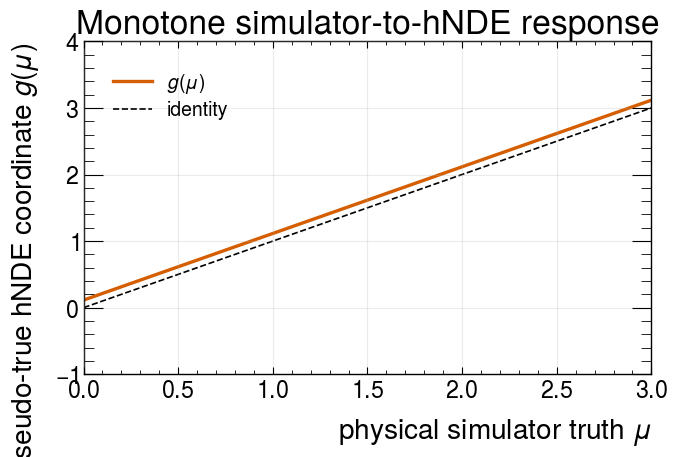

In [31]:
RESPONSE_MU_GRID = np.linspace(*MU_RANGE, RESPONSE_GRID_POINTS)
response_expected_counts = (
    RESPONSE_MU_GRID[:, None]
    * LAM_SIG
    * SIM_CALIBRATION_SIGNAL_PROBABILITY[None, :]
    + LAM_BKG * SIM_CALIBRATION_BACKGROUND_PROBABILITY[None, :]
)
response_grid, _, _ = fit_toy_batch_numpy(
    response_expected_counts, RESPONSE_MU_GRID
)
response_grid = np.asarray(response_grid, dtype=np.float64)
response_score = LAM_SIG - np.sum(
    response_expected_counts
    * COMPRESSED_Q[None, :]
    / (1.0 + response_grid[:, None] * COMPRESSED_Q[None, :]),
    axis=1,
)
response_interior = response_grid > 1.0e-10
response_kkt_violation = np.where(
    response_interior,
    np.abs(response_score),
    np.maximum(-response_score, 0.0),
)
if np.max(response_kkt_violation) > 1.0e-6:
    raise RuntimeError(
        "The pseudo-truth response does not satisfy the constrained "
        "population score equation."
    )
response_differences = np.diff(response_grid)
if np.min(response_differences) < -1.0e-10:
    raise RuntimeError("The fitted pseudo-truth response is not monotone.")
if np.any(response_differences <= 0.0):
    raise RuntimeError(
        "The response is not strictly increasing, so g^{-1} cannot be "
        "reported without defining a generalized-inverse convention."
    )
if response_grid.min() < 0.0 or response_grid.max() >= TOY_MU_MAX - 0.5:
    raise RuntimeError(
        "The pseudo-truth response lies outside the safe hNDE fit range."
    )

response_interpolator = PchipInterpolator(
    RESPONSE_MU_GRID, response_grid, extrapolate=False
)


def pseudo_truth_response(mu):
    """Map physical simulator truth to the frozen hNDE coordinate."""
    values = np.asarray(mu, dtype=np.float64)
    tolerance = 1.0e-12
    if (
        not np.isfinite(values).all()
        or np.any(values < MU_RANGE[0] - tolerance)
        or np.any(values > MU_RANGE[1] + tolerance)
    ):
        raise ValueError("Physical mu lies outside the response-map range.")
    result = np.asarray(
        response_interpolator(np.clip(values, *MU_RANGE)),
        dtype=np.float64,
    )
    return result


def physical_response_estimate(nu):
    """Invert the strictly increasing frozen response map g."""
    values = np.asarray(nu, dtype=np.float64)
    result = np.full(values.shape, np.nan, dtype=np.float64)
    inside = (values >= response_grid[0]) & (values <= response_grid[-1])
    result[inside] = np.interp(
        values[inside], response_grid, RESPONSE_MU_GRID
    )
    return result


response_midpoints = 0.5 * (
    RESPONSE_MU_GRID[:-1] + RESPONSE_MU_GRID[1:]
)
midpoint_expected_counts = (
    response_midpoints[:, None]
    * LAM_SIG
    * SIM_CALIBRATION_SIGNAL_PROBABILITY[None, :]
    + LAM_BKG * SIM_CALIBRATION_BACKGROUND_PROBABILITY[None, :]
)
midpoint_exact, _, _ = fit_toy_batch_numpy(
    midpoint_expected_counts, response_midpoints
)
response_midpoint_error = float(np.max(np.abs(
    pseudo_truth_response(response_midpoints) - midpoint_exact
)))
if response_midpoint_error > 5.0e-5:
    raise RuntimeError(
        "The response-map interpolation is not accurate enough; increase "
        "RESPONSE_GRID_POINTS."
    )

response_digest = hashlib.sha256()
for values in (RESPONSE_MU_GRID, response_grid):
    response_digest.update(np.ascontiguousarray(values).view(np.uint8))
RESPONSE_MAP_FINGERPRINT = (
    "simulator_pseudotruth_v2_" + response_digest.hexdigest()[:16]
)


def response_corrected_test_statistic(counts, physical_mu):
    """Fit counts and evaluate t_mu^(g) at physical ``mu``."""
    return fit_toy_batch_numpy(
        counts, pseudo_truth_response(physical_mu)
    )


print(
    "Pseudo-truth response endpoints:",
    f"g(0)={response_grid[0]:.6f}, g(3)={response_grid[-1]:.6f}",
)
print(
    "Response displacement range:",
    f"[{np.min(response_grid - RESPONSE_MU_GRID):+.6f}, "
    f"{np.max(response_grid - RESPONSE_MU_GRID):+.6f}]",
)
print("Maximum response interpolation error:", response_midpoint_error)
print("Response-map fingerprint:", RESPONSE_MAP_FINGERPRINT)

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(RESPONSE_MU_GRID, response_grid, lw=2.4, label=r"$g(\mu)$")
ax.plot(MU_RANGE, MU_RANGE, "k--", lw=1.2, label="identity")
ax.set(
    xlim=MU_RANGE,
    xlabel=r"physical simulator truth $\mu$",
    ylabel=r"pseudo-true hNDE coordinate $g(\mu)$",
    title="Monotone simulator-to-hNDE response",
)
ax.grid(alpha=.25)
ax.legend()
fig.tight_layout()
export_exercise11_figure(fig, "pseudo_truth_response_map")
plt.show()


## 2. Freeze the 64M construction law and diagnose convergence before training

Before the neural simulator correction is trained, we inspect the nested construction prefixes. Raw $L^1$ distance is reported, but it is not the decisive diagnostic: the previous run showed that a smaller $L^1$ perturbation can have a much larger coverage effect when it points along the likelihood score.

For every prefix $N$, we therefore recompute its population response $g_N(\mu)$ and evaluate the score of the final 64M construction law at that response,

$$
S_{64}(g_N;\mu)
=\lambda_S-\sum_j m_{64,j}(\mu)\frac{q_j}{1+g_N(\mu)q_j},
$$

with curvature

$$
I_{64}(g_N;\mu)
=\sum_j m_{64,j}(\mu)\frac{q_j^2}{[1+g_N(\mu)q_j]^2}.
$$

The dimensionless quantity $|S_{64}|/\sqrt{I_{64}}$ measures the dangerous response displacement in approximate standard-error units. Prefixes are nested and correlated; these curves are convergence diagnostics, not independent repetitions.

The current-runtime Exercise 5 parquet replay is also compared with the fresh construction in PRESEL acceptance, selected-feature histograms, $q$ moments, and response. Closeness is reported rather than enforced by a brittle statistical guard. Structural cache/count/fingerprint failures remain hard errors.


source,selected_per_process,signal_L1_to_64M,background_L1_to_64M,max_abs_g_minus_g64,max_standardized_score_drift,g_0,g_3,signal_mean_log_q,background_mean_log_q
saved Exercise 5 legacy,"250,000",0.022376,0.023254,0.274388,0.4934,0.387935,3.379116,-5.411052,-5.610910
fresh nested construction,"250,000",0.024235,0.020129,0.150217,0.2701,0.000000,2.969021,-5.408269,-5.612806
fresh nested construction,"1,000,000",0.011382,0.010682,0.058389,0.1050,0.055158,3.059464,-5.409108,-5.612176
fresh nested construction,"4,000,000",0.005612,0.005141,0.009265,0.0167,0.104282,3.107704,-5.409895,-5.611896
fresh nested construction,"16,000,000",0.002670,0.002133,0.016498,0.0297,0.097049,3.101719,-5.409705,-5.611924
fresh nested construction,"64,000,000",0.000000,0.000000,0.000000,0.0000,0.113547,3.116499,-5.409846,-5.611918


process,source,generated_or_partition_events,selected_events,PRESEL_acceptance
signal,Exercise 5 eval parquet (current runtime),"798,831","443,343",55.498973%
signal,fresh analytic construction stream,"115,500,000","64,000,000",55.563744%
background,Exercise 5 eval parquet (current runtime),"3,998,508","611,192",15.285501%
background,fresh analytic construction stream,"419,000,000","64,000,000",15.278075%


process,feature,histogram_L1,legacy_tail_fraction,construction_tail_fraction
signal,x1,0.004832,0.000000,0.000000
signal,x2,0.003345,0.000000,0.000000
signal,x3,0.004440,0.000000,0.000000
signal,x4,0.005921,0.000000,0.000000
signal,x5,0.004202,0.000000,0.000000
background,x1,0.002653,0.000000,0.000000
background,x2,0.001806,0.000000,0.000000
background,x3,0.004552,0.000000,0.000000
background,x4,0.005100,0.000000,0.000000
background,x5,0.003834,0.000000,0.000000


process,Exercise5_runtime_vs_fresh64M_q_L1,Exercise5_runtime_mean_log_q,fresh64M_mean_log_q
signal,0.018091,-5.409535,-5.409846
background,0.012970,-5.611362,-5.611918


Wrote standalone figure script: exercise11_figures_scripts/streamed_template_response_and_feature_closure.py


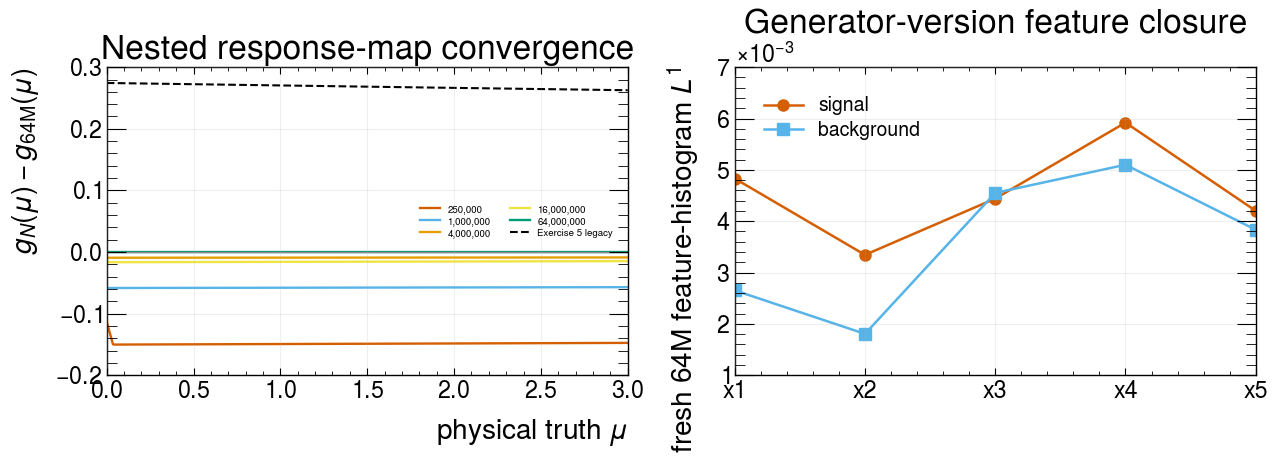

External benchmark provenance (counts deferred): {'signal': 'b70b86d14d3ec9fc1de463d2530d99ec9400ed250dec7d7e2adee4abf00a72b0', 'background': 'ce44338e9031e6548ec05ba1e87054cc2de31f8cda9ea85d03896b3782827e64'}


In [32]:
def template_response_grid(signal_probability, background_probability):
    expected = (
        RESPONSE_MU_GRID[:, None]
        * LAM_SIG
        * np.asarray(signal_probability)[None, :]
        + LAM_BKG * np.asarray(background_probability)[None, :]
    )
    fitted, _, _ = fit_toy_batch_numpy(expected, RESPONSE_MU_GRID)
    return np.asarray(fitted, dtype=np.float64)


def standardized_score_drift(
    response_values, target_signal_probability, target_background_probability
):
    expected = (
        RESPONSE_MU_GRID[:, None]
        * LAM_SIG
        * np.asarray(target_signal_probability)[None, :]
        + LAM_BKG * np.asarray(target_background_probability)[None, :]
    )
    denominator = 1.0 + np.asarray(response_values)[:, None] * COMPRESSED_Q[None, :]
    score = LAM_SIG - np.sum(
        expected * COMPRESSED_Q[None, :] / denominator, axis=1
    )
    information = np.sum(
        expected * COMPRESSED_Q[None, :] ** 2 / denominator**2, axis=1
    )
    standardized = np.divide(
        np.abs(score), np.sqrt(information),
        out=np.full_like(score, np.inf), where=information > 0.0,
    )
    return standardized


PREFIX_RESPONSE_GRIDS = []
PREFIX_RESPONSE_FINGERPRINTS = []
convergence_rows = []
log_q_bin = np.log(COMPRESSED_Q)
for checkpoint_index, selected_events in enumerate(TEMPLATE_SELECTED_CHECKPOINTS):
    signal_probability = SIM_CALIBRATION_SIGNAL_PROBABILITY_BY_CHECKPOINT[
        checkpoint_index
    ]
    background_probability = SIM_CALIBRATION_BACKGROUND_PROBABILITY_BY_CHECKPOINT[
        checkpoint_index
    ]
    prefix_response = template_response_grid(
        signal_probability, background_probability
    )
    PREFIX_RESPONSE_GRIDS.append(prefix_response)
    digest = hashlib.sha256()
    update_array_digest(digest, "mu", RESPONSE_MU_GRID)
    update_array_digest(digest, "g", prefix_response)
    PREFIX_RESPONSE_FINGERPRINTS.append(
        f"construction_prefix_{int(selected_events)}_{digest.hexdigest()[:16]}"
    )
    score_drift = standardized_score_drift(
        prefix_response,
        SIM_CALIBRATION_SIGNAL_PROBABILITY,
        SIM_CALIBRATION_BACKGROUND_PROBABILITY,
    )
    convergence_rows.append({
        "source": "fresh nested construction",
        "selected_per_process": int(selected_events),
        "signal_L1_to_64M": float(np.sum(np.abs(
            signal_probability - SIM_CALIBRATION_SIGNAL_PROBABILITY
        ))),
        "background_L1_to_64M": float(np.sum(np.abs(
            background_probability - SIM_CALIBRATION_BACKGROUND_PROBABILITY
        ))),
        "max_abs_g_minus_g64": float(np.max(np.abs(
            prefix_response - response_grid
        ))),
        "max_standardized_score_drift": float(np.max(score_drift)),
        "g_0": float(prefix_response[0]),
        "g_3": float(prefix_response[-1]),
        "signal_mean_log_q": float(np.sum(signal_probability * log_q_bin)),
        "background_mean_log_q": float(np.sum(background_probability * log_q_bin)),
    })
PREFIX_RESPONSE_GRIDS = np.asarray(PREFIX_RESPONSE_GRIDS)


legacy_response_grid = template_response_grid(
    LEGACY_EXERCISE5_SIGNAL_PROBABILITY,
    LEGACY_EXERCISE5_BACKGROUND_PROBABILITY,
)
legacy_score_drift = standardized_score_drift(
    legacy_response_grid,
    SIM_CALIBRATION_SIGNAL_PROBABILITY,
    SIM_CALIBRATION_BACKGROUND_PROBABILITY,
)
convergence_rows.insert(0, {
    "source": "saved Exercise 5 legacy",
    "selected_per_process": int(LEGACY_EXERCISE5_SIGNAL_COUNTS.sum()),
    "signal_L1_to_64M": float(np.sum(np.abs(
        LEGACY_EXERCISE5_SIGNAL_PROBABILITY - SIM_CALIBRATION_SIGNAL_PROBABILITY
    ))),
    "background_L1_to_64M": float(np.sum(np.abs(
        LEGACY_EXERCISE5_BACKGROUND_PROBABILITY - SIM_CALIBRATION_BACKGROUND_PROBABILITY
    ))),
    "max_abs_g_minus_g64": float(np.max(np.abs(legacy_response_grid - response_grid))),
    "max_standardized_score_drift": float(np.max(legacy_score_drift)),
    "g_0": float(legacy_response_grid[0]),
    "g_3": float(legacy_response_grid[-1]),
    "signal_mean_log_q": float(np.sum(LEGACY_EXERCISE5_SIGNAL_PROBABILITY * log_q_bin)),
    "background_mean_log_q": float(np.sum(LEGACY_EXERCISE5_BACKGROUND_PROBABILITY * log_q_bin)),
})
template_convergence_table = pd.DataFrame(convergence_rows)
display(template_convergence_table.style.format({
    "selected_per_process": "{:,.0f}",
    "signal_L1_to_64M": "{:.6f}",
    "background_L1_to_64M": "{:.6f}",
    "max_abs_g_minus_g64": "{:.6f}",
    "max_standardized_score_drift": "{:.4f}",
    "g_0": "{:.6f}",
    "g_3": "{:.6f}",
    "signal_mean_log_q": "{:.6f}",
    "background_mean_log_q": "{:.6f}",
}).hide(axis="index"))


legacy_acceptance_rows = []
feature_closure_rows = []
q_runtime_closure_rows = []
for process, construction_feature_counts in (
    ("signal", SIM_CALIBRATION_SIGNAL_FEATURE_COUNTS_BY_CHECKPOINT[-1]),
    ("background", SIM_CALIBRATION_BACKGROUND_FEATURE_COUNTS_BY_CHECKPOINT[-1]),
):
    legacy = LEGACY_RUNTIME_CLOSURE[process]
    legacy_acceptance_rows.append({
        "process": process,
        "source": "Exercise 5 eval parquet (current runtime)",
        "generated_or_partition_events": legacy["partition_events"],
        "selected_events": legacy["selected_events"],
        "PRESEL_acceptance": legacy["selected_events"] / legacy["partition_events"],
    })
    stream = CONSTRUCTION_STREAM_RESULTS[process]
    legacy_acceptance_rows.append({
        "process": process,
        "source": "fresh analytic construction stream",
        "generated_or_partition_events": stream["generated_events"],
        "selected_events": stream["selected_events"],
        "PRESEL_acceptance": stream["acceptance"],
    })
    legacy_feature_probability = (
        legacy["feature_counts"] / legacy["selected_events"]
    )
    construction_feature_probability = (
        construction_feature_counts / FINAL_TEMPLATE_EVENTS
    )
    construction_q_probability = (
        SIM_CALIBRATION_SIGNAL_PROBABILITY
        if process == "signal"
        else SIM_CALIBRATION_BACKGROUND_PROBABILITY
    )
    legacy_q_probability = legacy["q_counts"] / legacy["selected_events"]
    q_runtime_closure_rows.append({
        "process": process,
        "Exercise5_runtime_vs_fresh64M_q_L1": float(np.sum(np.abs(
            legacy_q_probability - construction_q_probability
        ))),
        "Exercise5_runtime_mean_log_q": float(np.sum(
            legacy_q_probability * log_q_bin
        )),
        "fresh64M_mean_log_q": float(np.sum(
            construction_q_probability * log_q_bin
        )),
    })
    for feature_index, feature in enumerate(FEATURES):
        feature_closure_rows.append({
            "process": process,
            "feature": feature,
            "histogram_L1": float(np.sum(np.abs(
                legacy_feature_probability[feature_index]
                - construction_feature_probability[feature_index]
            ))),
            "legacy_tail_fraction": float(
                legacy_feature_probability[feature_index, 0]
                + legacy_feature_probability[feature_index, -1]
            ),
            "construction_tail_fraction": float(
                construction_feature_probability[feature_index, 0]
                + construction_feature_probability[feature_index, -1]
            ),
        })
preselection_closure_table = pd.DataFrame(legacy_acceptance_rows)
feature_closure_table = pd.DataFrame(feature_closure_rows)
q_runtime_closure_table = pd.DataFrame(q_runtime_closure_rows)
display(preselection_closure_table.style.format({
    "generated_or_partition_events": "{:,.0f}",
    "selected_events": "{:,.0f}",
    "PRESEL_acceptance": "{:.6%}",
}).hide(axis="index"))
display(feature_closure_table.style.format(precision=6).hide(axis="index"))
display(q_runtime_closure_table.style.format(precision=6).hide(axis="index"))


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for index, selected_events in enumerate(TEMPLATE_SELECTED_CHECKPOINTS):
    axes[0].plot(
        RESPONSE_MU_GRID,
        PREFIX_RESPONSE_GRIDS[index] - response_grid,
        lw=1.7,
        label=f"{int(selected_events):,}",
    )
axes[0].plot(
    RESPONSE_MU_GRID, legacy_response_grid - response_grid,
    color="black", ls="--", lw=1.5, label="Exercise 5 legacy",
)
axes[0].axhline(0.0, color="0.5", lw=1.0)
axes[0].set(
    xlabel=r"physical truth $\mu$",
    ylabel=r"$g_N(\mu)-g_{64\mathrm{M}}(\mu)$",
    title="Nested response-map convergence",
)
axes[0].grid(alpha=.2)
axes[0].legend(fontsize=7, ncol=2)

for process, marker in (("signal", "o"), ("background", "s")):
    subset = feature_closure_table[feature_closure_table["process"] == process]
    axes[1].plot(
        subset["feature"], subset["histogram_L1"], marker=marker,
        lw=1.8, label=process,
    )
axes[1].set(
    ylabel="Exercise 5 vs fresh 64M feature-histogram $L^1$",
    title="Generator-version feature closure",
)
axes[1].grid(alpha=.2)
axes[1].legend()
fig.tight_layout()
export_exercise11_figure(fig, "streamed_template_response_and_feature_closure")
plt.show()

assert np.isclose(SIM_CALIBRATION_SIGNAL_PROBABILITY.sum(), 1.0)
assert np.isclose(SIM_CALIBRATION_BACKGROUND_PROBABILITY.sum(), 1.0)
print(
    "External benchmark provenance (counts deferred):",
    {process: summary["fingerprint"] for process, summary in EXTERNAL_BENCHMARK_STREAM_SUMMARIES.items()},
)


## 3. Generate 500,000 response-matched hNDE toys

Draw physical design points $\mu\sim U(0,3)$, map them to $g(\mu)$, generate the inexpensive hNDE toy at that surrogate coordinate, and evaluate the numerator at the same coordinate. Thus these toys learn the central response-matched reference law

$$
p_{\rm H}^{(g)}(t\mid\mu),
\qquad
\mathcal D_{\rm H}\sim p_{\rm H}(\cdot\mid g(\mu)),
\qquad
t=t_\mu^{(g)}(\mathcal D_{\rm H}).
$$

The context stored for every flow and classifier remains the physical $\mu$, not $g(\mu)$. The cache records all three coordinates and aborts if a stale identity-response shard is encountered.


                  mu           g_mu         mu_hat          t_mu       n_events
count  500000.000000  500000.000000  500000.000000  5.000000e+05  500000.000000
mean        1.502330       1.617399       1.635584  9.635145e-01  153811.441992
std         0.865699       0.866552       0.996666  1.356707e+00     658.643742
min         0.000004       0.113551       0.000000  5.755741e-11  151512.000000
1%          0.030160       0.143739       0.000000  1.589282e-04  152392.000000
50%         1.504192       1.619286       1.617005  4.458315e-01  153812.000000
95%         2.849536       2.965899       3.283471  3.685309e+00  154878.000000
99%         2.969351       3.085822       3.800993  6.363462e+00  155233.000000
max         2.999997       3.116496       5.457185  2.264758e+01  156244.000000
Maximum fitted-score residual: 2.274e-13
Wrote standalone figure script: exercise11_figures_scripts/hnde_amortized_toys.py


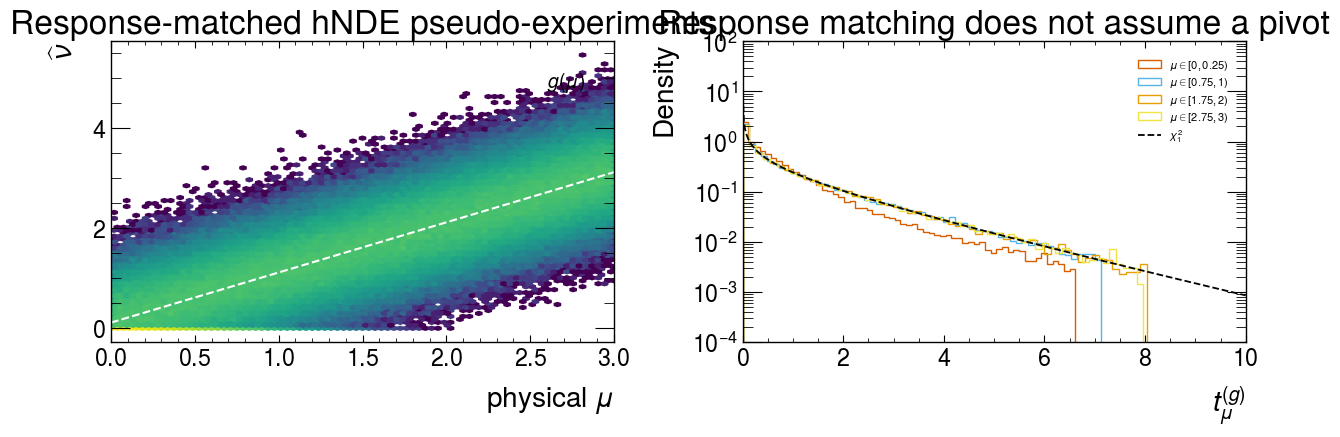

In [33]:
hnde_toys = run_cached_toy_ensemble(
    cache_dir=CACHE_DIR / f"hnde_uniform_{N_HNDE_TOYS}",
    n_toys=N_HNDE_TOYS,
    batch_size=TOY_BATCH_SIZE,
    seed=SEED + 300,
    mu_range=MU_RANGE,
    signal_probability=HNDE_SIGNAL_PROBABILITY,
    background_probability=HNDE_BACKGROUND_PROBABILITY,
    lam_signal=LAM_SIG,
    lam_background=LAM_BKG,
    likelihood_q=COMPRESSED_Q,
    fit_batch=fit_toy_batch_numpy,
    fit_fingerprint=TOY_FIT_FINGERPRINT,
    fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
    generation_mu_transform=pseudo_truth_response,
    test_mu_transform=pseudo_truth_response,
    generation_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
    test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
)
expected_hnde_coordinate = pseudo_truth_response(hnde_toys["mu"])
if not np.allclose(
    hnde_toys["generation_mu"], expected_hnde_coordinate,
    rtol=0.0, atol=2.0e-6,
) or not np.allclose(
    hnde_toys["test_mu"], expected_hnde_coordinate,
    rtol=0.0, atol=2.0e-6,
):
    raise RuntimeError("The response-matched hNDE cache has stale coordinates.")
print(pd.DataFrame({
    "mu": hnde_toys["mu"],
    "g_mu": hnde_toys["test_mu"],
    "mu_hat": hnde_toys["mu_hat"],
    "t_mu": hnde_toys["t_mu"],
    "n_events": hnde_toys["n_events"],
}).describe(percentiles=[.01, .5, .95, .99]).to_string())
print(
    "Maximum fitted-score residual:",
    f"{np.max(np.abs(hnde_toys['fitted_score'])):.3e}",
)

split_rng = np.random.default_rng(SEED + 301)
toy_order = split_rng.permutation(N_HNDE_TOYS)
flow_indices = toy_order[:N_FLOW_TOYS]
ratio1_indices = toy_order[N_FLOW_TOYS:]
flow_mu = hnde_toys["mu"][flow_indices].astype(np.float32)
flow_y = np.log(
    hnde_toys["t_mu"][flow_indices].astype(np.float64) + T_OFFSET
).astype(np.float32)
ratio1_mu = hnde_toys["mu"][ratio1_indices].astype(np.float32)
ratio1_y_positive = np.log(
    hnde_toys["t_mu"][ratio1_indices].astype(np.float64) + T_OFFSET
).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].hexbin(
    hnde_toys["mu"], hnde_toys["mu_hat"],
    gridsize=80, bins="log", mincnt=1, cmap="viridis",
)
response_plot_grid = np.linspace(*MU_RANGE, 400)
axes[0].plot(
    response_plot_grid, pseudo_truth_response(response_plot_grid),
    "w--", lw=1.5, label=r"$g(\mu)$",
)
axes[0].set(
    xlabel=r"physical $\mu$", ylabel=r"$\widehat\nu$",
    title="Response-matched hNDE pseudo-experiments",
)
axes[0].legend()
for low, high, color in [(0.0,.25,"C0"),(.75,1.0,"C1"),(1.75,2.0,"C2"),(2.75,3.0,"C3")]:
    mask = (hnde_toys["mu"] >= low) & (hnde_toys["mu"] < high)
    values = hnde_toys["t_mu"][mask]
    edges = np.linspace(0, np.quantile(values, .995), 60)
    axes[1].hist(values, bins=edges, density=True, histtype="step", lw=1.8,
                 color=color, label=rf"$\mu\in[{low:g},{high:g})$")
x = np.linspace(0.001, axes[1].get_xlim()[1], 400)
axes[1].plot(x, chi2.pdf(x, df=1), "k--", lw=1.3, label=r"$\chi^2_1$")
axes[1].set(
    xlabel=r"$t_{\mu}^{(g)}$", ylabel="Density",
    title="Response matching does not assume a pivot",
)
axes[1].legend(fontsize=8)
axes[1].set_yscale('log')
fig.tight_layout()
export_exercise11_figure(fig, "hnde_amortized_toys")
plt.show()


## 4. Train the conditional quadratic-spline reference

The first 400,000 response-matched hNDE toys train a conditional rational-quadratic-spline density in $y=\log(t_\mu^{(g)}+\epsilon)$. The remaining 100,000 toys are disjoint and are reserved for the first density-ratio correction.

The scalar flow is conditioned on physical $\mu$. Its target includes the non-Gaussian structure left after response matching; no Wilks or Wald approximation is imposed.


In [34]:
statistic_flow = train_spline_flow(
    flow_y[:, None],
    context=flow_mu[:, None],
    checkpoint=MODEL_DIR / "q_phi_y_given_mu.pt",
    model_config=STATISTIC_FLOW_MODEL_CONFIG,
    training_config=STATISTIC_FLOW_TRAINING_CONFIG,
    device=device,
    seed=SEED + 400,
    load_if_available=LOAD_IF_AVAILABLE,
    verify_checkpoint_data=True,
)
flow_config_mismatch = {
    name: (statistic_flow["config"].get(name), expected)
    for name, expected in STATISTIC_FLOW_MODEL_CONFIG.items()
    if statistic_flow["config"].get(name) != expected
}
if flow_config_mismatch:
    raise RuntimeError(
        "The loaded statistic-flow checkpoint has stale architecture: "
        f"{flow_config_mismatch}. Bump BASE_RUN_TAG."
    )
print("Conditional statistic flow:", statistic_flow["checkpoint"])


Loaded spline flow with matching data fingerprint from models_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/q_phi_y_given_mu.pt
Conditional statistic flow: models_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/q_phi_y_given_mu.pt


## 5. First matched correction: spline $\rightarrow$ response-matched hNDE toys

At each physical $\mu_i$, a positive example is the held-out hNDE statistic $y_i$ and its matched negative example is drawn from the conditional spline at that same $\mu_i$. Ordinary BCE therefore estimates the residual density ratio without proposal-prior weights. Paired group splitting keeps the positive and negative members of each matched pair on the same side of the train/validation boundary.



Training hNDE residual member 1/4
Loaded ratio classifier with matching data fingerprint from models_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/hnde_residual_ensemble4/r1_member0.pt

Training hNDE residual member 2/4
Loaded ratio classifier with matching data fingerprint from models_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/hnde_residual_ensemble4/r1_member1.pt

Training hNDE residual member 3/4
Loaded ratio classifier with matching data fingerprint from models_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/hnde_residual_ensemble4/r1_member2.pt

Training hNDE residual member 4/4
Loaded ratio classifier with matching data fingerprint from models_exercise11_hybrid_neyman_v1/full_response_stream64m_v3/hnde_residual_ensemble4/r1_member3.pt
Unphysical flow-reference rejection fraction: 0.0000%
Wrote standalone figure script: exercise11_figures_scripts/first_ratio_training.py


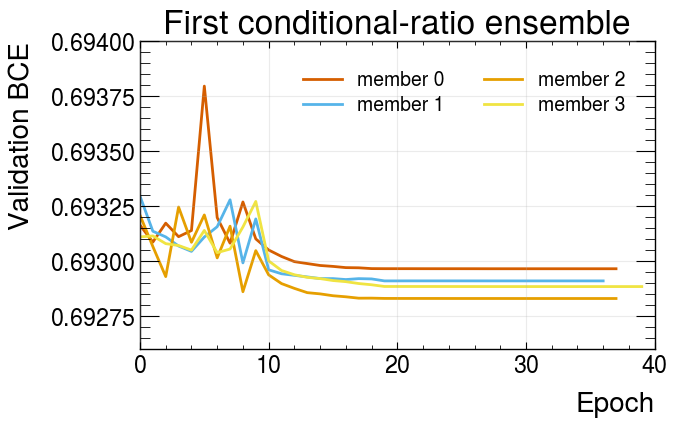

In [35]:
Y_MIN = float(np.log(T_OFFSET))
ratio1_y_negative, ratio1_rejection = sample_truncated_spline_flow(
    statistic_flow,
    ratio1_mu[:, None],
    lower_bound=Y_MIN,
    seed=SEED + 500,
)
ratio1_positive = np.column_stack([ratio1_mu, ratio1_y_positive])
ratio1_negative = np.column_stack([ratio1_mu, ratio1_y_negative])
paired_ids_1 = np.arange(N_RATIO1_TOYS, dtype=np.int64)
ratio1_ensemble = []
for member in range(RATIO_ENSEMBLE_SIZE):
    print("\n" + "=" * 76)
    print(f"Training hNDE residual member {member + 1}/{RATIO_ENSEMBLE_SIZE}")
    print("=" * 76)
    ratio1_ensemble.append(
        train_ratio_classifier(
            ratio1_positive,
            ratio1_negative,
            checkpoint=RATIO1_MODEL_DIR / f"r1_member{member}.pt",
            model_config=CORRECTION_MODEL_CONFIG,
            training_config=CORRECTION_TRAINING_CONFIG,
            device=device,
            seed=SEED + 510 + 100 * member,
            load_if_available=LOAD_IF_AVAILABLE,
            paired_group_ids=paired_ids_1,
            verify_checkpoint_data=True,
        )
    )
print(f"Unphysical flow-reference rejection fraction: {ratio1_rejection:.4%}")
assert all(
    pack["history"].get("split_strategy") == "paired_groups"
    for pack in ratio1_ensemble
)

fig, ax = plt.subplots(figsize=(7.0, 4.5))
for member, pack in enumerate(ratio1_ensemble):
    history = pack.get("history", {})
    ax.plot(history.get("validation", []), label=f"member {member}")
ax.set(xlabel="Epoch", ylabel="Validation BCE",
       title="First conditional-ratio ensemble")
ax.grid(alpha=.25)
ax.legend(ncol=2)
fig.tight_layout()
export_exercise11_figure(fig, "first_ratio_training")
plt.show()


## 6. Normalize the response-matched hNDE density and compute $F_{\rm H}^{(g)}$

The first run exposed an important numerical trap. Increasing $Y_{\max}$ while holding the number of grid points fixed coarsened the grid, eventually producing an impossible raw-flow mass above one. The old loop also tested the density while its endpoint was still inside the learned spline region, where a rational-quadratic spline need not have a monotone tail.

The replacement below is self-adjusting:

1. it places $Y_{\max}$ beyond the standardized spline tail boundary, where every scalar `nflows` transform is exactly the identity and the raw-flow tail is an analytic standard-normal tail;
2. when support expands, it increases the point count to preserve the original $\Delta y$;
3. it doubles a nested grid until full/half-grid quantiles and integrals agree;
4. it compares numerical raw-flow mass with the exact normal-tail mass;
5. it uses the bounded classifier log-odds to place a conservative analytic upper bound on omitted hybrid tail mass.

All guards now change the relevant parameter before retrying and have finite hard caps. Failure raises an actionable exception; it is no longer possible to print a failed diagnostic and silently continue.


In [36]:
MU_DENSITY_GRID = np.linspace(*MU_RANGE, QUADRATURE_MU_POINTS)
data_driven_y_max = float(max(
    5.0,
    np.quantile(np.concatenate([flow_y, ratio1_y_positive]), .99999) + 1.5,
))
target_y_mean = float(statistic_flow["target_scaler"].mean[0])
target_y_std = float(statistic_flow["target_scaler"].std[0])
spline_tail_bound = float(
    statistic_flow["config"]["spline_tail_bound"]
)

if target_y_std <= 0.0:
    raise RuntimeError("The statistic-flow target scale is not positive.")

Y_SUPPORT_BUFFER = 1.0
Y_UPPER_TAIL_MASS_TARGET = 1.0e-5
Y_QUANTILE_STABILITY_TARGET = 1.0e-2
Y_HALF_INTEGRAL_TARGET = 1.0e-3
Y_RAW_MASS_TARGET = 1.0e-3
Y_SUPPORT_MAX_EXPANSIONS = 3
Y_RESOLUTION_MAX_REFINEMENTS = 3
Y_GRID_MAX_POINTS = 32_769

# Preserve the original nominal spacing even if analytic tail certification
# requires a larger support. Use an even number of intervals so Y_GRID[::2]
# is a nested half-resolution grid with the same endpoints.
base_dy = (
    data_driven_y_max - Y_MIN
) / (QUADRATURE_Y_POINTS - 1)
Y_MAX = float(max(
    data_driven_y_max,
    target_y_mean + (spline_tail_bound + 2.0) * target_y_std,
))

quadrature_converged = False
for support_attempt in range(Y_SUPPORT_MAX_EXPANSIONS + 1):
    intervals = int(np.ceil((Y_MAX - Y_MIN) / base_dy))
    intervals += intervals % 2
    tail_requires_expansion = False

    for refinement in range(Y_RESOLUTION_MAX_REFINEMENTS + 1):
        n_points = intervals + 1
        if n_points > Y_GRID_MAX_POINTS:
            raise RuntimeError(
                f"Adaptive Y_GRID requires {n_points:,} points, above the "
                f"hard cap {Y_GRID_MAX_POINTS:,}. Increase the cap only "
                "after inspecting the statistic-flow boundary spike."
            )
        Y_GRID = np.linspace(Y_MIN, Y_MAX, n_points)
        flow_physical_grid = conditional_density_grid(
            statistic_flow,
            [],
            MU_DENSITY_GRID,
            Y_GRID,
        )
        hybrid1_grid = conditional_density_grid(
            statistic_flow,
            [ratio1_ensemble],
            MU_DENSITY_GRID,
            Y_GRID,
            max_abs_log_ratio=LOG_RATIO_CLIP,
        )

        z_min = (Y_MIN - target_y_mean) / target_y_std
        z_max = (Y_MAX - target_y_mean) / target_y_std
        if z_min > -spline_tail_bound or z_max < spline_tail_bound:
            raise RuntimeError(
                "Y_GRID endpoints do not both lie in the exact linear "
                "tails of the statistic spline."
            )
        exact_captured_flow_mass = float(
            norm.cdf(z_max) - norm.cdf(z_min)
        )
        exact_physical_flow_mass = float(norm.sf(z_min))
        exact_raw_upper_tail = float(norm.sf(z_max))
        numerical_flow_mass = np.exp(
            flow_physical_grid["log_normalization"]
        )
        raw_mass_error = float(np.max(np.abs(
            numerical_flow_mass - exact_captured_flow_mass
        )))

        coarse_y_grid = Y_GRID[::2]
        coarse_flow_mass = trapezoid(
            flow_physical_grid["density"][:, ::2],
            x=coarse_y_grid,
            axis=1,
        )
        coarse_hybrid_mass = trapezoid(
            hybrid1_grid["density"][:, ::2],
            x=coarse_y_grid,
            axis=1,
        )
        flow_half_integral_error = float(np.max(np.abs(
            coarse_flow_mass - 1.0
        )))
        hybrid_half_integral_error = float(np.max(np.abs(
            coarse_hybrid_mass - 1.0
        )))
        coarse_hybrid_cdf = cumulative_trapezoid(
            hybrid1_grid["density"][:, ::2],
            x=coarse_y_grid,
            axis=1,
            initial=0.0,
        ) / coarse_hybrid_mass[:, None]
        hybrid1_quantile_y = conditional_quantiles(
            hybrid1_grid["cdf"], Y_GRID, QUANTILE_LEVELS
        )
        coarse_hybrid1_quantile_y = conditional_quantiles(
            coarse_hybrid_cdf, coarse_y_grid, QUANTILE_LEVELS
        )
        y_resolution_shift = float(np.max(np.abs(
            coarse_hybrid1_quantile_y - hybrid1_quantile_y
        )))

        partial_hybrid_normalization = np.exp(
            hybrid1_grid["log_normalization"]
        )
        hybrid_upper_tail_bound = float(
            np.exp(LOG_RATIO_CLIP)
            * exact_raw_upper_tail
            / np.min(partial_hybrid_normalization)
        )
        print(
            f"Y attempt {support_attempt + 1}.{refinement + 1}: "
            f"Y_MAX={Y_MAX:.4f}, z_max={z_max:.3f}, "
            f"points={n_points:,}, max_dy={np.max(np.diff(Y_GRID)):.3e}; "
            f"q_shift={y_resolution_shift:.3e}, "
            f"half_mass(raw/hybrid)={flow_half_integral_error:.3e}/"
            f"{hybrid_half_integral_error:.3e}, "
            f"raw_exact_error={raw_mass_error:.3e}, "
            f"hybrid_tail_bound={hybrid_upper_tail_bound:.3e}"
        )

        if hybrid_upper_tail_bound > Y_UPPER_TAIL_MASS_TARGET:
            tail_requires_expansion = True
            break
        resolution_is_stable = (
            y_resolution_shift <= Y_QUANTILE_STABILITY_TARGET
            and flow_half_integral_error <= Y_HALF_INTEGRAL_TARGET
            and hybrid_half_integral_error <= Y_HALF_INTEGRAL_TARGET
            and raw_mass_error <= Y_RAW_MASS_TARGET
        )
        if resolution_is_stable:
            quadrature_converged = True
            break
        intervals *= 2

    if quadrature_converged:
        break
    if tail_requires_expansion:
        if support_attempt == Y_SUPPORT_MAX_EXPANSIONS:
            raise RuntimeError(
                "The analytic hybrid upper-tail bound did not converge. "
                "Inspect the first-ratio tail or increase the finite support."
            )
        Y_MAX += target_y_std
        continue
    raise RuntimeError(
        "Y quadrature did not pass the nested-grid stability checks after "
        f"{Y_RESOLUTION_MAX_REFINEMENTS} refinements."
    )

if not quadrature_converged:
    raise RuntimeError("Adaptive Y quadrature terminated without convergence.")
if (len(Y_GRID) - 1) % 2 or Y_GRID[::2][-1] != Y_MAX:
    raise RuntimeError("The final full/half Y grids are not exactly nested.")

hybrid1_quantile_t = np.maximum(
    np.exp(hybrid1_quantile_y) - T_OFFSET, 0.0
)
hybrid1_log_normalization_truncated = (
    hybrid1_grid["log_normalization"]
    - np.log(exact_physical_flow_mass)
)

# Rejection sampling removes only y < Y_MIN. Because Y_MIN lies in the exact
# linear tail, C_phi is analytic and cannot exceed one through quadrature bias.
flow_physical_mass = np.full(
    len(MU_DENSITY_GRID), exact_physical_flow_mass, dtype=np.float64
)
ratio1_acceptance = np.full(
    len(ratio1_mu), exact_physical_flow_mass, dtype=np.float64
)
quadrature_rejection = 1.0 - (
    len(ratio1_acceptance) / np.sum(1.0 / ratio1_acceptance)
)

hybrid1_edge_ratio = float(np.max(
    hybrid1_grid["density"][:, -1]
    / np.max(hybrid1_grid["density"], axis=1)
))
upper_buffer_index = int(np.searchsorted(
    Y_GRID, Y_MAX - Y_SUPPORT_BUFFER
))
hybrid1_upper_buffer_mass = float(np.max(
    1.0 - hybrid1_grid["cdf"][:, upper_buffer_index]
))
print(
    "Final Y-grid support/points/max spacing:",
    f"[{Y_MIN:.4f}, {Y_MAX:.4f}] / {len(Y_GRID):,} / "
    f"{np.max(np.diff(Y_GRID)):.3e}",
)
print(
    "Analytic physical flow mass / omitted raw/hybrid upper tail:",
    exact_physical_flow_mass,
    exact_raw_upper_tail,
    hybrid_upper_tail_bound,
)
print(
    "Final hybrid edge ratio / last-unit mass (diagnostic only):",
    hybrid1_edge_ratio,
    hybrid1_upper_buffer_mass,
)
print(
    "Flow rejection: observed / analytic context-matched =",
    f"{ratio1_rejection:.4%} / {quadrature_rejection:.4%}",
)
if abs(ratio1_rejection - quadrature_rejection) > 5.0e-3:
    raise RuntimeError(
        "Rejection sampling and the analytic physical-support mass disagree."
    )
print(
    "log Z1_tilde(mu) quantiles:",
    np.quantile(
        hybrid1_log_normalization_truncated, [0, .01, .5, .99, 1]
    ),
)
print(
    "r1 quadrature logit range / clipped fraction:",
    hybrid1_grid["ratio_log_range"][0],
    f"{hybrid1_grid['ratio_clip_fraction'][0]:.4%}",
)
print(
    "Full/half y-grid maximum quantile shift / fixed tolerance:",
    y_resolution_shift,
    Y_QUANTILE_STABILITY_TARGET,
)

if (
    np.max(np.abs(hybrid1_grid["cdf"][:, 0])) > 1.0e-10
    or np.max(np.abs(hybrid1_grid["cdf"][:, -1] - 1.0)) > 1.0e-10
    or np.min(np.diff(hybrid1_grid["cdf"], axis=1)) < -1.0e-10
):
    raise RuntimeError("F_H^(g) is not a valid conditional CDF.")


Y attempt 1.1: Y_MAX=14.1067, z_max=7.000, points=6,081, max_dy=4.592e-03; q_shift=3.025e-03, half_mass(raw/hybrid)=1.147e-04/1.133e-04, raw_exact_error=4.633e-04, hybrid_tail_bound=4.206e-06
Final Y-grid support/points/max spacing: [-13.8155, 14.1067] / 6,081 / 4.592e-03
Analytic physical flow mass / omitted raw/hybrid upper tail: 0.9999999936885797 1.279812543885835e-12 4.205728369014983e-06
Final hybrid edge ratio / last-unit mass (diagnostic only): 5.0996481493210327e-11 7.682643410333867e-11
Flow rejection: observed / analytic context-matched = 0.0000% / 0.0000%
log Z1_tilde(mu) quantiles: [-0.00524443 -0.00523018 -0.00068384  0.00151654  0.0015217 ]
r1 quadrature logit range / clipped fraction: [-0.06072487  1.26518788] 0.0000%
Full/half y-grid maximum quantile shift / fixed tolerance: 0.0030253007503344698 0.01


## 7. Generate construction-law simulator pseudo-experiments

Simulator toys generate counts at physical $\mu$ under the fixed construction template and evaluate the ordering statistic at the response-matched numerator $g(\mu)$. The main design proposal is uniform on $[0,3]$. Because the preceding external benchmark showed that low $\mu$ is the hardest region, an additional proposal samples $[0,0.75]$.

The nonuniform design does not change the conditional likelihood target $p(W\mid\mu)$ learned by the flow: it changes how frequently different contexts are presented, and therefore reallocates finite training accuracy, but for every supplied $\mu$ the target remains the construction-law conditional distribution. No proposal-density weight or matched negative class is required.


In [37]:
simulator_calibration_uniform_toys = run_cached_toy_ensemble(
    cache_dir=(
        PIT_CACHE_DIR
        / f"simulator_construction_uniform_{N_SIMULATOR_CALIBRATION_TOYS}"
    ),
    n_toys=N_SIMULATOR_CALIBRATION_TOYS,
    batch_size=TOY_BATCH_SIZE,
    seed=SEED + 700,
    mu_range=MU_RANGE,
    signal_probability=SIM_CALIBRATION_SIGNAL_PROBABILITY,
    background_probability=SIM_CALIBRATION_BACKGROUND_PROBABILITY,
    lam_signal=LAM_SIG,
    lam_background=LAM_BKG,
    likelihood_q=COMPRESSED_Q,
    fit_batch=fit_toy_batch_numpy,
    fit_fingerprint=TOY_FIT_FINGERPRINT,
    fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
    test_mu_transform=pseudo_truth_response,
    test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
)

simulator_calibration_low_mu_toys = run_cached_toy_ensemble(
    cache_dir=(
        PIT_CACHE_DIR
        / f"simulator_construction_low_mu_{N_SIMULATOR_LOW_MU_TOYS}"
    ),
    n_toys=N_SIMULATOR_LOW_MU_TOYS,
    batch_size=TOY_BATCH_SIZE,
    seed=SEED + 701,
    mu_range=LOW_MU_CALIBRATION_RANGE,
    signal_probability=SIM_CALIBRATION_SIGNAL_PROBABILITY,
    background_probability=SIM_CALIBRATION_BACKGROUND_PROBABILITY,
    lam_signal=LAM_SIG,
    lam_background=LAM_BKG,
    likelihood_q=COMPRESSED_Q,
    fit_batch=fit_toy_batch_numpy,
    fit_fingerprint=TOY_FIT_FINGERPRINT,
    fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
    test_mu_transform=pseudo_truth_response,
    test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
)

simulator_calibration_toys = {
    name: np.concatenate([
        simulator_calibration_uniform_toys[name],
        simulator_calibration_low_mu_toys[name],
    ])
    for name in simulator_calibration_uniform_toys
}
N_SIMULATOR_CALIBRATION_TOTAL = len(simulator_calibration_toys["mu"])
expected_test_mu = pseudo_truth_response(
    simulator_calibration_toys["mu"]
)
if not np.allclose(
    simulator_calibration_toys["generation_mu"],
    simulator_calibration_toys["mu"],
    rtol=0.0,
    atol=2.0e-6,
) or not np.allclose(
    simulator_calibration_toys["test_mu"],
    expected_test_mu,
    rtol=0.0,
    atol=2.0e-6,
):
    raise RuntimeError(
        "The simulator calibration cache does not use physical generation "
        "and response-corrected testing."
    )
print(pd.DataFrame({
    "mu": simulator_calibration_toys["mu"],
    "g_mu": simulator_calibration_toys["test_mu"],
    "mu_hat": simulator_calibration_toys["mu_hat"],
    "mu_hat_minus_g": (
        simulator_calibration_toys["mu_hat"]
        - simulator_calibration_toys["test_mu"]
    ),
    "t_mu_g": simulator_calibration_toys["t_mu"],
}).describe(percentiles=[.01, .5, .95, .99]).to_string())

calibration_mu = simulator_calibration_toys["mu"].astype(np.float32)
calibration_y = np.log(
    simulator_calibration_toys["t_mu"].astype(np.float64) + T_OFFSET
)
below_y_grid = float(np.mean(calibration_y < Y_MIN))
above_y_grid = float(np.mean(calibration_y > Y_MAX))
print(
    "Simulator calibration toys outside Y_GRID (lower/upper):",
    f"{below_y_grid:.6%} / {above_y_grid:.6%}",
)
if below_y_grid > 0.0 or above_y_grid > 0.0:
    raise RuntimeError(
        "Simulator calibration statistics lie outside the certified Y_GRID. "
        "Increase its support and rerun before training the residual CDF flow; "
        "clipping would create an artificial atom at u=0 or u=1."
    )


                  mu           g_mu         mu_hat  mu_hat_minus_g        t_mu_g
count  750000.000000  750000.000000  750000.000000   750000.000000  7.500000e+05
mean        1.125224       1.239917       1.273438        0.033521  9.345879e-01
std         0.892819       0.893700       1.000363        0.514407  1.305544e+00
min         0.000002       0.113549       0.000000       -2.538170  1.841327e-12
1%          0.015286       0.128849       0.000000       -1.123839  1.502120e-04
50%         0.750227       0.864563       1.089768       -0.002751  4.428777e-01
95%         2.776020       2.892316       3.112020        0.918010  3.535524e+00
99%         2.955386       3.071845       3.688632        1.298450  6.128754e+00
max         2.999993       3.116492       5.514493        2.556712  2.223402e+01
Simulator calibration toys outside Y_GRID (lower/upper): 0.000000% / 0.000000%


## 8. Learn the residual simulator CDF with one conditional flow

Map every construction simulator statistic through the hNDE-derived reference $H$ to obtain $U_0$. If $H$ already equaled the construction CDF, $U_0\mid\mu$ would be uniform. We do not assume that equality.

Instead, transform $U_0$ to $W=\Phi^{-1}(U_0)$ and fit a single scalar conditional rational-quadratic-spline flow as a continuous surrogate for the finely supported conditional law of $W$. Since its base distribution is standard normal and its data-to-base map is monotone, the flow supplies $G_\psi$ and $G_\psi^{-1}$ analytically. The model is a continuous approximation to the full residual CDF, not only its 95% quantile. This statement concerns the *model object*: monotonicity, normalization, and analytic inversion hold on $(0,1)$, with exact limiting CDF endpoints. It does not mean that finite training data validate every extreme probability equally well. The 95% Neyman rule is the primary target here; progressively more extreme tail levels require dedicated effective sample size and holdout checks.

This is the direct-CDF counterpart of the previous classifier construction. The old classifier estimated $G'(u\mid\mu)$ against a uniform negative class and then integrated it; the new flow represents $G$ itself through its monotone transport. One model is used rather than an ensemble because averaging flow CDFs would destroy analytic inversion and reintroduce numerical root finding.

The spline is initialized to the exact identity $f_\psi(W;\mu)=W$. That initial model is retained as the validation baseline, so optimization can return a learned correction only when its held-out likelihood improves on doing nothing. This is especially useful here because the expected residual correction is small. The architecture and checkpoint are frozen before the tail diagnostics below; those diagnostics are not used to select a new tail bound, training seed, or model capacity.


Exact PIT-boundary fraction: 0.000000%
PIT values moved by the numerical 1e-12 probit clip: 0.000267%
Loaded spline flow with matching data fingerprint from models_exercise11_hybrid_neyman_v1/full_direct_pit_cdf_v1/direct_residual_pit_cdf_flow.pt
Direct residual PIT-CDF flow: models_exercise11_hybrid_neyman_v1/full_direct_pit_cdf_v1/direct_residual_pit_cdf_flow.pt
Gaussianized PIT mean/std/range: 0.0023871955927461386 1.0192315578460693 [-7.034483909606934, 3.8853182792663574]
Wrote standalone figure script: exercise11_figures_scripts/direct_pit_cdf_flow_training.py


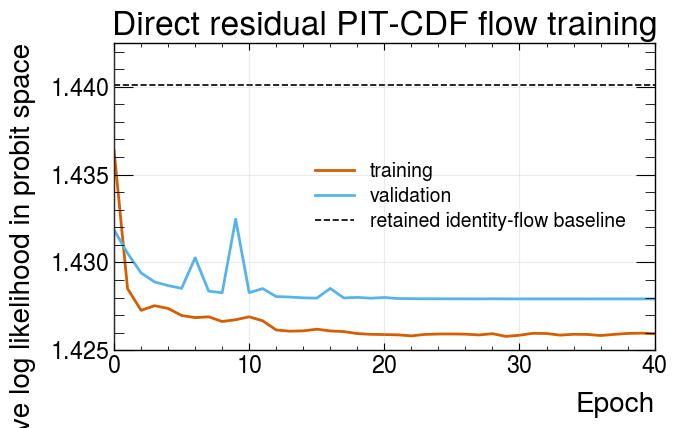

Identity / selected validation NLL: 1.4401169048773277 1.4279226580181636


In [38]:
calibration_u0_raw = conditional_cdf_values(
    hybrid1_grid["cdf"],
    MU_DENSITY_GRID,
    Y_GRID,
    calibration_mu,
    calibration_y,
)
exact_boundary_fraction = float(np.mean(
    (calibration_u0_raw <= 0.0) | (calibration_u0_raw >= 1.0)
))
print(f"Exact PIT-boundary fraction: {exact_boundary_fraction:.6%}")
if exact_boundary_fraction > 0.0:
    raise RuntimeError(
        "Interior construction PIT values reached exactly 0 or 1. "
        "Inspect H support/interpolation before applying the probit."
    )

calibration_u0 = np.clip(
    calibration_u0_raw, PROBIT_EPS, 1.0 - PROBIT_EPS
).astype(np.float64)
probit_clipped_fraction = float(np.mean(
    (calibration_u0_raw < PROBIT_EPS)
    | (calibration_u0_raw > 1.0 - PROBIT_EPS)
))
print(
    f"PIT values moved by the numerical {PROBIT_EPS:g} probit clip: "
    f"{probit_clipped_fraction:.6%}"
)
calibration_w0 = norm.ppf(calibration_u0).astype(np.float32)
if not np.isfinite(calibration_w0).all():
    raise FloatingPointError("Gaussianized PIT values are non-finite.")

pit_cdf_flow = train_spline_flow(
    calibration_w0[:, None],
    context=calibration_mu[:, None],
    checkpoint=PIT_CDF_FLOW_CHECKPOINT,
    model_config=PIT_CDF_FLOW_MODEL_CONFIG,
    training_config=PIT_CDF_FLOW_TRAINING_CONFIG,
    device=device,
    seed=SEED + 810,
    load_if_available=LOAD_IF_AVAILABLE,
    verify_checkpoint_data=True,
)
pit_flow_config_mismatch = {
    name: (pit_cdf_flow["config"].get(name), expected)
    for name, expected in PIT_CDF_FLOW_MODEL_CONFIG.items()
    if pit_cdf_flow["config"].get(name) != expected
}
if pit_flow_config_mismatch:
    raise RuntimeError(
        "The loaded PIT-CDF flow has stale architecture: "
        f"{pit_flow_config_mismatch}. Bump PIT_METHOD_TAG."
    )

print("Direct residual PIT-CDF flow:", pit_cdf_flow["checkpoint"])
print(
    "Gaussianized PIT mean/std/range:",
    float(np.mean(calibration_w0)),
    float(np.std(calibration_w0)),
    [float(np.min(calibration_w0)), float(np.max(calibration_w0))],
)

fig, ax = plt.subplots(figsize=(7.0, 4.5))
history = pit_cdf_flow.get("history", {})
ax.plot(history.get("train", []), label="training")
ax.plot(history.get("validation", []), label="validation")
identity_validation_nll = float(
    history.get("initial_validation", [norm.entropy()])[0]
)
selected_validation_nll = float(
    history.get("selected_validation", [min(
        [identity_validation_nll] + history.get("validation", [])
    )])[0]
)
ax.axhline(identity_validation_nll, color="black", ls="--", lw=1.2,
           label="retained identity-flow baseline")
ax.set(
    xlabel="Epoch",
    ylabel="Negative log likelihood in probit space",
    title="Direct residual PIT-CDF flow training",
)
ax.grid(alpha=.25)
ax.legend()
fig.tight_layout()
export_exercise11_figure(fig, "direct_pit_cdf_flow_training")
plt.show()
print(
    "Identity / selected validation NLL:",
    identity_validation_nll, selected_validation_nll,
)


## 9. Use the flow as the calibrated primitive

Let $f_\psi$ be the fitted monotone map from Gaussianized PIT $W$ to a standard-normal base. Then

$$
G_\psi(u\mid\mu)
=\Phi\!\left[f_\psi(\Phi^{-1}(u);\mu)\right]
$$

is already a normalized conditional CDF. Its derivative is the residual PIT density, so the previous density-ratio interpretation is retained without separately estimating, clipping, normalizing, or integrating classifier odds.

Three validation layers are kept distinct. **Architecturally**, a monotone scalar flow guarantees normalization, positive density, and the limiting CDF endpoints. **Numerically**, grid checks and analytic CDF/inverse round trips verify that the implementation preserves those properties at finite precision. An inverse round trip can be excellent even where the training sample contains too few events to establish statistical calibration. **Statistically**, construction-holdout P–P, tail-level, and conditional-bin diagnostics test empirical calibration over the probability range resolved by the available toys.

The density derivative is shown over the near-full displayed PIT range on a logarithmic scale and over the central 1%–99% region on a linear scale. The plotted endpoint coordinates use the numerical values $u=10^{-7}$ and $1-10^{-7}$; exact 0 and 1 are limiting CDF values, not finite derivative evaluations. This presentation prevents a narrow, data-sparse edge feature from hiding the ordinary $O(1)$ behavior relevant to the 95% construction. The retained $u$ grid is used only for diagnostics and figures—not for normalization or inference.


Maximum numerical G(G^{-1}(gamma)) error over [1e-5, 1-1e-5]: 7.133643875611995e-08


probability,max_absolute_roundtrip_error_over_mu,max_error_relative_to_nearest_tail_probability
1e-05,2.687e-11,2.687e-06
0.0001,2.151e-10,2.151e-06
0.001,1.025e-09,1.025e-06
0.01,7.584e-09,7.584e-07
0.05,1.591e-08,3.182e-07
0.5,7.134e-08,1.427e-07
0.95,1.591e-08,3.182e-07
0.99,7.584e-09,7.584e-07
0.999,1.025e-09,1.025e-06
0.9999,1.207e-10,1.207e-06


Residual log-density range, full diagnostic PIT grid: [-0.9337364944877127, 8.31636209632787]
Residual log-density range, central 1%-99% PIT region: [-0.1114302365994404, 0.13497652484877998]
Maximum absolute residual-CDF displacement from identity: 0.012386408789730408
Wrote standalone figure script: exercise11_figures_scripts/direct_pit_cdf_and_derivative.py


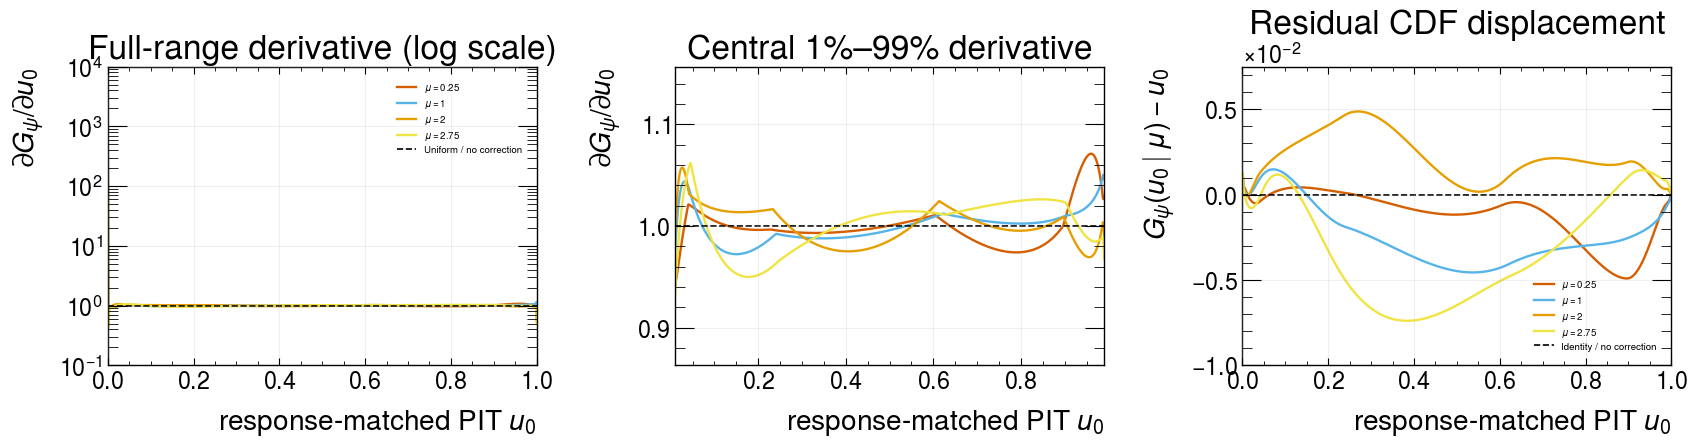

Wrote standalone figure script: exercise11_figures_scripts/direct_pit_cdf_training_closure.py


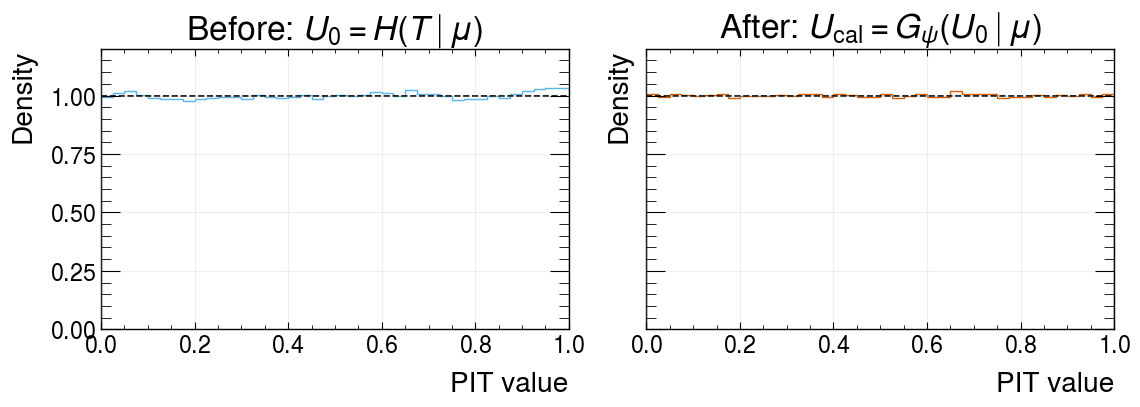

Wrote standalone figure script: exercise11_figures_scripts/direct_pit_cdf_conditional_pp.py


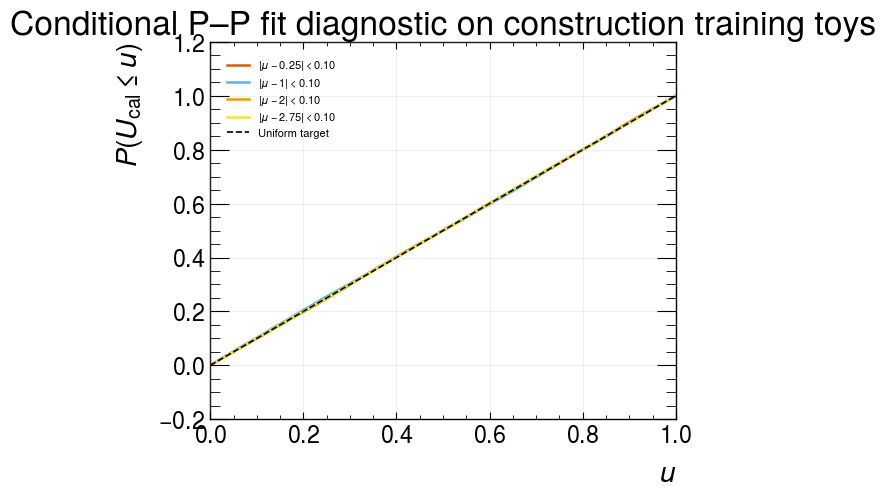

In [39]:
def evaluate_residual_cdf(mu, u0):
    '''Evaluate G_psi(u0 | mu), including exact PIT-space limits.'''
    mu, u0 = np.broadcast_arrays(
        np.asarray(mu, dtype=np.float64),
        np.asarray(u0, dtype=np.float64),
    )
    output_shape = mu.shape
    mu = mu.reshape(-1)
    u0 = u0.reshape(-1)
    if (
        not np.isfinite(mu).all()
        or not np.isfinite(u0).all()
        or np.any(mu < MU_RANGE[0])
        or np.any(mu > MU_RANGE[1])
        or np.any(u0 < 0.0)
        or np.any(u0 > 1.0)
    ):
        raise ValueError("mu must lie in the design range and u0 in [0, 1].")
    result = np.empty_like(u0)
    lower = u0 <= 0.0
    upper = u0 >= 1.0
    interior = ~(lower | upper)
    result[lower] = 0.0
    result[upper] = 1.0
    if np.any(interior):
        w = norm.ppf(u0[interior]).astype(np.float32)
        result[interior] = scalar_spline_flow_cdf(
            pit_cdf_flow,
            w[:, None],
            context=mu[interior, None].astype(np.float32),
        )
    return np.clip(result, 0.0, 1.0).reshape(output_shape)


def invert_residual_cdf(mu, probability):
    '''Evaluate the analytic inverse G_psi^{-1}(probability | mu).'''
    mu, probability = np.broadcast_arrays(
        np.asarray(mu, dtype=np.float64),
        np.asarray(probability, dtype=np.float64),
    )
    output_shape = mu.shape
    mu = mu.reshape(-1)
    probability = probability.reshape(-1)
    if (
        not np.isfinite(mu).all()
        or not np.isfinite(probability).all()
        or np.any(mu < MU_RANGE[0])
        or np.any(mu > MU_RANGE[1])
        or np.any(probability <= 0.0)
        or np.any(probability >= 1.0)
    ):
        raise ValueError(
            "mu must lie in the design range and probabilities in (0, 1)."
        )
    w_quantile = scalar_spline_flow_icdf(
        pit_cdf_flow,
        probability,
        context=mu[:, None].astype(np.float32),
    )
    return norm.cdf(w_quantile).reshape(output_shape)


PIT_EVALUATION_OVERFLOW_COUNTS = {"lower": 0, "upper": 0}


def evaluate_response_pit(mu, t_mu):
    '''Evaluate only the hNDE-derived reference PIT U0=H(t|mu).'''
    mu = np.asarray(mu, dtype=np.float64).reshape(-1)
    t_mu = np.asarray(t_mu, dtype=np.float64).reshape(-1)
    if (
        len(mu) != len(t_mu)
        or not np.isfinite(mu).all()
        or np.isnan(t_mu).any()
        or np.any(t_mu < 0.0)
    ):
        raise ValueError(
            "mu/t_mu must be matched; mu must be finite and t_mu "
            "must be non-negative and not NaN."
        )
    if np.any(mu <= MU_RANGE[0]) or np.any(mu >= MU_RANGE[1]):
        raise ValueError("Use the empirical rules at exact physical endpoints.")
    y = np.log(t_mu + T_OFFSET)
    if np.any(y < Y_MIN - 1.0e-10):
        raise RuntimeError(
            "A non-negative statistic fell materially below log(T_OFFSET)."
        )
    lower = y < Y_MIN
    upper = y > Y_MAX
    interior = ~(lower | upper)
    u0 = np.empty_like(y)
    if np.any(interior):
        u0[interior] = conditional_cdf_values(
            hybrid1_grid["cdf"], MU_DENSITY_GRID, Y_GRID,
            mu[interior], y[interior],
        )
    u0[lower] = 0.0
    u0[upper] = 1.0
    for side, mask in (("lower", lower), ("upper", upper)):
        count = int(mask.sum())
        if count:
            PIT_EVALUATION_OVERFLOW_COUNTS[side] += count
            print(
                f"PIT evaluation mapped {count:,} {side}-support rows to "
                f"the exact CDF limit (cumulative "
                f"{PIT_EVALUATION_OVERFLOW_COUNTS[side]:,})."
            )
    return u0


def evaluate_calibrated_pit(mu, t_mu):
    '''Return the hNDE reference PIT U0 and direct-flow pivot Ucal.'''
    mu = np.asarray(mu, dtype=np.float64).reshape(-1)
    u0 = evaluate_response_pit(mu, t_mu)
    return u0, evaluate_residual_cdf(mu, u0)


def evaluate_calibrated_statistic(mu, t_mu):
    '''Map Ucal to a chi-square-looking display coordinate.'''
    _, u_cal = evaluate_calibrated_pit(mu, t_mu)
    return chi2.ppf(np.clip(u_cal, 1.0e-12, 1.0 - 1.0e-12), df=1)


U_GRID = np.linspace(0.0, 1.0, PIT_DIAGNOSTIC_POINTS)
grid_mu = np.repeat(MU_DENSITY_GRID, len(U_GRID))
grid_u = np.tile(U_GRID, len(MU_DENSITY_GRID))
grid_cdf = evaluate_residual_cdf(grid_mu, grid_u).reshape(
    len(MU_DENSITY_GRID), len(U_GRID)
)

density_u = np.clip(grid_u, 1.0e-7, 1.0 - 1.0e-7)
density_w = norm.ppf(density_u).astype(np.float32)
grid_log_density = (
    spline_flow_log_prob(
        pit_cdf_flow,
        density_w[:, None],
        context=grid_mu[:, None].astype(np.float32),
    ).astype(np.float64)
    - norm.logpdf(density_w.astype(np.float64))
).reshape(len(MU_DENSITY_GRID), len(U_GRID))
grid_density = np.exp(grid_log_density)
calibration_grid = {
    "cdf": grid_cdf,
    "density": grid_density,
    "log_density": grid_log_density,
}

if (
    np.max(np.abs(grid_cdf[:, 0])) > 1.0e-12
    or np.max(np.abs(grid_cdf[:, -1] - 1.0)) > 1.0e-12
    or np.min(np.diff(grid_cdf, axis=1)) < -1.0e-7
    or not np.isfinite(grid_density).all()
    or np.any(grid_density <= 0.0)
):
    raise RuntimeError("The direct residual flow is not a valid CDF/density.")

# These levels test numerical invertibility, not statistical tail calibration.
roundtrip_levels = np.asarray([
    1.0e-5, 1.0e-4, .001, .01, .05, .50,
    .95, .99, .999, 1.0 - 1.0e-4, 1.0 - 1.0e-5,
])
roundtrip_mu = np.repeat(MU_DENSITY_GRID, len(roundtrip_levels))
roundtrip_probability = np.tile(roundtrip_levels, len(MU_DENSITY_GRID))
roundtrip_u = invert_residual_cdf(roundtrip_mu, roundtrip_probability)
roundtrip_probability_back = evaluate_residual_cdf(
    roundtrip_mu, roundtrip_u
)
roundtrip_error = np.abs(
    roundtrip_probability_back - roundtrip_probability
).reshape(len(MU_DENSITY_GRID), len(roundtrip_levels))
pit_inverse_error = float(np.max(roundtrip_error))
if pit_inverse_error > 2.0e-5:
    raise RuntimeError(
        "The direct PIT-CDF flow failed its analytic inverse round trip."
    )
roundtrip_max_error_by_level = np.max(roundtrip_error, axis=0)
roundtrip_endpoint_scale = np.minimum(
    roundtrip_levels, 1.0 - roundtrip_levels
)
roundtrip_table = pd.DataFrame({
    "probability": roundtrip_levels,
    "max_absolute_roundtrip_error_over_mu": roundtrip_max_error_by_level,
    "max_error_relative_to_nearest_tail_probability": (
        roundtrip_max_error_by_level / roundtrip_endpoint_scale
    ),
})
print(
    "Maximum numerical G(G^{-1}(gamma)) error over "
    "[1e-5, 1-1e-5]:",
    pit_inverse_error,
)
display(roundtrip_table.style.format({
    "probability": "{:.6g}",
    "max_absolute_roundtrip_error_over_mu": "{:.3e}",
    "max_error_relative_to_nearest_tail_probability": "{:.3e}",
}).hide(axis="index"))

central_density_mask = (
    (U_GRID >= .01) & (U_GRID <= .99)
)
central_log_density = grid_log_density[:, central_density_mask]
print(
    "Residual log-density range, full diagnostic PIT grid:",
    [float(np.min(grid_log_density)), float(np.max(grid_log_density))],
)
print(
    "Residual log-density range, central 1%-99% PIT region:",
    [float(np.min(central_log_density)),
     float(np.max(central_log_density))],
)
print(
    "Maximum absolute residual-CDF displacement from identity:",
    float(np.max(np.abs(grid_cdf - U_GRID[None, :]))),
)

_, calibration_u_cal = evaluate_calibrated_pit(
    calibration_mu, simulator_calibration_toys["t_mu"]
)

selected_mu = [0.25, 1.0, 2.0, 2.75]
selected_density_curves = []
fig, axes = plt.subplots(1, 3, figsize=(17.2, 4.7))
for mu_value in selected_mu:
    index = int(np.argmin(np.abs(MU_DENSITY_GRID - mu_value)))
    density_curve = calibration_grid["density"][index]
    selected_density_curves.append(density_curve)
    label = rf"$\mu={mu_value:g}$"
    axes[0].plot(U_GRID, density_curve, lw=1.7, label=label)
    axes[1].plot(U_GRID, density_curve, lw=1.7)
    axes[2].plot(
        U_GRID, calibration_grid["cdf"][index] - U_GRID,
        lw=1.7, label=label,
    )

axes[0].axhline(1.0, color="black", ls="--", lw=1.2,
                label="Uniform / no correction")
axes[0].set_yscale("log")
axes[0].set(
    xlim=(0.0, 1.0),
    xlabel=r"response-matched PIT $u_0$",
    ylabel=r"$\partial G_\psi/\partial u_0$",
    title="Full-range derivative (log scale)",
)

central_plot_mask = (U_GRID >= .01) & (U_GRID <= .99)
selected_central_density = np.asarray(selected_density_curves)[
    :, central_plot_mask
]
central_low = max(1.0e-6, .92 * float(np.min(selected_central_density)))
central_high = 1.08 * float(np.max(selected_central_density))
axes[1].axhline(1.0, color="black", ls="--", lw=1.2)
axes[1].set(
    xlim=(.01, .99), ylim=(central_low, central_high),
    xlabel=r"response-matched PIT $u_0$",
    ylabel=r"$\partial G_\psi/\partial u_0$",
    title="Central 1%–99% derivative",
)

axes[2].axhline(0.0, color="black", ls="--", lw=1.2,
                label="Identity / no correction")
axes[2].set(
    xlim=(0.0, 1.0),
    xlabel=r"response-matched PIT $u_0$",
    ylabel=r"$G_\psi(u_0\mid\mu)-u_0$",
    title="Residual CDF displacement",
)
for ax in axes:
    ax.grid(alpha=.2)
axes[0].legend(fontsize=7)
axes[2].legend(fontsize=7)
fig.tight_layout()
export_exercise11_figure(fig, "direct_pit_cdf_and_derivative")
plt.show()

bins = np.linspace(0.0, 1.0, 41)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
axes[0].hist(calibration_u0_raw, bins=bins, density=True,
             histtype="step", lw=2, color="C1")
axes[1].hist(calibration_u_cal, bins=bins, density=True,
             histtype="step", lw=2, color="C0")
for ax in axes:
    ax.axhline(1.0, color="black", ls="--", lw=1.2)
    ax.set(xlim=(0, 1), xlabel="PIT value", ylabel="Density")
    ax.grid(alpha=.2)
axes[0].set_title(r"Before: $U_0=H(T\mid\mu)$")
axes[1].set_title(r"After: $U_{\rm cal}=G_\psi(U_0\mid\mu)$")
fig.tight_layout()
export_exercise11_figure(fig, "direct_pit_cdf_training_closure")
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
pp_grid = np.linspace(0.0, 1.0, 101)
for mu_value in selected_mu:
    mask = np.abs(calibration_mu - mu_value) < 0.10
    values = np.sort(calibration_u_cal[mask])
    empirical = np.searchsorted(values, pp_grid, side="right") / len(values)
    ax.plot(pp_grid, empirical, lw=1.8,
            label=rf"$|\mu-{mu_value:g}|<0.10$")
ax.plot(pp_grid, pp_grid, "k--", lw=1.2, label="Uniform target")
ax.set(
    xlabel=r"$u$",
    ylabel=r"$P(U_{\rm cal}\leq u)$",
    title="Conditional P–P fit diagnostic on construction training toys",
)
ax.grid(alpha=.2)
ax.legend(fontsize=8)
fig.tight_layout()
export_exercise11_figure(fig, "direct_pit_cdf_conditional_pp")
plt.show()


## 10. Analytic residual quantiles, physical endpoints, and Neyman inversion

The direct flow provides the residual quantile analytically,

$$
u_\gamma(\mu)=G_\psi^{-1}(\gamma\mid\mu),
\qquad
c_\gamma(\mu)
=H^{-1}(u_\gamma(\mu)\mid\mu).
$$

We compare these curves with the response-matched hNDE quantiles and with direct, coarse binned simulator quantiles. The latter reuse the calibration ensemble and are therefore construction diagnostics rather than independent validation.

### The two physical endpoints

Exact endpoints of the PIT coordinate are handled structurally by the flow, but this is unrelated to exact endpoints of the physical parameter. The compressed Poisson statistic is formally discrete at every physical parameter value, so the smooth interior flow is a learned continuous calibration and does not carry an exact finite-sample rank guarantee anywhere by itself. The two physical endpoints require an additional treatment for a separate reason: the continuous proposal draws no training point exactly at $\mu=0$ or $3$. Their empirical order-statistic rules use dedicated endpoint calibration toys and retain a same-law finite-Monte-Carlo rank statement.

The full construction uses **1,000,000 toys per endpoint** for empirical critical values and a separate **1,000,000-toy external-template ensemble per endpoint** to measure transfer. With $n$ construction toys, and for levels for which the rank below satisfies $k\leq n$ as it does here, the finite-sample cutoff is

$$
k=\left\lceil\gamma(n+1)\right\rceil,
\qquad c_\gamma=T_{(k)}.
$$

If the construction toys and a future test toy are exchangeable draws from the same endpoint law, this gives unconditional same-law acceptance probability $k/(n+1)\geq\gamma$ in the continuous case; ties in a nonrandomized $T\leq c_\gamma$ rule can only increase acceptance. The statement averages over the random construction cutoff. It is neither a conditional guarantee for the realized cutoff nor a conservatism guarantee after transfer to the different external-template law. Endpoint rules remain piecewise and are not inserted into the smooth interior interpolant.


Maximum nested/composed quantile difference in y: 2.545113659846443e-05
Wrote standalone figure script: exercise11_figures_scripts/conditional_pit_quantile_corrections.py


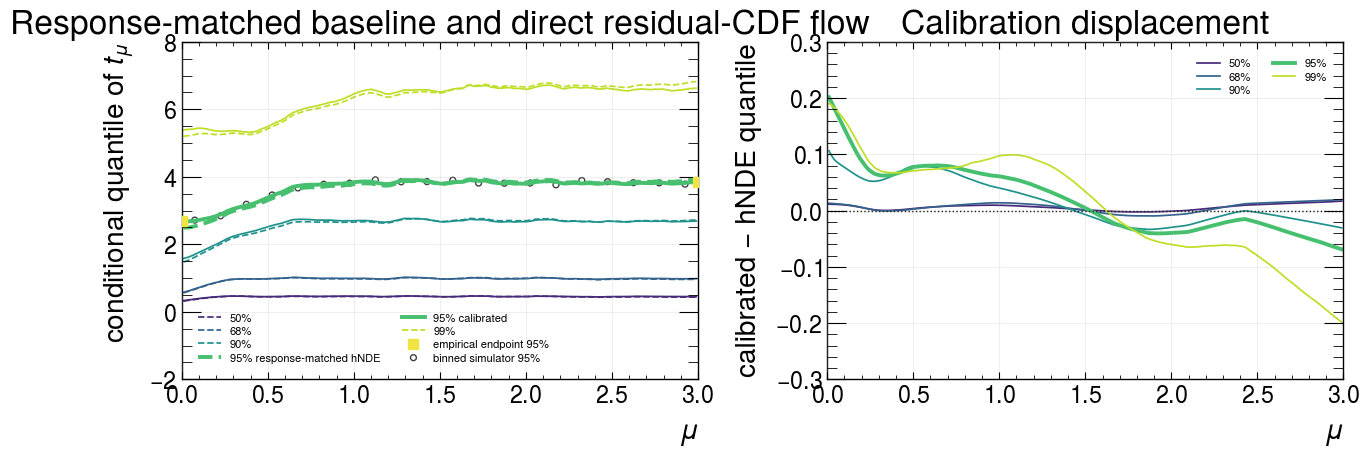

Wrote standalone figure script: exercise11_figures_scripts/conditional_pit_cdf_primitives.py


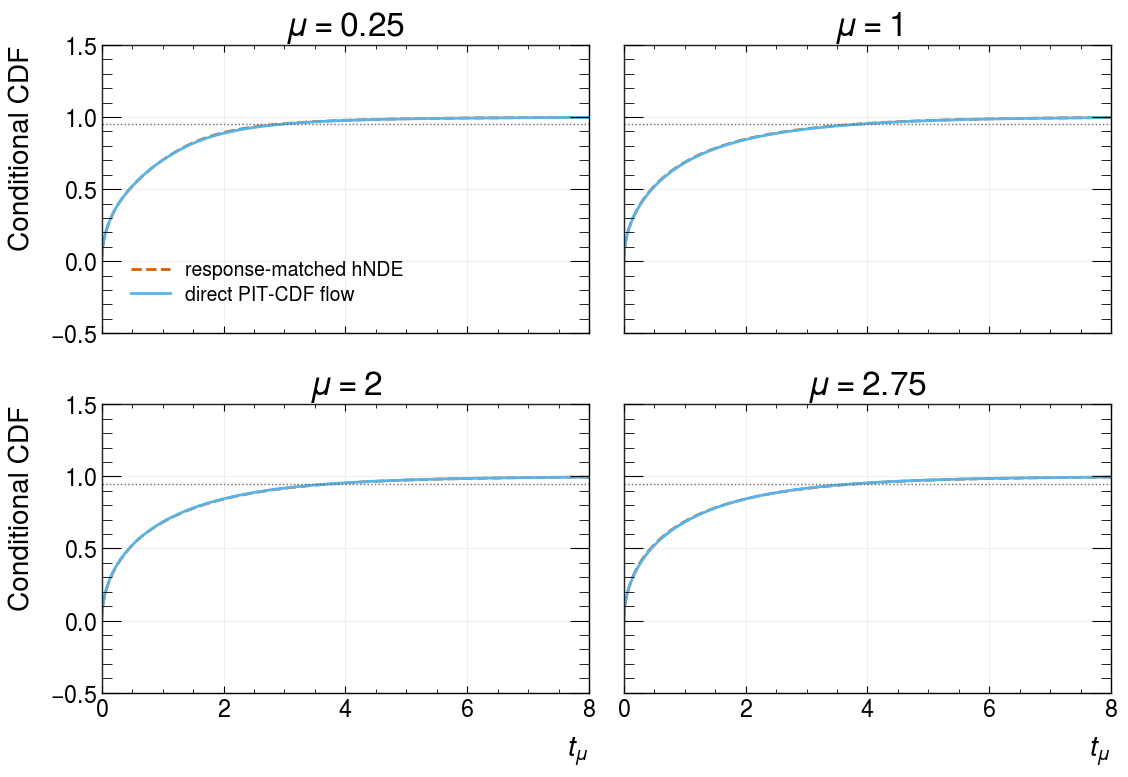

In [40]:
quantile_mu = np.repeat(MU_DENSITY_GRID, len(QUANTILE_LEVELS))
quantile_probability = np.tile(QUANTILE_LEVELS, len(MU_DENSITY_GRID))
calibration_u0_quantiles = invert_residual_cdf(
    quantile_mu, quantile_probability
).reshape(len(MU_DENSITY_GRID), len(QUANTILE_LEVELS))
calibrated_quantile_y = conditional_row_quantiles(
    hybrid1_grid["cdf"],
    Y_GRID,
    calibration_u0_quantiles,
)
calibrated_quantile_t = np.maximum(
    np.exp(calibrated_quantile_y) - T_OFFSET, 0.0
)

calibrated_cdf_grid = evaluate_residual_cdf(
    np.repeat(MU_DENSITY_GRID, len(Y_GRID)),
    hybrid1_grid["cdf"].reshape(-1),
).reshape(len(MU_DENSITY_GRID), len(Y_GRID))
composed_quantile_y = conditional_quantiles(
    calibrated_cdf_grid, Y_GRID, QUANTILE_LEVELS
)
composition_difference = np.max(np.abs(
    composed_quantile_y - calibrated_quantile_y
))
print(
    "Maximum nested/composed quantile difference in y:",
    composition_difference,
)
if composition_difference > 2.0 * np.max(np.diff(Y_GRID)):
    raise RuntimeError("Nested and composed conditional CDFs disagree.")

index_95 = int(np.flatnonzero(
    np.isclose(QUANTILE_LEVELS, .95)
)[0])
critical_hnde_grid = hybrid1_quantile_t[:, index_95]
critical_calibrated_grid = calibrated_quantile_t[:, index_95]
critical_calibrated_smooth = PchipInterpolator(
    MU_DENSITY_GRID, critical_calibrated_grid, extrapolate=False
)

anchor_hnde = {}
anchor_simulator = {}
anchor_hnde_quantiles = []
anchor_simulator_quantiles = []
for anchor_mu in ANCHOR_MUS:
    key = f"mu_{anchor_mu:g}".replace(".", "p")
    anchor_hnde[anchor_mu] = run_cached_toy_ensemble(
        cache_dir=CACHE_DIR / f"anchor_hnde_{key}_{N_ANCHOR_TOYS}",
        n_toys=N_ANCHOR_TOYS,
        batch_size=TOY_BATCH_SIZE,
        seed=SEED + 900 + int(100 * anchor_mu),
        mu_range=MU_RANGE,
        fixed_mu=float(anchor_mu),
        signal_probability=HNDE_SIGNAL_PROBABILITY,
        background_probability=HNDE_BACKGROUND_PROBABILITY,
        lam_signal=LAM_SIG,
        lam_background=LAM_BKG,
        likelihood_q=COMPRESSED_Q,
        fit_batch=fit_toy_batch_numpy,
        fit_fingerprint=TOY_FIT_FINGERPRINT,
        fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
        generation_mu_transform=pseudo_truth_response,
        test_mu_transform=pseudo_truth_response,
        generation_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
        test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
    )
    anchor_simulator[anchor_mu] = run_cached_toy_ensemble(
        cache_dir=(
            PIT_CACHE_DIR
            / f"anchor_simulator_construction_{key}_{N_ANCHOR_TOYS}"
        ),
        n_toys=N_ANCHOR_TOYS,
        batch_size=TOY_BATCH_SIZE,
        seed=SEED + 910 + int(100 * anchor_mu),
        mu_range=MU_RANGE,
        fixed_mu=float(anchor_mu),
        signal_probability=SIM_CALIBRATION_SIGNAL_PROBABILITY,
        background_probability=SIM_CALIBRATION_BACKGROUND_PROBABILITY,
        lam_signal=LAM_SIG,
        lam_background=LAM_BKG,
        likelihood_q=COMPRESSED_Q,
        fit_batch=fit_toy_batch_numpy,
        fit_fingerprint=TOY_FIT_FINGERPRINT,
        fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
        test_mu_transform=pseudo_truth_response,
        test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
    )
    anchor_hnde_quantiles.append(conservative_empirical_quantile(
        anchor_hnde[anchor_mu]["t_mu"], QUANTILE_LEVELS
    ))
    anchor_simulator_quantiles.append(conservative_empirical_quantile(
        anchor_simulator[anchor_mu]["t_mu"], QUANTILE_LEVELS
    ))
anchor_hnde_quantiles = np.asarray(anchor_hnde_quantiles)
anchor_simulator_quantiles = np.asarray(anchor_simulator_quantiles)

def neyman_accepts_95(mu, t_mu):
    """Apply the endpoint-aware rule to response-corrected t_mu^(g)."""
    mu, t_mu = np.broadcast_arrays(
        np.asarray(mu, dtype=np.float64),
        np.asarray(t_mu, dtype=np.float64),
    )
    output_shape = mu.shape
    mu = mu.reshape(-1)
    t_mu = t_mu.reshape(-1)
    if np.any(t_mu < 0.0) or not np.isfinite(t_mu).all():
        raise ValueError("t_mu must be finite and non-negative.")
    if (
        not np.isfinite(mu).all()
        or np.any(mu < MU_RANGE[0])
        or np.any(mu > MU_RANGE[1])
    ):
        raise ValueError("mu lies outside the calibrated parameter range.")
    accepted = np.empty(len(mu), dtype=bool)
    assigned = np.zeros(len(mu), dtype=bool)
    interior = (mu > MU_RANGE[0]) & (mu < MU_RANGE[1])
    if np.any(interior):
        _, u_cal = evaluate_calibrated_pit(mu[interior], t_mu[interior])
        accepted[interior] = u_cal <= .95
        assigned[interior] = True
    for anchor_index, anchor_mu in enumerate(ANCHOR_MUS):
        endpoint = mu == anchor_mu
        accepted[endpoint] = (
            t_mu[endpoint]
            <= anchor_simulator_quantiles[anchor_index, index_95]
        )
        assigned[endpoint] = True
    if not np.all(assigned):
        raise ValueError("mu lies outside the calibrated parameter range.")
    return accepted.reshape(output_shape)

calibration_quantile_edges = np.linspace(*MU_RANGE, 21)
calibration_quantile_centers = 0.5 * (
    calibration_quantile_edges[:-1] + calibration_quantile_edges[1:]
)
calibration_bin_index = np.clip(
    np.digitize(calibration_mu, calibration_quantile_edges) - 1,
    0,
    len(calibration_quantile_centers) - 1,
)
direct_calibration_q95 = np.asarray([
    conservative_empirical_quantile(
        simulator_calibration_toys["t_mu"][calibration_bin_index == i],
        .95,
    )
    for i in range(len(calibration_quantile_centers))
])

np.savez_compressed(
    PIT_RESULT_DIR / "direct_pit_cdf_calibration.npz",
    mu=MU_DENSITY_GRID,
    levels=QUANTILE_LEVELS,
    hnde=hybrid1_quantile_t,
    simulator_calibrated=calibrated_quantile_t,
    endpoint_mu=ANCHOR_MUS,
    endpoint_hnde=anchor_hnde_quantiles,
    endpoint_simulator=anchor_simulator_quantiles,
    u_grid=U_GRID,
    calibration_cdf=calibration_grid["cdf"],
    response_mu=RESPONSE_MU_GRID,
    response_g=response_grid,
    method=np.asarray("hnde_reference_plus_direct_probit_rqs_v1"),
    flow_checkpoint=np.asarray(str(PIT_CDF_FLOW_CHECKPOINT)),
    flow_training_fingerprint=np.asarray(
        pit_cdf_flow.get("training_fingerprint") or ""
    ),
    identity_validation_nll=np.asarray(identity_validation_nll),
    selected_validation_nll=np.asarray(selected_validation_nll),
    probit_epsilon=np.asarray(PROBIT_EPS),
)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
colors = plt.cm.viridis(np.linspace(.12, .9, len(QUANTILE_LEVELS)))
interior_grid = slice(1, -1)
for level, color, before, after in zip(
    QUANTILE_LEVELS,
    colors,
    hybrid1_quantile_t.T,
    calibrated_quantile_t.T,
):
    linewidth = 2.8 if np.isclose(level, .95) else 1.25
    axes[0].plot(
        MU_DENSITY_GRID[interior_grid], before[interior_grid],
        color=color, ls="--", lw=linewidth,
        label=(rf"{level:.0%} response-matched hNDE"
               if np.isclose(level, .95)
               else rf"{level:.0%}"),
    )
    axes[0].plot(
        MU_DENSITY_GRID[interior_grid], after[interior_grid],
        color=color, lw=linewidth,
        label=(rf"{level:.0%} calibrated"
               if np.isclose(level, .95) else None),
    )
    axes[1].plot(
        MU_DENSITY_GRID[interior_grid],
        (after - before)[interior_grid],
        color=color, lw=linewidth, label=rf"{level:.0%}",
    )
axes[0].scatter(
    ANCHOR_MUS,
    anchor_simulator_quantiles[:, index_95],
    marker="s", s=42, color="C3", zorder=5,
    label="empirical endpoint 95%",
)
axes[0].scatter(
    calibration_quantile_centers,
    direct_calibration_q95,
    marker="o", s=18, facecolors="none", edgecolors="0.25",
    label="binned simulator 95%",
)
axes[0].set(
    xlabel=r"$\mu$", ylabel=r"conditional quantile of $t_\mu$",
    title="Response-matched baseline and direct residual-CDF flow",
)
axes[1].axhline(0.0, color="black", ls=":", lw=1)
axes[1].set(
    xlabel=r"$\mu$", ylabel="calibrated − hNDE quantile",
    title="Calibration displacement",
)
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
export_exercise11_figure(fig, "conditional_pit_quantile_corrections")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0),
                         sharex=True, sharey=True)
t_grid = np.maximum(np.exp(Y_GRID) - T_OFFSET, 0.0)
for ax, mu_value in zip(axes.flat, [0.25, 1.0, 2.0, 2.75]):
    index = int(np.argmin(np.abs(MU_DENSITY_GRID - mu_value)))
    ax.plot(t_grid, hybrid1_grid["cdf"][index], ls="--", lw=2,
            label="response-matched hNDE")
    ax.plot(t_grid, calibrated_cdf_grid[index], lw=2,
            label="direct PIT-CDF flow")
    ax.axhline(.95, color="0.4", ls=":", lw=1)
    ax.set_xlim(
        0, max(8.0, float(critical_calibrated_grid[index]) * 1.5)
    )
    ax.set_title(rf"$\mu={mu_value:g}$")
    ax.grid(alpha=.2)
for ax in axes[-1]:
    ax.set_xlabel(r"$t_\mu$")
for ax in axes[:, 0]:
    ax.set_ylabel("Conditional CDF")
axes[0, 0].legend()
fig.tight_layout()
export_exercise11_figure(fig, "conditional_pit_cdf_primitives")
plt.show()


## 11. Construction-law holdout control

Before evaluating the external benchmark, use a pseudo-experiment ensemble from the same fixed 64M construction template used by $g$ and by the direct residual-CDF flow. Its seeds and toy rows are disjoint from flow fitting; the historical cache is reused unchanged. This regression holdout asks whether the learned conditional map reproduces its declared construction law. It was observed in the preceding method study, so it is not newly sealed evidence for this refactor.

It does not test transfer to independent simulator events or quantify finite-template uncertainty. A failure here is calibration-model error; a discrepancy that appears only on the independent external template is template-transfer sensitivity.

In addition to the primary 95% coverage, the holdout now reports: global P–P deviations at several fixed probability levels; the global Kolmogorov–Smirnov distance; and the largest KS distances in 20 physical-$\mu$ bins. The table includes ordinary pointwise KS thresholds and a conservative family-wise Dvoretzky–Kiefer–Wolfowitz threshold. These are frozen-model diagnostics, not hyperparameter selection criteria. The fixed probability levels are nested and correlated; their standardized deviations are pointwise, toy-Monte-Carlo diagnostics rather than simultaneous significances. Very extreme levels with only a handful of expected holdout events are intentionally not advertised as calibrated.


Construction-holdout response-baseline coverage: 94.9392%
Construction-holdout direct-CDF coverage: 95.0168%
Construction-holdout direct-CDF binned range: [94.6215%, 95.4589%]
Construction-holdout global PIT KS distance: 0.0026155566297709765
Construction-holdout global P–P checks:


probability,observed_fraction,observed_minus_nominal,nominal_binomial_se,pointwise_standardized_deviation,nearest_tail,expected_nearest_tail_count,observed_nearest_tail_count
0.100%,0.100%,-0.0004%,0.0063%,-0.06,lower,250.0,249
1.000%,1.015%,+0.0152%,0.0199%,+0.76,lower,"2,500.0","2,538"
5.000%,5.010%,+0.0100%,0.0436%,+0.23,lower,"12,500.0","12,525"
50.000%,50.236%,+0.2364%,0.1000%,+2.36,lower,"125,000.0","125,591"
90.000%,90.023%,+0.0232%,0.0600%,+0.39,upper,"25,000.0","24,942"
95.000%,95.017%,+0.0168%,0.0436%,+0.39,upper,"12,500.0","12,458"
99.000%,98.974%,-0.0260%,0.0199%,-1.31,upper,"2,500.0","2,565"
99.900%,99.897%,-0.0032%,0.0063%,-0.51,upper,250.0,258


Construction-holdout conditional KS: maximum / bins above pointwise threshold / bins above family-wise DKW threshold: 0.012685504303956208 1 0


mu_low,mu_high,n_toys,ks_distance,pointwise_5pct_asymptotic,familywise_5pct_DKW,exceeds_pointwise_5pct,exceeds_familywise_5pct_DKW
1.65,1.80,"12,396",0.01269,0.01220,0.01642,True,False
1.95,2.10,"12,651",0.01116,0.01207,0.01625,False,False
1.35,1.50,"12,473",0.01097,0.01216,0.01637,False,False
2.85,3.00,"12,533",0.00945,0.01213,0.01633,False,False
0.75,0.90,"12,647",0.00933,0.01208,0.01626,False,False


Wrote standalone figure script: exercise11_figures_scripts/direct_pit_cdf_holdout_pp.py


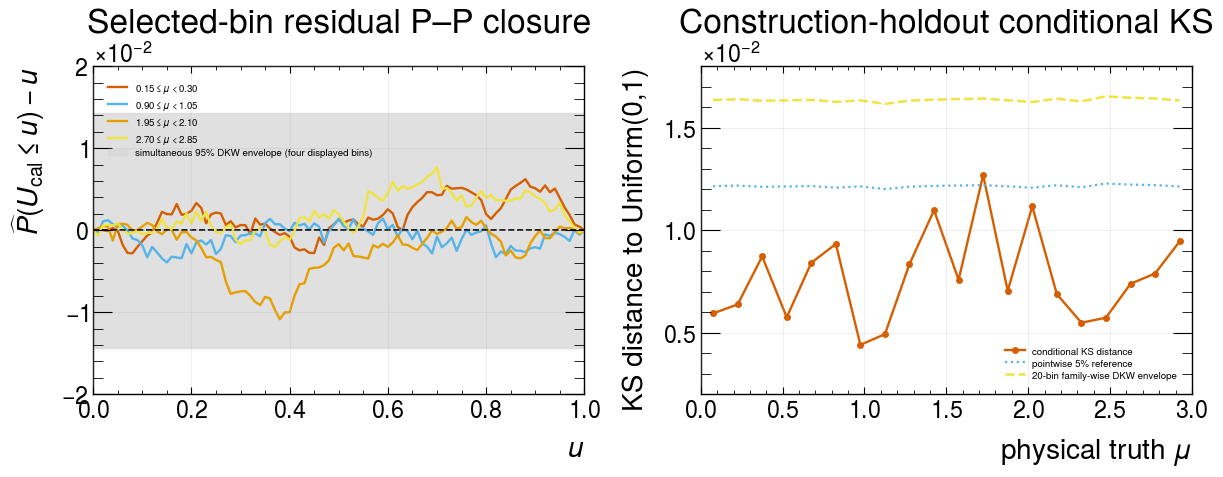

In [41]:
# Historical cache directory name retained to reuse the same toy rows.
simulator_construction_holdout_toys = run_cached_toy_ensemble(
    cache_dir=(
        PIT_CACHE_DIR
        / f"simulator_construction_internal_audit_"
          f"{N_CONSTRUCTION_HOLDOUT_TOYS}"
    ),
    n_toys=N_CONSTRUCTION_HOLDOUT_TOYS,
    batch_size=TOY_BATCH_SIZE,
    seed=SEED + 1000,
    mu_range=MU_RANGE,
    signal_probability=SIM_CALIBRATION_SIGNAL_PROBABILITY,
    background_probability=SIM_CALIBRATION_BACKGROUND_PROBABILITY,
    lam_signal=LAM_SIG,
    lam_background=LAM_BKG,
    likelihood_q=COMPRESSED_Q,
    fit_batch=fit_toy_batch_numpy,
    fit_fingerprint=TOY_FIT_FINGERPRINT,
    fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
    test_mu_transform=pseudo_truth_response,
    test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
)
holdout_mu = simulator_construction_holdout_toys["mu"].astype(np.float64)
holdout_t = simulator_construction_holdout_toys["t_mu"].astype(np.float64)
if not np.allclose(
    simulator_construction_holdout_toys["generation_mu"], holdout_mu,
    rtol=0.0, atol=2.0e-6,
) or not np.allclose(
    simulator_construction_holdout_toys["test_mu"],
    pseudo_truth_response(holdout_mu),
    rtol=0.0, atol=2.0e-6,
):
    raise RuntimeError("The construction-holdout cache has stale coordinates.")
holdout_u0, holdout_u_cal = evaluate_calibrated_pit(
    holdout_mu, holdout_t
)
holdout_covered_hnde = holdout_u0 <= .95
holdout_covered_calibrated = holdout_u_cal <= .95
if not np.array_equal(
    neyman_accepts_95(holdout_mu, holdout_t),
    holdout_covered_calibrated,
):
    raise RuntimeError(
        "Endpoint-aware decisions disagree in the open-interval holdout."
    )
coverage_edges = np.linspace(*MU_RANGE, 21)
binned_holdout = binned_coverage(
    holdout_mu, holdout_covered_calibrated, edges=coverage_edges
)
print(
    "Construction-holdout response-baseline coverage:",
    f"{holdout_covered_hnde.mean():.4%}",
)
print(
    "Construction-holdout direct-CDF coverage:",
    f"{holdout_covered_calibrated.mean():.4%}",
)
print(
    "Construction-holdout direct-CDF binned range:",
    f"[{binned_holdout['coverage'].min():.4%}, "
    f"{binned_holdout['coverage'].max():.4%}]",
)

holdout_sorted = np.sort(holdout_u_cal)
holdout_rank = np.arange(1, len(holdout_sorted) + 1) / len(holdout_sorted)
holdout_ks = float(max(
    np.max(holdout_rank - holdout_sorted),
    np.max(holdout_sorted - (holdout_rank - 1.0 / len(holdout_sorted))),
))
print("Construction-holdout global PIT KS distance:", holdout_ks)

# Global probability-level checks complement the single registered 95% rule.
# Levels below 0.1% are omitted because this holdout would contain too few
# expected tail events for a useful empirical statement.
HOLDOUT_PIT_LEVELS = np.asarray([
    .001, .01, .05, .50, .90, .95, .99, .999,
])
holdout_level_rows = []
for probability in HOLDOUT_PIT_LEVELS:
    observed = float(np.mean(holdout_u_cal <= probability))
    nominal_se = float(np.sqrt(
        probability * (1.0 - probability) / len(holdout_u_cal)
    ))
    if probability <= .50:
        nearest_tail = "lower"
        observed_tail_count = int(np.sum(holdout_u_cal <= probability))
    else:
        nearest_tail = "upper"
        observed_tail_count = int(np.sum(holdout_u_cal > probability))
    holdout_level_rows.append({
        "probability": probability,
        "observed_fraction": observed,
        "observed_minus_nominal": observed - probability,
        "nominal_binomial_se": nominal_se,
        "pointwise_standardized_deviation": (
            (observed - probability) / nominal_se
        ),
        "nearest_tail": nearest_tail,
        "expected_nearest_tail_count": (
            len(holdout_u_cal) * min(probability, 1.0 - probability)
        ),
        "observed_nearest_tail_count": observed_tail_count,
    })
holdout_level_table = pd.DataFrame(holdout_level_rows)
print("Construction-holdout global P–P checks:")
display(holdout_level_table.style.format({
    "probability": "{:.3%}",
    "observed_fraction": "{:.3%}",
    "observed_minus_nominal": "{:+.4%}",
    "nominal_binomial_se": "{:.4%}",
    "pointwise_standardized_deviation": "{:+.2f}",
    "expected_nearest_tail_count": "{:,.1f}",
    "observed_nearest_tail_count": "{:,.0f}",
}).hide(axis="index"))

def uniform_ks_distance(values):
    values = np.sort(np.asarray(values, dtype=np.float64))
    n_values = len(values)
    ranks = np.arange(1, n_values + 1, dtype=np.float64) / n_values
    return float(max(
        np.max(ranks - values),
        np.max(values - (ranks - 1.0 / n_values)),
    ))


conditional_ks_rows = []
n_conditional_bins = len(coverage_edges) - 1
for bin_index, (mu_low, mu_high) in enumerate(zip(
    coverage_edges[:-1], coverage_edges[1:]
)):
    if bin_index == n_conditional_bins - 1:
        mask = (holdout_mu >= mu_low) & (holdout_mu <= mu_high)
    else:
        mask = (holdout_mu >= mu_low) & (holdout_mu < mu_high)
    n_bin = int(mask.sum())
    if n_bin <= 0:
        raise RuntimeError("An empty mu bin invalidates the conditional KS check.")
    ks_bin = uniform_ks_distance(holdout_u_cal[mask])
    conditional_ks_rows.append({
        "mu_low": mu_low,
        "mu_high": mu_high,
        "n_toys": n_bin,
        "ks_distance": ks_bin,
        "pointwise_5pct_asymptotic": 1.3581 / np.sqrt(n_bin),
        # Union-bound DKW threshold across all physical-mu bins.
        "familywise_5pct_DKW": np.sqrt(
            np.log(2.0 * n_conditional_bins / .05) / (2.0 * n_bin)
        ),
    })
conditional_ks_table = pd.DataFrame(conditional_ks_rows)
conditional_ks_table["exceeds_pointwise_5pct"] = (
    conditional_ks_table["ks_distance"]
    > conditional_ks_table["pointwise_5pct_asymptotic"]
)
conditional_ks_table["exceeds_familywise_5pct_DKW"] = (
    conditional_ks_table["ks_distance"]
    > conditional_ks_table["familywise_5pct_DKW"]
)
conditional_ks_worst = conditional_ks_table.sort_values(
    "ks_distance", ascending=False
).head(5)
print(
    "Construction-holdout conditional KS: maximum / bins above "
    "pointwise threshold / bins above family-wise DKW threshold:",
    float(conditional_ks_table["ks_distance"].max()),
    int(conditional_ks_table["exceeds_pointwise_5pct"].sum()),
    int(conditional_ks_table["exceeds_familywise_5pct_DKW"].sum()),
)
display(conditional_ks_worst.style.format({
    "mu_low": "{:.2f}",
    "mu_high": "{:.2f}",
    "n_toys": "{:,.0f}",
    "ks_distance": "{:.5f}",
    "pointwise_5pct_asymptotic": "{:.5f}",
    "familywise_5pct_DKW": "{:.5f}",
}).hide(axis="index"))

# Show small P–P departures as residuals and place the omnibus
# conditional KS distances beside them. The four display bins are selected
# in advance from the same non-overlapping 20-bin partition used above.
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0))
holdout_pp_grid = np.linspace(0.0, 1.0, 101)
selected_pp_bin_indices = [1, 6, 13, 18]
selected_pp_counts = []
for bin_index in selected_pp_bin_indices:
    mu_low = coverage_edges[bin_index]
    mu_high = coverage_edges[bin_index + 1]
    mask = (holdout_mu >= mu_low) & (holdout_mu < mu_high)
    values = np.sort(holdout_u_cal[mask])
    selected_pp_counts.append(len(values))
    empirical = (
        np.searchsorted(values, holdout_pp_grid, side="right")
        / len(values)
    )
    axes[0].plot(
        holdout_pp_grid, empirical - holdout_pp_grid, lw=1.7,
        label=rf"${mu_low:.2f}\leq\mu<{mu_high:.2f}$",
    )
selected_pp_dkw = np.sqrt(
    np.log(2.0 * len(selected_pp_bin_indices) / .05)
    / (2.0 * min(selected_pp_counts))
)
axes[0].fill_between(
    holdout_pp_grid, -selected_pp_dkw, selected_pp_dkw,
    color="0.85", alpha=.8,
    label="simultaneous 95% DKW envelope (four displayed bins)",
)
axes[0].axhline(0.0, color="black", ls="--", lw=1.2)
axes[0].set(
    xlabel=r"$u$",
    ylabel=r"$\widehat P(U_{\rm cal}\leq u)-u$",
    title="Selected-bin residual P–P closure",
)
axes[0].legend(fontsize=7)

conditional_ks_centers = .5 * (
    conditional_ks_table["mu_low"] + conditional_ks_table["mu_high"]
)
axes[1].plot(
    conditional_ks_centers, conditional_ks_table["ks_distance"],
    marker="o", ms=4, lw=1.7, label="conditional KS distance",
)
axes[1].plot(
    conditional_ks_centers,
    conditional_ks_table["pointwise_5pct_asymptotic"],
    color="C1", ls=":", lw=1.6, label="pointwise 5% reference",
)
axes[1].plot(
    conditional_ks_centers,
    conditional_ks_table["familywise_5pct_DKW"],
    color="C3", ls="--", lw=1.8,
    label="20-bin family-wise DKW envelope",
)
axes[1].set(
    xlim=MU_RANGE,
    xlabel=r"physical truth $\mu$",
    ylabel="KS distance to Uniform(0,1)",
    title="Construction-holdout conditional KS",
)
axes[1].legend(fontsize=7)
for ax in axes:
    ax.grid(alpha=.2)
fig.tight_layout()
export_exercise11_figure(fig, "direct_pit_cdf_holdout_pp")
plt.show()


## 12. Finite-construction-template bootstrap sensitivity diagnostic

The construction reservoir contains finitely many simulator events. To probe sensitivity of the **fixed** procedure, resample the signal and background compressed bin counts multinomially, generate toys under each bootstrap template, and apply the frozen response map and calibrated pivot.

This is not an independent coverage audit and not a clean confidence interval for template uncertainty. Every replicate derives from the same construction events, and its measured coverage combines template displacement with finite pseudo-experiment noise. The code therefore reports both the between-replicate variance and the mean binomial toy variance; if the latter is comparable to or larger than the former, raw bootstrap quantiles must be described as toy-Monte-Carlo dominated.

Recomputing $g$ and recalibrating inside each bootstrap would define a different hierarchical procedure and is intentionally left as a separate study.


In [42]:
def multinomial_template_bootstrap(counts, rng):
    counts = np.asarray(counts, dtype=np.int64)
    if np.any(counts < 0) or counts.sum() <= 0:
        raise ValueError("Bootstrap template counts must be non-negative.")
    draw = rng.multinomial(
        int(counts.sum()), counts / counts.sum()
    ).astype(np.float64)
    draw += 1.0e-15
    return draw / draw.sum()


template_bootstrap_rows = []
template_bootstrap_binned = []
bootstrap_edges = np.linspace(*MU_RANGE, 11)
for replicate in range(N_TEMPLATE_BOOTSTRAPS):
    rng = np.random.default_rng(
        np.random.SeedSequence([SEED, 1200, replicate])
    )
    bootstrap_signal_probability = multinomial_template_bootstrap(
        SIM_CALIBRATION_SIGNAL_COUNTS, rng
    )
    bootstrap_background_probability = multinomial_template_bootstrap(
        SIM_CALIBRATION_BACKGROUND_COUNTS, rng
    )
    bootstrap_toys = run_cached_toy_ensemble(
        cache_dir=(
            PIT_CACHE_DIR
            / f"construction_template_bootstrap_{replicate:03d}_"
              f"{N_TOYS_PER_TEMPLATE_BOOTSTRAP}"
        ),
        n_toys=N_TOYS_PER_TEMPLATE_BOOTSTRAP,
        batch_size=TOY_BATCH_SIZE,
        seed=SEED + 1300 + replicate,
        mu_range=MU_RANGE,
        signal_probability=bootstrap_signal_probability,
        background_probability=bootstrap_background_probability,
        lam_signal=LAM_SIG,
        lam_background=LAM_BKG,
        likelihood_q=COMPRESSED_Q,
        fit_batch=fit_toy_batch_numpy,
        fit_fingerprint=TOY_FIT_FINGERPRINT,
        fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
        test_mu_transform=pseudo_truth_response,
        test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
    )
    bootstrap_covered = neyman_accepts_95(
        bootstrap_toys["mu"], bootstrap_toys["t_mu"]
    )
    successes = int(bootstrap_covered.sum())
    lower, upper = wilson_interval(successes, len(bootstrap_covered))
    template_bootstrap_rows.append({
        "replicate": replicate,
        "coverage": float(bootstrap_covered.mean()),
        "toy_wilson_lower": float(lower),
        "toy_wilson_upper": float(upper),
    })
    template_bootstrap_binned.append(
        binned_coverage(
            bootstrap_toys["mu"],
            bootstrap_covered,
            edges=bootstrap_edges,
        )["coverage"]
    )

template_bootstrap_table = pd.DataFrame(template_bootstrap_rows)
template_bootstrap_binned = np.asarray(template_bootstrap_binned)
bootstrap_global_interval = np.quantile(
    template_bootstrap_table["coverage"], [.025, .5, .975]
)
bootstrap_replicate_variance = float(
    template_bootstrap_table["coverage"].var(ddof=1)
)
bootstrap_mean_toy_variance = float(np.mean(
    template_bootstrap_table["coverage"]
    * (1.0 - template_bootstrap_table["coverage"])
    / N_TOYS_PER_TEMPLATE_BOOTSTRAP
))
bootstrap_deconvolved_template_std = float(np.sqrt(max(
    0.0, bootstrap_replicate_variance - bootstrap_mean_toy_variance
)))
bootstrap_binned_interval = np.quantile(
    template_bootstrap_binned, [.025, .5, .975], axis=0
)
display(
    template_bootstrap_table.describe().T.style.format(precision=6)
)
print(
    "Raw bootstrap-coverage 2.5/50/97.5% quantiles (not a template CI):",
    bootstrap_global_interval,
)
print(
    "Between-replicate variance / mean toy-binomial variance / "
    "deconvolved template std:",
    bootstrap_replicate_variance, bootstrap_mean_toy_variance,
    bootstrap_deconvolved_template_std,
)
if bootstrap_mean_toy_variance >= bootstrap_replicate_variance:
    print(
        "WARNING: the raw bootstrap spread is toy-Monte-Carlo dominated; "
        "it does not resolve finite-template uncertainty."
    )
penultimate = template_convergence_table[
    (template_convergence_table["source"] == "fresh nested construction")
    & (template_convergence_table["selected_per_process"] == int(TEMPLATE_SELECTED_CHECKPOINTS[-2]))
].iloc[0]
print(
    f"Penultimate-prefix ({int(TEMPLATE_SELECTED_CHECKPOINTS[-2]):,}) "
    f"L1 to the {FINAL_TEMPLATE_EVENTS:,} construction: "
    f"signal={penultimate['signal_L1_to_64M']:.6f}, "
    f"background={penultimate['background_L1_to_64M']:.6f}."
)


,count,mean,std,min,25%,50%,75%,max
replicate,20.000000,9.500000,5.916080,0.000000,4.750000,9.500000,14.250000,19.000000
coverage,20.000000,0.949607,0.001405,0.947550,0.948400,0.949475,0.950975,0.951500
toy_wilson_lower,20.000000,0.946489,0.001444,0.944374,0.945247,0.946352,0.947895,0.948435
toy_wilson_upper,20.000000,0.952554,0.001364,0.950555,0.951381,0.952425,0.953882,0.954391


Raw bootstrap-coverage 2.5/50/97.5% quantiles (not a template CI): [0.94766875 0.949475   0.9514525 ]
Between-replicate variance / mean toy-binomial variance / deconvolved template std: 1.972703947368441e-06 2.39256109375e-06 0.0
Penultimate-prefix (16,000,000) L1 to the 64,000,000 construction: signal=0.002670, background=0.002133.


## 13. Evaluate the previously opened independent 64M benchmark

The direct-CDF procedure is now frozen relative to its construction law: $g_{64\mathrm M}$, the hNDE reference $H$, the residual flow $G_\psi$, physical-endpoint rules, and interpolated cutoffs have all been defined without changing either 64M event reservoir.

The independent 64M template is now loaded and used as a controlled external regression benchmark. It first reports construction-to-benchmark differences in:

- PRESEL acceptance;
- selected-feature histograms;
- raw $q$-template $L^1$;
- likelihood-score displacement through $|S_A(g_N;\mu)|/\sqrt{I_A(g_N;\mu)}$ and $g_N(\mu)-g_A(\mu)$.

The 500,000-toy result estimates transfer coverage for this second finite empirical law. Because the same benchmark was examined before choosing the direct-flow refactor, it is not a newly sealed confirmatory audit. The construction-law holdout remains the clean algorithmic calibration check; a future confirmatory transfer claim requires another independent reservoir.


Loaded fixed independent 64M benchmark: {'signal': 64000000, 'background': 64000000}
Construction/benchmark q-template L1 differences: signal=0.002007, background=0.001750


construction_prefix,max_abs_gN_minus_g_benchmark,max_standardized_benchmark_score
"250,000",0.169999,0.3056
"1,000,000",0.078171,0.1406
"4,000,000",0.029047,0.0522
"16,000,000",0.036280,0.0652
"64,000,000",0.019793,0.0356


process,feature,construction_benchmark_L1
signal,x1,0.000457
signal,x2,0.000343
signal,x3,0.000580
signal,x4,0.000667
signal,x5,0.000406
background,x1,0.000359
background,x2,0.000524
background,x3,0.000661
background,x4,0.000576
background,x5,0.000564


process,construction_acceptance,benchmark_acceptance,relative_difference
signal,55.563744%,55.563115%,-0.0011%
background,15.278075%,15.278352%,+0.0018%


Wrote standalone figure script: exercise11_figures_scripts/external_benchmark_response_and_score_transfer.py


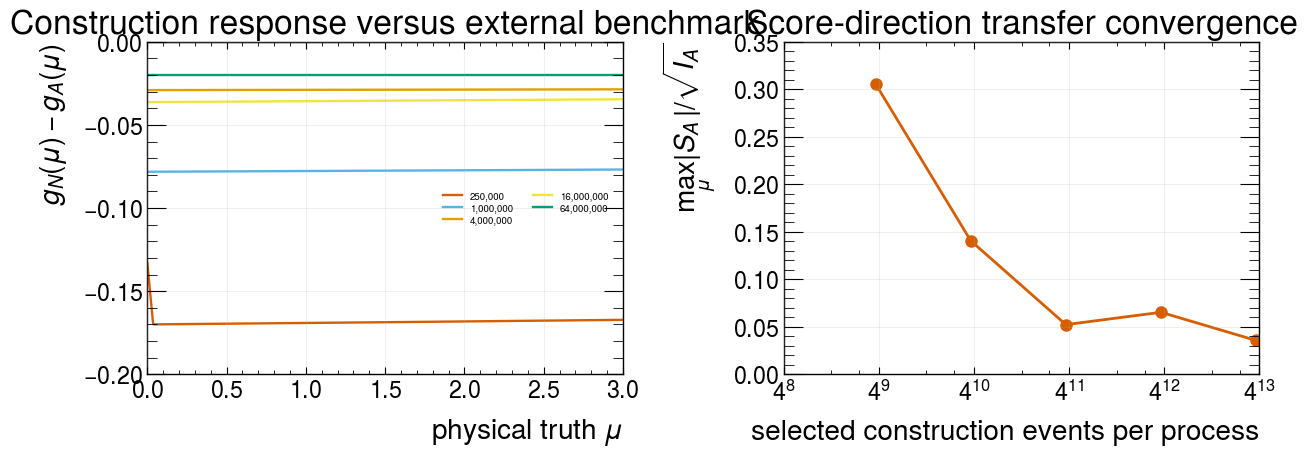

Pivot/cutoff decision disagreement: 0.0008%
Independent-benchmark response-baseline coverage: 94.8488%
Independent-benchmark direct-CDF coverage: 94.9374%
Algebraically equivalent chi-square-coordinate decision coverage: 94.9374%
Loading coverage auditor from models_exercise11_hybrid_neyman_v1/full_direct_pit_cdf_v1/coverage_auditor_directcdf_external64m_95cl.pt
Independent-benchmark global coverage: 94.9374%
Held-out test BCE, fixed p=0.95: 0.201185
Held-out test BCE, training-split constant p=0.949469: 0.201178
Held-out test BCE, conditional auditor: 0.201178
Independent-benchmark predicted-coverage range (descriptive): [94.9409%, 94.9470%]


In [43]:
EXTERNAL_BENCHMARK_STREAM_RESULTS = {}
for process in ("signal", "background"):
    EXTERNAL_BENCHMARK_STREAM_RESULTS[process] = load_streamed_simulator_template(
        cache_path=EXTERNAL_BENCHMARK_TEMPLATE_PATHS[process],
        process=process,
        selected_checkpoints=TEMPLATE_SELECTED_CHECKPOINTS,
        batch_size=FRESH_SIMULATOR_BATCH_SIZE,
        seed=EXTERNAL_BENCHMARK_SEED[process],
        feature_names=FEATURES,
        feature_edges=FEATURE_DIAGNOSTIC_EDGES,
        log_q_edges=LOG_Q_EDGES,
        presel_ratio_cut=PRESEL_RATIO_CUT,
        recipe_fingerprint=f"{STREAM_RECIPE_FINGERPRINT}:audit",
        expose_counts=True,
    )
    if (
        EXTERNAL_BENCHMARK_STREAM_RESULTS[process]["fingerprint"]
        != EXTERNAL_BENCHMARK_STREAM_SUMMARIES[process]["fingerprint"]
    ):
        raise RuntimeError(
            f"The {process} external benchmark differs from its recorded "
            "construction-time fingerprint."
        )

SIM_EXTERNAL_SIGNAL_COUNTS_BY_CHECKPOINT = np.asarray(
    EXTERNAL_BENCHMARK_STREAM_RESULTS["signal"]["q_counts"], dtype=np.int64
)
SIM_EXTERNAL_BACKGROUND_COUNTS_BY_CHECKPOINT = np.asarray(
    EXTERNAL_BENCHMARK_STREAM_RESULTS["background"]["q_counts"], dtype=np.int64
)
SIM_EXTERNAL_SIGNAL_FEATURE_COUNTS_BY_CHECKPOINT = np.asarray(
    EXTERNAL_BENCHMARK_STREAM_RESULTS["signal"]["feature_counts"], dtype=np.int64
)
SIM_EXTERNAL_BACKGROUND_FEATURE_COUNTS_BY_CHECKPOINT = np.asarray(
    EXTERNAL_BENCHMARK_STREAM_RESULTS["background"]["feature_counts"], dtype=np.int64
)
SIM_EXTERNAL_SIGNAL_COUNTS = SIM_EXTERNAL_SIGNAL_COUNTS_BY_CHECKPOINT[-1]
SIM_EXTERNAL_BACKGROUND_COUNTS = SIM_EXTERNAL_BACKGROUND_COUNTS_BY_CHECKPOINT[-1]
SIM_EXTERNAL_SIGNAL_PROBABILITY = SIM_EXTERNAL_SIGNAL_COUNTS / FINAL_TEMPLATE_EVENTS
SIM_EXTERNAL_BACKGROUND_PROBABILITY = SIM_EXTERNAL_BACKGROUND_COUNTS / FINAL_TEMPLATE_EVENTS
SIM_EXTERNAL_EVENTS = {
    process: int(EXTERNAL_BENCHMARK_STREAM_RESULTS[process]["selected_events"])
    for process in ("signal", "background")
}
if SIM_EXTERNAL_EVENTS != {
    "signal": FINAL_TEMPLATE_EVENTS, "background": FINAL_TEMPLATE_EVENTS
}:
    raise RuntimeError("The external benchmark does not have the recorded size.")

benchmark_signal_l1 = float(np.sum(np.abs(
    SIM_EXTERNAL_SIGNAL_PROBABILITY - SIM_CALIBRATION_SIGNAL_PROBABILITY
)))
benchmark_background_l1 = float(np.sum(np.abs(
    SIM_EXTERNAL_BACKGROUND_PROBABILITY - SIM_CALIBRATION_BACKGROUND_PROBABILITY
)))
benchmark_response_grid = template_response_grid(
    SIM_EXTERNAL_SIGNAL_PROBABILITY, SIM_EXTERNAL_BACKGROUND_PROBABILITY
)

benchmark_score_rows = []
for checkpoint_index, selected_events in enumerate(TEMPLATE_SELECTED_CHECKPOINTS):
    standardized = standardized_score_drift(
        PREFIX_RESPONSE_GRIDS[checkpoint_index],
        SIM_EXTERNAL_SIGNAL_PROBABILITY,
        SIM_EXTERNAL_BACKGROUND_PROBABILITY,
    )
    benchmark_score_rows.append({
        "construction_prefix": int(selected_events),
        "max_abs_gN_minus_g_benchmark": float(np.max(np.abs(
            PREFIX_RESPONSE_GRIDS[checkpoint_index] - benchmark_response_grid
        ))),
        "max_standardized_benchmark_score": float(np.max(standardized)),
    })
benchmark_score_convergence_table = pd.DataFrame(benchmark_score_rows)

benchmark_feature_rows = []
for process, construction_counts, benchmark_counts in (
    (
        "signal", SIM_CALIBRATION_SIGNAL_FEATURE_COUNTS_BY_CHECKPOINT[-1],
        SIM_EXTERNAL_SIGNAL_FEATURE_COUNTS_BY_CHECKPOINT[-1],
    ),
    (
        "background", SIM_CALIBRATION_BACKGROUND_FEATURE_COUNTS_BY_CHECKPOINT[-1],
        SIM_EXTERNAL_BACKGROUND_FEATURE_COUNTS_BY_CHECKPOINT[-1],
    ),
):
    for feature_index, feature in enumerate(FEATURES):
        benchmark_feature_rows.append({
            "process": process,
            "feature": feature,
            "construction_benchmark_L1": float(np.sum(np.abs(
                construction_counts[feature_index] / FINAL_TEMPLATE_EVENTS
                - benchmark_counts[feature_index] / FINAL_TEMPLATE_EVENTS
            ))),
        })
benchmark_feature_closure_table = pd.DataFrame(benchmark_feature_rows)

print("Loaded fixed independent 64M benchmark:", SIM_EXTERNAL_EVENTS)
print(
    "Construction/benchmark q-template L1 differences:",
    f"signal={benchmark_signal_l1:.6f}, background={benchmark_background_l1:.6f}",
)
display(benchmark_score_convergence_table.style.format({
    "construction_prefix": "{:,.0f}",
    "max_abs_gN_minus_g_benchmark": "{:.6f}",
    "max_standardized_benchmark_score": "{:.4f}",
}).hide(axis="index"))
display(benchmark_feature_closure_table.style.format(precision=6).hide(axis="index"))
display(pd.DataFrame([
    {
        "process": process,
        "construction_acceptance": CONSTRUCTION_STREAM_RESULTS[process]["acceptance"],
        "benchmark_acceptance": EXTERNAL_BENCHMARK_STREAM_RESULTS[process]["acceptance"],
        "relative_difference": (
            EXTERNAL_BENCHMARK_STREAM_RESULTS[process]["acceptance"]
            / CONSTRUCTION_STREAM_RESULTS[process]["acceptance"] - 1.0
        ),
    }
    for process in ("signal", "background")
]).style.format({
    "construction_acceptance": "{:.6%}",
    "benchmark_acceptance": "{:.6%}",
    "relative_difference": "{:+.4%}",
}).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
for checkpoint_index, selected_events in enumerate(TEMPLATE_SELECTED_CHECKPOINTS):
    axes[0].plot(
        RESPONSE_MU_GRID,
        PREFIX_RESPONSE_GRIDS[checkpoint_index] - benchmark_response_grid,
        lw=1.7, label=f"{int(selected_events):,}",
    )
axes[0].axhline(0.0, color="0.5", lw=1.0)
axes[0].set(
    xlabel=r"physical truth $\mu$",
    ylabel=r"$g_N(\mu)-g_A(\mu)$",
    title="Construction response versus external benchmark",
)
axes[0].grid(alpha=.2)
axes[0].legend(fontsize=7, ncol=2)
axes[1].plot(
    benchmark_score_convergence_table["construction_prefix"],
    benchmark_score_convergence_table["max_standardized_benchmark_score"],
    marker="o", lw=2.0,
)
axes[1].set_xscale("log", base=4)
axes[1].set(
    xlabel="selected construction events per process",
    ylabel=r"$\max_\mu |S_A|/\sqrt{I_A}$",
    title="Score-direction transfer convergence",
)
axes[1].grid(alpha=.2)
fig.tight_layout()
export_exercise11_figure(
    fig, "external_benchmark_response_and_score_transfer"
)
plt.show()

# Historical `new64m_audit` cache directory retained unchanged.
simulator_external_benchmark_toys = run_cached_toy_ensemble(
    cache_dir=(
        PIT_CACHE_DIR
        / f"simulator_new64m_audit_{N_EXTERNAL_BENCHMARK_TOYS}"
    ),
    n_toys=N_EXTERNAL_BENCHMARK_TOYS,
    batch_size=TOY_BATCH_SIZE,
    seed=SEED + 1_900,
    mu_range=MU_RANGE,
    signal_probability=SIM_EXTERNAL_SIGNAL_PROBABILITY,
    background_probability=SIM_EXTERNAL_BACKGROUND_PROBABILITY,
    lam_signal=LAM_SIG,
    lam_background=LAM_BKG,
    likelihood_q=COMPRESSED_Q,
    fit_batch=fit_toy_batch_numpy,
    fit_fingerprint=TOY_FIT_FINGERPRINT,
    fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
    test_mu_transform=pseudo_truth_response,
    test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
)
benchmark_mu = simulator_external_benchmark_toys["mu"].astype(np.float64)
benchmark_t = simulator_external_benchmark_toys["t_mu"].astype(np.float64)
if not np.allclose(
    simulator_external_benchmark_toys["generation_mu"], benchmark_mu,
    rtol=0.0, atol=2.0e-6,
) or not np.allclose(
    simulator_external_benchmark_toys["test_mu"], pseudo_truth_response(benchmark_mu),
    rtol=0.0, atol=2.0e-6,
):
    raise RuntimeError("The external-benchmark toy cache has stale coordinates.")

benchmark_u0, benchmark_u_cal = evaluate_calibrated_pit(benchmark_mu, benchmark_t)
benchmark_covered_hnde = benchmark_u0 <= .95
benchmark_covered_calibrated = benchmark_u_cal <= .95
if not np.array_equal(neyman_accepts_95(benchmark_mu, benchmark_t), benchmark_covered_calibrated):
    raise RuntimeError("The endpoint-aware helper disagrees with the interior PIT rule.")

benchmark_critical_calibrated = critical_calibrated_smooth(benchmark_mu)
covered_by_cutoff = benchmark_t <= benchmark_critical_calibrated
cutoff_disagreement = float(np.mean(covered_by_cutoff != benchmark_covered_calibrated))
print(f"Pivot/cutoff decision disagreement: {cutoff_disagreement:.4%}")
if cutoff_disagreement > 2.0e-3:
    print(
        "WARNING: the auxiliary interpolated cutoff disagrees with more than "
        "0.2% of direct pivot decisions. Refine the mu/y/u grids before using "
        "the smooth cutoff as a numerical substitute."
    )

benchmark_t_cal = evaluate_calibrated_statistic(benchmark_mu, benchmark_t)
print("Independent-benchmark response-baseline coverage:", f"{benchmark_covered_hnde.mean():.4%}")
print("Independent-benchmark direct-CDF coverage:", f"{benchmark_covered_calibrated.mean():.4%}")
print(
    "Algebraically equivalent chi-square-coordinate decision coverage:",
    f"{np.mean(benchmark_t_cal <= chi2.ppf(.95, df=1)):.4%}",
)

coverage_auditor = train_coverage_auditor(
    benchmark_mu,
    benchmark_covered_calibrated,
    checkpoint=PIT_MODEL_DIR / "coverage_auditor_directcdf_external64m_95cl.pt",
    model_config=AUDITOR_MODEL_CONFIG,
    training_config=AUDITOR_TRAINING_CONFIG,
    device=device,
    seed=SEED + 1_910,
    load_if_available=LOAD_IF_AVAILABLE,
)
auditor_grid = coverage_auditor_probability(coverage_auditor, MU_DENSITY_GRID)
observed_coverage = float(benchmark_covered_calibrated.mean())
test_indices = np.asarray(
    coverage_auditor.get("test_indices", []), dtype=np.int64
)
validation_indices = np.asarray(
    coverage_auditor.get("validation_indices", []), dtype=np.int64
)
if len(test_indices) == 0 or len(validation_indices) == 0:
    raise RuntimeError(
        "The direct-CDF coverage auditor lacks held-out split metadata. "
        "Use the new PIT_METHOD_TAG checkpoint."
    )
training_mask = np.ones(len(benchmark_mu), dtype=bool)
training_mask[test_indices] = False
training_mask[validation_indices] = False
training_indices = np.flatnonzero(training_mask)

def heldout_bce(labels, probability):
    labels = np.asarray(labels, dtype=np.float64)
    probability = np.clip(
        np.asarray(probability, dtype=np.float64), 1.0e-12, 1.0 - 1.0e-12
    )
    return -float(np.mean(
        labels * np.log(probability)
        + (1.0 - labels) * np.log(1.0 - probability)
    ))

test_labels = benchmark_covered_calibrated[test_indices].astype(np.float64)
training_constant = float(np.mean(benchmark_covered_calibrated[training_indices]))
test_auditor_probability = coverage_auditor_probability(
    coverage_auditor, benchmark_mu[test_indices]
)
fixed_nominal_test_bce = heldout_bce(test_labels, .95)
training_constant_test_bce = heldout_bce(test_labels, training_constant)
auditor_test_bce = heldout_bce(test_labels, test_auditor_probability)
print("Independent-benchmark global coverage:", f"{observed_coverage:.4%}")
print(f"Held-out test BCE, fixed p=0.95: {fixed_nominal_test_bce:.6f}")
print(
    "Held-out test BCE, training-split constant "
    f"p={training_constant:.6f}: {training_constant_test_bce:.6f}"
)
print(f"Held-out test BCE, conditional auditor: {auditor_test_bce:.6f}")
print(
    "Independent-benchmark predicted-coverage range (descriptive):",
    f"[{auditor_grid.min():.4%}, {auditor_grid.max():.4%}]",
)


## 14. Post-benchmark fixed-$\mu$ transfer versus template size

The full neural calibration is trained only once at the registered 64M construction size. To diagnose how finite-template transfer changes with reservoir size, this section builds a simpler rank-based empirical-cutoff procedure at each nested prefix:

1. compute that prefix's response $g_N(\mu)$;
2. at six fixed $\mu$ values, obtain an empirical 95% critical value from toys generated by the same prefix law;
3. apply the frozen cutoff to common toys from the fixed full-64M external benchmark.

This measures transfer without training five neural pipelines. The full run uses 50,000 construction and 50,000 external toys at each $(N,\mu)$ point. Common external toy seeds across $N$ reduce noise in the comparison. Wilson intervals cover only external-toy binomial error conditional on the estimated construction cutoff; they omit cutoff order-statistic uncertainty. Since the benchmark was already open, this study is diagnostic and cannot be used as confirmatory retuning evidence.


selected_per_process,mu,critical_95,same_template_coverage,external_transfer_coverage,benchmark_mc_lower_given_cutoff,benchmark_mc_upper_given_cutoff
"250,000",0.00,2.46212,95.0020%,90.9020%,90.6468%,91.1509%
"250,000",0.25,2.68269,95.0020%,90.9640%,90.7095%,91.2122%
"250,000",0.50,3.09239,95.0020%,92.2300%,91.9921%,92.4614%
"250,000",1.00,3.84117,95.0020%,94.0660%,93.8555%,94.2697%
"250,000",2.00,3.84343,95.0020%,94.0340%,93.8230%,94.2382%
"250,000",3.00,3.86946,95.0020%,94.1640%,93.9551%,94.3661%
"1,000,000",0.00,2.69147,95.0020%,93.3800%,93.1587%,93.5946%
"1,000,000",0.25,2.80792,95.0020%,93.7240%,93.5080%,93.9332%
"1,000,000",0.50,3.35440,95.0020%,94.4640%,94.2601%,94.6611%
"1,000,000",1.00,3.83846,95.0020%,94.8120%,94.6141%,95.0030%


Wrote standalone figure script: exercise11_figures_scripts/fixed_mu_template_size_coverage_transfer.py


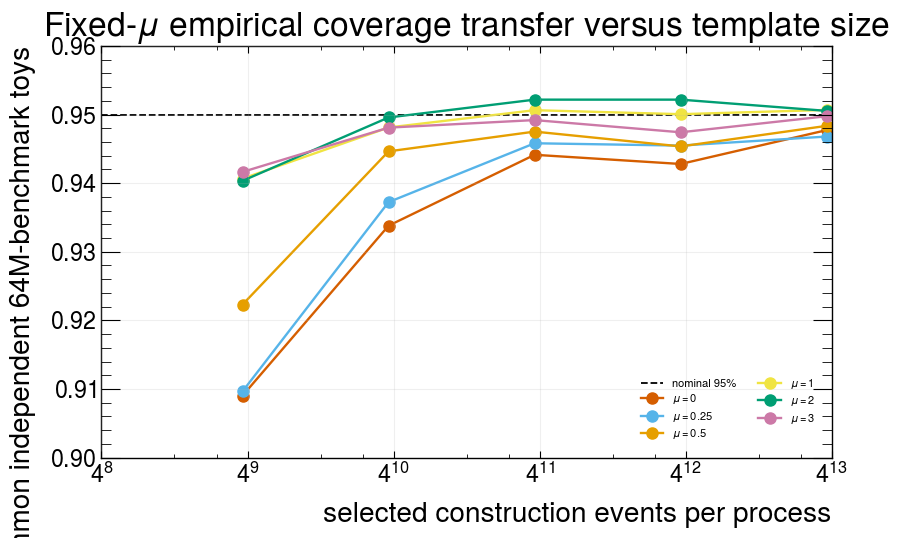

In [44]:
prefix_transfer_rows = []
for checkpoint_index, selected_events in enumerate(TEMPLATE_SELECTED_CHECKPOINTS):
    prefix_signal_probability = SIM_CALIBRATION_SIGNAL_PROBABILITY_BY_CHECKPOINT[
        checkpoint_index
    ]
    prefix_background_probability = SIM_CALIBRATION_BACKGROUND_PROBABILITY_BY_CHECKPOINT[
        checkpoint_index
    ]
    response_interpolator_N = PchipInterpolator(
        RESPONSE_MU_GRID,
        PREFIX_RESPONSE_GRIDS[checkpoint_index],
        extrapolate=False,
    )

    def response_N(mu, interpolator=response_interpolator_N):
        values = np.asarray(mu, dtype=np.float64)
        return np.asarray(interpolator(values), dtype=np.float64)

    response_fingerprint_N = PREFIX_RESPONSE_FINGERPRINTS[checkpoint_index]
    for mu_index, fixed_mu in enumerate(PREFIX_TRANSFER_MUS):
        key = f"mu_{fixed_mu:g}".replace(".", "p")
        construction_toys_N = run_cached_toy_ensemble(
            cache_dir=(
                PIT_CACHE_DIR / "prefix_transfer"
                / f"construction_N{int(selected_events)}_{key}_{N_PREFIX_TRANSFER_TOYS}"
            ),
            n_toys=N_PREFIX_TRANSFER_TOYS,
            batch_size=TOY_BATCH_SIZE,
            seed=SEED + 2_000 + mu_index,
            mu_range=MU_RANGE,
            fixed_mu=float(fixed_mu),
            signal_probability=prefix_signal_probability,
            background_probability=prefix_background_probability,
            lam_signal=LAM_SIG,
            lam_background=LAM_BKG,
            likelihood_q=COMPRESSED_Q,
            fit_batch=fit_toy_batch_numpy,
            fit_fingerprint=TOY_FIT_FINGERPRINT,
            fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
            test_mu_transform=response_N,
            test_mu_fingerprint=response_fingerprint_N,
        )
        critical_N = float(conservative_empirical_quantile(
            construction_toys_N["t_mu"], .95
        ))
        benchmark_toys_N = run_cached_toy_ensemble(
            cache_dir=(
                PIT_CACHE_DIR / "prefix_transfer"
                # Historical cache name retained to reuse the same toys.
                / f"audit_N{int(selected_events)}_{key}_{N_PREFIX_TRANSFER_TOYS}"
            ),
            n_toys=N_PREFIX_TRANSFER_TOYS,
            batch_size=TOY_BATCH_SIZE,
            # The same seed and external-template probabilities at fixed
            # mu yield common benchmark counts across every prefix N.
            seed=SEED + 2_100 + mu_index,
            mu_range=MU_RANGE,
            fixed_mu=float(fixed_mu),
            signal_probability=SIM_EXTERNAL_SIGNAL_PROBABILITY,
            background_probability=SIM_EXTERNAL_BACKGROUND_PROBABILITY,
            lam_signal=LAM_SIG,
            lam_background=LAM_BKG,
            likelihood_q=COMPRESSED_Q,
            fit_batch=fit_toy_batch_numpy,
            fit_fingerprint=TOY_FIT_FINGERPRINT,
            fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
            test_mu_transform=response_N,
            test_mu_fingerprint=response_fingerprint_N,
        )
        same_template_coverage = float(np.mean(
            construction_toys_N["t_mu"] <= critical_N
        ))
        benchmark_covered_N = benchmark_toys_N["t_mu"] <= critical_N
        successes = int(benchmark_covered_N.sum())
        lower, upper = wilson_interval(successes, len(benchmark_covered_N))
        prefix_transfer_rows.append({
            "selected_per_process": int(selected_events),
            "mu": float(fixed_mu),
            "critical_95": critical_N,
            "same_template_coverage": same_template_coverage,
            "external_transfer_coverage": float(benchmark_covered_N.mean()),
            "benchmark_mc_lower_given_cutoff": float(lower),
            "benchmark_mc_upper_given_cutoff": float(upper),
        })

prefix_transfer_table = pd.DataFrame(prefix_transfer_rows)
display(prefix_transfer_table.style.format({
    "selected_per_process": "{:,.0f}",
    "mu": "{:.2f}",
    "critical_95": "{:.5f}",
    "same_template_coverage": "{:.4%}",
    "external_transfer_coverage": "{:.4%}",
    "benchmark_mc_lower_given_cutoff": "{:.4%}",
    "benchmark_mc_upper_given_cutoff": "{:.4%}",
}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(8.8, 5.6))
ax.axhline(.95, color="black", ls="--", lw=1.3, label="nominal 95%")
for fixed_mu in PREFIX_TRANSFER_MUS:
    subset = prefix_transfer_table[prefix_transfer_table["mu"] == fixed_mu]
    ax.plot(
        subset["selected_per_process"], subset["external_transfer_coverage"],
        marker="o", lw=1.7, label=rf"$\mu={fixed_mu:g}$",
    )
ax.set_xscale("log", base=4)
ax.set(
    xlabel="selected construction events per process",
    ylabel="coverage on common independent 64M-benchmark toys",
    title=r"Fixed-$\mu$ empirical coverage transfer versus template size",
)
ax.grid(alpha=.2)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
export_exercise11_figure(fig, "fixed_mu_template_size_coverage_transfer")
plt.show()

Endpoint Wilson intervals use external-toy MC only and condition on the realized 1M construction cutoff.


mu,construction_critical_value,external_benchmark_coverage,external_mc_lower_given_cutoff,external_mc_upper_given_cutoff,zero_mass
0.00000,2.69412,0.94575,0.94530,0.94619,0.00000
3.00000,3.84212,0.94978,0.94935,0.95020,0.00000


Wrote standalone figure script: exercise11_figures_scripts/direct_cdf_external_benchmark_coverage.py


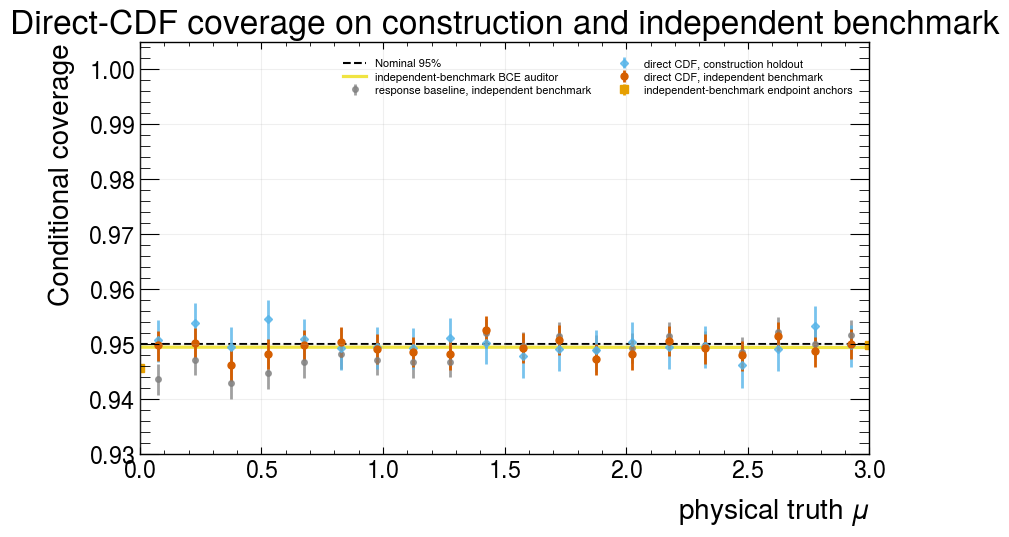

method,global_coverage,minimum_binned_coverage,maximum_binned_coverage
response baseline — independent benchmark,0.94849,0.94293,0.95228
direct CDF — construction holdout,0.95017,0.94622,0.95459
direct CDF — independent benchmark,0.94937,0.94621,0.95257


Raw bootstrap-coverage quantiles (toy noise included): [0.94766875 0.9514525 ]


In [45]:
binned_before = binned_coverage(
    benchmark_mu, benchmark_covered_hnde, edges=coverage_edges
)

binned_after = binned_coverage(
    benchmark_mu, benchmark_covered_calibrated, edges=coverage_edges
)

anchor_benchmark_rows = []
for anchor_index, anchor_mu in enumerate(ANCHOR_MUS):
    key = f"mu_{anchor_mu:g}".replace(".", "p")
    # Historical endpoint cache directory retained unchanged.
    anchor_benchmark = run_cached_toy_ensemble(
        cache_dir=(
            PIT_CACHE_DIR
            / f"anchor_simulator_new64m_audit_"
              f"{key}_{N_EXTERNAL_ENDPOINT_TOYS}"
        ),
        n_toys=N_EXTERNAL_ENDPOINT_TOYS,
        batch_size=TOY_BATCH_SIZE,
        seed=SEED + 2200 + int(100 * anchor_mu),
        mu_range=MU_RANGE,
        fixed_mu=float(anchor_mu),
        signal_probability=SIM_EXTERNAL_SIGNAL_PROBABILITY,
        background_probability=SIM_EXTERNAL_BACKGROUND_PROBABILITY,
        lam_signal=LAM_SIG,
        lam_background=LAM_BKG,
        likelihood_q=COMPRESSED_Q,
        fit_batch=fit_toy_batch_numpy,
        fit_fingerprint=TOY_FIT_FINGERPRINT,
        fit_runtime_fingerprint=TOY_FIT_RUNTIME_FINGERPRINT,
        test_mu_transform=pseudo_truth_response,
        test_mu_fingerprint=RESPONSE_MAP_FINGERPRINT,
    )
    endpoint_critical = float(
        anchor_simulator_quantiles[anchor_index, index_95]
    )
    endpoint_covered = neyman_accepts_95(
        np.full(N_EXTERNAL_ENDPOINT_TOYS, anchor_mu),
        anchor_benchmark["t_mu"],
    )
    successes = int(endpoint_covered.sum())
    lower, upper = wilson_interval(successes, len(endpoint_covered))
    anchor_benchmark_rows.append({
        "mu": anchor_mu,
        "construction_critical_value": endpoint_critical,
        "external_benchmark_coverage": float(endpoint_covered.mean()),
        "external_mc_lower_given_cutoff": float(lower),
        "external_mc_upper_given_cutoff": float(upper),
        "zero_mass": float(np.mean(
            anchor_benchmark["t_mu"] <= 1.0e-12
        )),
    })
anchor_benchmark_table = pd.DataFrame(anchor_benchmark_rows)
print(
    "Endpoint Wilson intervals use external-toy MC only and condition "
    "on the realized 1M construction cutoff."
)
display(anchor_benchmark_table.style.format(precision=5).hide(axis="index"))

fig, ax = plt.subplots(figsize=(8.8, 5.6))
ax.axhline(.95, color="black", ls="--", lw=1.5,
           label="Nominal 95%")
ax.plot(MU_DENSITY_GRID, auditor_grid, color="C3", lw=2.3,
        label="independent-benchmark BCE auditor")
ax.errorbar(
    binned_before["center"], binned_before["coverage"],
    yerr=[
        binned_before["coverage"] - binned_before["lower"],
        binned_before["upper"] - binned_before["coverage"],
    ],
    fmt="o", ms=4, color="0.5", alpha=.75,
    label="response baseline, independent benchmark",
)
ax.errorbar(
    binned_holdout["center"], binned_holdout["coverage"],
    yerr=[
        binned_holdout["coverage"] - binned_holdout["lower"],
        binned_holdout["upper"] - binned_holdout["coverage"],
    ],
    fmt="D", ms=4, color="C1", alpha=.8,
    label="direct CDF, construction holdout",
)
ax.errorbar(
    binned_after["center"], binned_after["coverage"],
    yerr=[
        binned_after["coverage"] - binned_after["lower"],
        binned_after["upper"] - binned_after["coverage"],
    ],
    fmt="o", ms=5, color="C0",
    label="direct CDF, independent benchmark",
)
ax.errorbar(
    anchor_benchmark_table["mu"],
    anchor_benchmark_table["external_benchmark_coverage"],
    yerr=[
        anchor_benchmark_table["external_benchmark_coverage"]
        - anchor_benchmark_table["external_mc_lower_given_cutoff"],
        anchor_benchmark_table["external_mc_upper_given_cutoff"]
        - anchor_benchmark_table["external_benchmark_coverage"],
    ],
    fmt="s", ms=6, color="C2",
    label="independent-benchmark endpoint anchors",
)
ax.set(
    xlim=MU_RANGE,
    xlabel=r"physical truth $\mu$",
    ylabel="Conditional coverage",
    title="Direct-CDF coverage on construction and independent benchmark",
)
ax.set_ylim(min(.93, binned_before["lower"].min() - .005), 1.005)
ax.grid(alpha=.2)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
export_exercise11_figure(fig, "direct_cdf_external_benchmark_coverage")
plt.show()

coverage_summary = pd.DataFrame({
    "method": [
        "response baseline — independent benchmark",
        "direct CDF — construction holdout",
        "direct CDF — independent benchmark",
    ],
    "global_coverage": [
        benchmark_covered_hnde.mean(),
        holdout_covered_calibrated.mean(),
        benchmark_covered_calibrated.mean(),
    ],
    "minimum_binned_coverage": [
        binned_before["coverage"].min(),
        binned_holdout["coverage"].min(),
        binned_after["coverage"].min(),
    ],
    "maximum_binned_coverage": [
        binned_before["coverage"].max(),
        binned_holdout["coverage"].max(),
        binned_after["coverage"].max(),
    ],
})
display(coverage_summary.style.format(precision=5).hide(axis="index"))
print(
    "Raw bootstrap-coverage quantiles (toy noise included):",
    bootstrap_global_interval[[0, 2]],
)


## 15. Invert the pivot for pseudo-observed datasets

Coverage controls test size but does not determine the usefulness of the resulting confidence set. Draw several pseudo-observed datasets from the independent 64M external-template law and invert both:

- the response-matched hNDE reference rule before the residual direct-CDF flow;
- the rule calibrated to the 64M construction law by $G_\psi$.

The scan preserves disconnected confidence-set components rather than replacing them with their convex hull. The table distinguishes the surrogate MLE $\widehat\nu$ from the response-mapped physical estimate $g^{-1}(\widehat\nu)$ and reports whether each set contains its generating truth.

This is a numerical power/length illustration on a previously opened external template. With five pseudo-datasets it cannot diagnose coverage, and differences between this run and earlier pseudo-datasets are not paired precision comparisons.


dataset,truth_mu,surrogate_nu_hat,response_mapped_mu_hat,baseline_contains_truth,direct_cdf_contains_truth,response_baseline_set,direct_cdf_set,response_baseline_length,direct_cdf_length,direct_cdf_minus_baseline
0,0.250,1.313,1.198,False,True,"[0.254, 2.293]","[0.244, 2.291]",2.040,2.046,+0.006
1,0.750,1.942,1.826,False,True,"[0.754, 2.933]","[0.746, 2.924]",2.178,2.178,+0.000
2,1.000,1.179,1.064,True,True,"[0.158, 2.167]","[0.140, 2.162]",2.010,2.022,+0.012
3,1.750,1.325,1.210,True,True,"[0.260, 2.306]","[0.254, 2.303]",2.046,2.049,+0.003
4,2.500,2.718,2.602,True,True,"[1.510, 3.000]","[1.510, 3.000]",1.490,1.490,+0.000


Mean confidence-set length, response baseline / direct CDF: 1.9527 / 1.9569
Wrote standalone figure script: exercise11_figures_scripts/response_pit_confidence_set_inversion.py


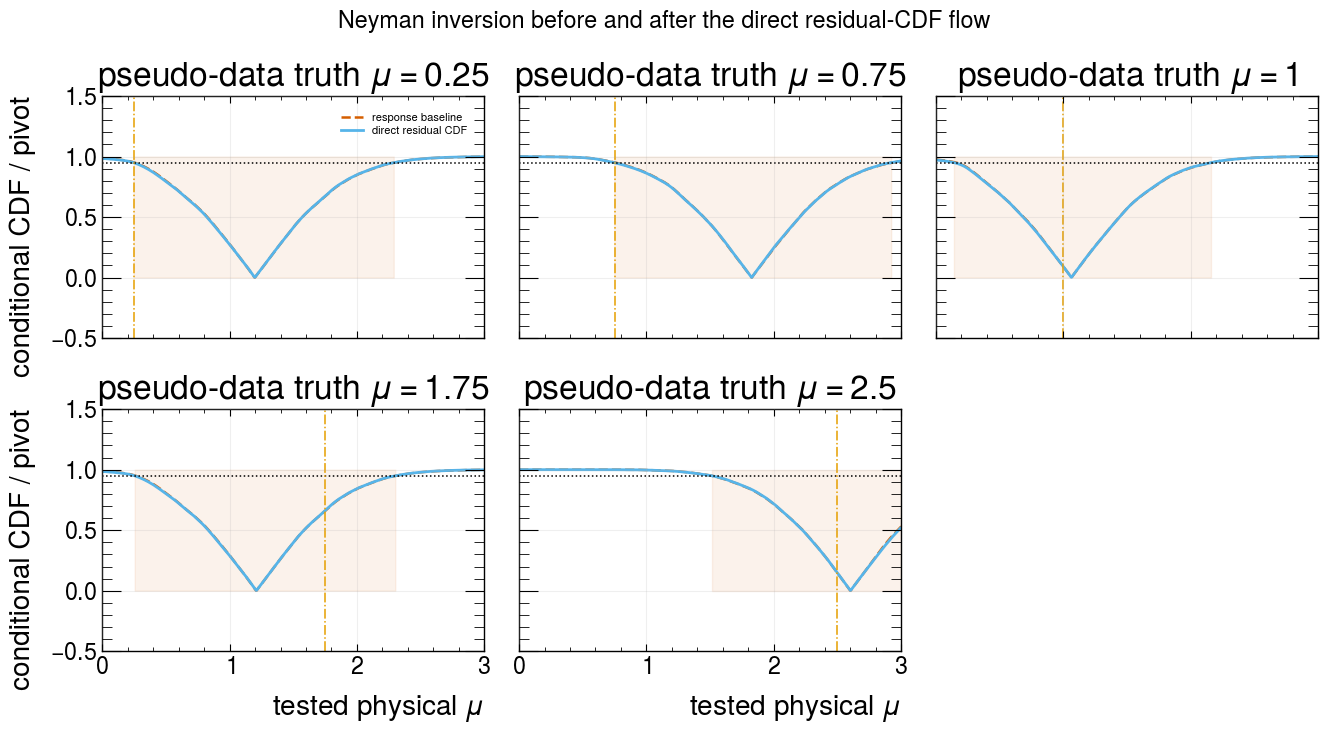

In [46]:
OBSERVED_TRUTH_MUS = np.asarray([0.25, 0.75, 1.0, 1.75, 2.50])
INVERSION_MU_POINTS = 401 if FAST_MODE else 1_001
INVERSION_MU_GRID = np.linspace(*MU_RANGE, INVERSION_MU_POINTS)
observed_rng = np.random.default_rng(SEED + 1600)
observed_mean = (
    OBSERVED_TRUTH_MUS[:, None]
    * LAM_SIG
    * SIM_EXTERNAL_SIGNAL_PROBABILITY[None, :]
    + LAM_BKG * SIM_EXTERNAL_BACKGROUND_PROBABILITY[None, :]
)
observed_counts = observed_rng.poisson(observed_mean)


def response_baseline_accepts_95(mu, t_mu):
    """Endpoint-aware response-matched hNDE rule before PIT calibration."""
    mu, t_mu = np.broadcast_arrays(
        np.asarray(mu, dtype=np.float64),
        np.asarray(t_mu, dtype=np.float64),
    )
    accepted = np.empty(mu.shape, dtype=bool)
    assigned = np.zeros(mu.shape, dtype=bool)
    interior = (mu > MU_RANGE[0]) & (mu < MU_RANGE[1])
    if np.any(interior):
        u0 = evaluate_response_pit(mu[interior], t_mu[interior])
        accepted[interior] = u0 <= .95
        assigned[interior] = True
    for anchor_index, anchor_mu in enumerate(ANCHOR_MUS):
        endpoint = mu == anchor_mu
        accepted[endpoint] = (
            t_mu[endpoint]
            <= anchor_hnde_quantiles[anchor_index, index_95]
        )
        assigned[endpoint] = True
    if not np.all(assigned):
        raise ValueError("mu lies outside the calibrated design range.")
    return accepted


def confidence_set_components(grid, accepted):
    """Return midpoint-interpolated connected components of a grid set."""
    grid = np.asarray(grid, dtype=np.float64)
    accepted = np.asarray(accepted, dtype=bool)
    if grid.ndim != 1 or accepted.shape != grid.shape:
        raise ValueError("grid and accepted must be equal-length vectors.")
    padded = np.pad(accepted.astype(np.int8), (1, 1))
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    stops = np.flatnonzero(changes == -1) - 1
    components = []
    for start, stop in zip(starts, stops):
        left = (
            grid[0]
            if start == 0
            else 0.5 * (grid[start - 1] + grid[start])
        )
        right = (
            grid[-1]
            if stop == len(grid) - 1
            else 0.5 * (grid[stop] + grid[stop + 1])
        )
        components.append((float(left), float(right)))
    return components


def format_components(components):
    if not components:
        return "empty"
    return " ∪ ".join(
        f"[{left:.3f}, {right:.3f}]" for left, right in components
    )


inversion_rows = []
inversion_curves = []
for observed_index, (truth_mu, counts) in enumerate(zip(
    OBSERVED_TRUTH_MUS, observed_counts
)):
    repeated_counts = np.repeat(
        counts[None, :], INVERSION_MU_POINTS, axis=0
    )
    mu_hat_scan, t_scan, _ = response_corrected_test_statistic(
        repeated_counts, INVERSION_MU_GRID
    )
    scan_interior = (
        (INVERSION_MU_GRID > MU_RANGE[0])
        & (INVERSION_MU_GRID < MU_RANGE[1])
    )
    u0_scan = np.empty(INVERSION_MU_POINTS, dtype=np.float64)
    u_cal_scan = np.empty(INVERSION_MU_POINTS, dtype=np.float64)
    u0_scan[scan_interior], u_cal_scan[scan_interior] = (
        evaluate_calibrated_pit(
            INVERSION_MU_GRID[scan_interior],
            t_scan[scan_interior],
        )
    )
    # At the exact boundaries the construction uses empirical anchor
    # laws, so use their empirical CDFs for the displayed pivots too.
    for anchor_mu in ANCHOR_MUS:
        endpoint = INVERSION_MU_GRID == anchor_mu
        endpoint_t = float(t_scan[endpoint][0])
        u0_scan[endpoint] = np.mean(
            anchor_hnde[anchor_mu]["t_mu"] <= endpoint_t
        )
        u_cal_scan[endpoint] = np.mean(
            anchor_simulator[anchor_mu]["t_mu"] <= endpoint_t
        )
    accepted_before = response_baseline_accepts_95(
        INVERSION_MU_GRID, t_scan
    )
    accepted_after = neyman_accepts_95(
        INVERSION_MU_GRID, t_scan
    )
    components_before = confidence_set_components(
        INVERSION_MU_GRID, accepted_before
    )
    components_after = confidence_set_components(
        INVERSION_MU_GRID, accepted_after
    )
    length_before = sum(
        right - left for left, right in components_before
    )
    length_after = sum(
        right - left for left, right in components_after
    )
    inversion_rows.append({
        "dataset": observed_index,
        "truth_mu": float(truth_mu),
        "surrogate_nu_hat": float(np.median(mu_hat_scan)),
        "response_mapped_mu_hat": float(physical_response_estimate(
            np.median(mu_hat_scan)
        )),
        "baseline_contains_truth": bool(any(
            left <= truth_mu <= right for left, right in components_before
        )),
        "direct_cdf_contains_truth": bool(any(
            left <= truth_mu <= right for left, right in components_after
        )),
        "response_baseline_set": format_components(components_before),
        "direct_cdf_set": format_components(components_after),
        "response_baseline_length": float(length_before),
        "direct_cdf_length": float(length_after),
        "direct_cdf_minus_baseline": float(length_after - length_before),
    })
    inversion_curves.append({
        "u0": u0_scan,
        "u_cal": u_cal_scan,
        "before": accepted_before,
        "after": accepted_after,
    })

inversion_table = pd.DataFrame(inversion_rows)
display(inversion_table.style.format({
    "truth_mu": "{:.3f}",
    "surrogate_nu_hat": "{:.3f}",
    "response_mapped_mu_hat": "{:.3f}",
    "response_baseline_length": "{:.3f}",
    "direct_cdf_length": "{:.3f}",
    "direct_cdf_minus_baseline": "{:+.3f}",
}).hide(axis="index"))
print(
    "Mean confidence-set length, response baseline / direct CDF:",
    f"{inversion_table['response_baseline_length'].mean():.4f} / "
    f"{inversion_table['direct_cdf_length'].mean():.4f}",
)

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5), sharex=True, sharey=True)
for ax, truth_mu, curves in zip(
    axes.flat, OBSERVED_TRUTH_MUS, inversion_curves
):
    ax.plot(
        INVERSION_MU_GRID, curves["u0"], ls="--", lw=1.8,
        label="response baseline",
    )
    ax.plot(
        INVERSION_MU_GRID, curves["u_cal"], lw=2.0,
        label="direct residual CDF",
    )
    ax.axhline(.95, color="black", ls=":", lw=1.1)
    ax.axvline(truth_mu, color="C2", ls="-.", lw=1.1)
    ax.fill_between(
        INVERSION_MU_GRID, 0.0, 1.0,
        where=curves["after"], color="C0", alpha=.08,
    )
    ax.set_title(rf"pseudo-data truth $\mu={truth_mu:g}$")
    ax.grid(alpha=.2)
axes.flat[len(OBSERVED_TRUTH_MUS)].axis("off")
for ax in axes[-1, :]:
    ax.set_xlabel(r"tested physical $\mu$")
for ax in axes[:, 0]:
    ax.set_ylabel("conditional CDF / pivot")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Neyman inversion before and after the direct residual-CDF flow")
fig.tight_layout()
export_exercise11_figure(fig, "response_pit_confidence_set_inversion")
plt.show()


## Interpretation: what each layer corrects

The construction now has a short conceptual spine:

$$
\mathcal D
\longmapsto T_\mu^{(g)}
\overset{H}{\longmapsto}U_0
\overset{G_\psi}{\longmapsto}U_{\rm cal}.
$$

- The frozen hNDE likelihood supplies a useful ordering model in its surrogate coordinate $\nu$.
- The 64M construction stream defines the empirical target law while nested prefixes diagnose event-template convergence.
- The pseudo-truth map $g_C(\mu)$ removes the leading response displacement. It is not a physical reparameterization and does not make the hNDE likelihood exact.
- Response-matched hNDE toys, the statistic spline, and the first held-out hNDE ratio define the inexpensive reference CDF $H$.
- The single conditional flow represents the residual construction-law CDF $G_\psi$ directly. Its derivative is the old PIT density ratio, but no second classifier or numerical primitive is needed. Structural validity of that CDF does not replace empirical tail calibration; the present procedure is assessed primarily at its registered 95% level.
- The construction-law holdout isolates learned-CDF error under the declared template.
- The multinomial bootstrap probes sensitivity of the fixed procedure, with its toy-Monte-Carlo contribution shown explicitly.
- The reused independent 64M template measures external regression/transfer, but is no longer a sealed confirmatory audit for this refactored method.
- The fixed-$\mu$ prefix study diagnoses how transfer changes with finite template size.

The interior 95% confidence set is

$$
\mathcal C_{0.95}(\mathcal D_{\rm obs})
=\left\{\mu\in(0,3):
G_\psi\!\left(
H(T_\mu^{(g)}(\mathcal D_{\rm obs})\mid\mu)
\mid\mu\right)\leq0.95\right\},
$$

with empirical rules at $\mu=0$ and $3$. Equivalently,

$$
T_\mu^{(g)}(\mathcal D_{\rm obs})
\leq
H^{-1}\!\left(G_\psi^{-1}(0.95\mid\mu)\mid\mu\right).
$$

Exact knowledge of $F_C$ would permit exact randomized calibration of **any** ordering statistic under $P_C^\mu$, or a nonrandomized discrete-quantile construction with an explicit tie convention and its corresponding conservative behavior. The response map and hNDE reference remain valuable for power, smoothness, and sample efficiency because they leave only a near-identity residual transport. None of these steps guarantees transfer from one finite event template to another.


## What the large-template study does—and does not—establish

The notebook reports four distinct empirical targets:

1. **Generator-version closure.** Exercise 5 parquets and the analytic stream are compared in PRESEL acceptance, feature histograms, $q$ moments, and response.
2. **Convergence of the construction law.** Nested prefixes show $L^1$, $g_N-g_{64\mathrm M}$, and standardized score drift. Prefix fluctuations are correlated because the samples are nested.
3. **Conditional calibration on the fixed construction template.** The holdout control asks whether $G_\psi\circ H$ reproduces that declared empirical law.
4. **Transfer to another finite simulator template.** The independent 64M benchmark and prefix study use different seeds and events, but are now post-selection regression tests rather than newly sealed evidence.

Streaming 64M selected events per process greatly reduces shape-template noise but does not make every ingredient exact. Coverage remains conditional on $\lambda_S$, $\lambda_B$, the learned PRESEL and event-ratio networks, finite-reference normalizations, the hNDE likelihood, and the 512-bin compression. Increasing the event reservoir does not remove those other approximations.

The external law is itself a finite empirical approximation, not infinite simulator truth. Its role here is controlled algorithmic comparison. Because its result was already observed, any new method choice informed by this notebook consumes it for confirmatory purposes.

The raw multinomial-bootstrap coverage spread is also not automatically a finite-template uncertainty band. Its replicate variance must first be compared with pseudo-experiment binomial variance, as done above.

Other legitimate production targets—hierarchical average coverage, uniformly conservative coverage over a template nuisance set, or coverage conditional on explicit MC-statistical/modeling nuisances—define different ensembles and generally different confidence procedures.


## Why the direct PIT-CDF flow extends to high-dimensional parameters

For a physical parameter vector $\boldsymbol\theta$, the response becomes a map $\boldsymbol g(\boldsymbol\theta)$ into surrogate-likelihood coordinates, while the calibrated CDF remains

$$
F_\psi(t\mid\boldsymbol\theta)
=G_\psi\!\left(
  H(t\mid\boldsymbol\theta)
  \mid\boldsymbol\theta
 \right).
$$

Only the scalar PIT argument must be transformed monotonically. The conditioning network may take an arbitrarily dimensional $\boldsymbol\theta$, but the flow still transports one scalar to one scalar and provides analytic normalization and inversion. There is no parameter-dimensional quadrature and no Cartesian CDF table required in principle; requested parameter batches can be evaluated on demand.

The response map need not be globally one-to-one for formal size calibration of a statistic whose conditional CDF is learned correctly, but local identifiability and smoothness are important for stable ordering and power. A collapsing response direction can be calibrated yet carry little discrimination.

This construction does not abolish the simulator curse of dimensionality. A high-dimensional conditional model still needs adequate proposal coverage throughout the parameter region, explicit treatment of nuisance ensembles, interpolation diagnostics, and independent pointwise coverage checks. The scalar map's monotonicity and endpoint normalization are structural rather than imposed by multidimensional numerical quadrature; statistical calibration and coverage remain learned properties that must be checked empirically.


## Further studies

1. On the same cached simulator toys, compare the direct residual-CDF flow with (i) direct 95% conditional quantile regression, the canonical LF2I branch, and (ii) an ALFFI-style simulator-only full CDF. The present method retains all confidence levels and the hNDE preconditioner; the alternatives diagnose whether reference modeling or tail allocation limits accuracy.
2. If a fresh confirmatory transfer statement is needed after this refactor, pre-register a new independent simulator reservoir. The reused 64M benchmark cannot be resealed.
3. Recompute $g(\mu)$ and the complete calibration inside template bootstraps to study a hierarchical average-coverage procedure, keeping that target distinct from sensitivity of the fixed construction.
4. Propagate uncertainty in $\lambda_S$, $\lambda_B$, finite-reference ratio normalization, and learned event-level ratios as explicit nuisance coordinates rather than conditioning on them.
5. Repeat the confidence-set-length comparison over a large pseudo-observed ensemble, using common random numbers where possible, finer root finding, and explicit rates of boundary truncation and disconnected sets.
6. If confidence levels much more extreme than those resolved by the present holdout are required, pre-register a tail-focused validation study. Useful ingredients include dedicated tail proposals, several training seeds, a smaller or regularized identity-tail region, and fixed-level coverage checks; model selection must use construction data rather than the opened external benchmark.
7. If the scalar statistic develops a non-negligible atom, replace the continuous interior flow with an explicit discrete-plus-continuous model or a randomized/conservative PIT rule.
